# Exploratory analysis: corridor activity trajectories, catchments and data validity

*This notebook runs locally on the exported files in `data/activity/east_bay_essential_results` (relative to `analysis/activity/`) and writes nothing to disk. The extraction workflow in `east_bay_corridor_activity_full.ipynb` (Cuebiq/Snowflake) is used only as a reference for definitions and query logic and is neither run nor modified.*

**Purpose.** Understand how the 11 Oakland BID corridors have trajectories in recorded mobile activity: which sustain visitation, recover, grow or weaken; how their visitor catchments differ; and how visitation patterns and origins change over time.

**How the notebook is organised**

| Section | Question |
|---|---|
| 0 | What is in the exports, and do the basic counts reconcile? |
| 1 | What does the measurement context (provider breaks, sample size, HOME coverage) allow us to say? |
| 2 | How do corridors differ in recorded visitation in 2025 (vs 2024)? |
| 3 | Long-term trajectories: 2020 decline and recovery (LIMA), 2024→2025 change (PAPA) |
| 4–5 | Who visits: origin categories, CBG detail and straight-line distance |
| 6 | Timing, seasonality and repeat visitation |
| 7 | Data validity, methodological review and robustness checks, ending in an action table |
| 8 | Synthesis and story angles |

### Measures and definitions used throughout
These are taken from the extraction notebook's contract and the exported `run_config`; the first checks below confirm the parts that can be verified from the files.

- **Four different counts.** *Raw stops* (`raw_stop_count`) are corridor × geohash stop assignments. A *visit* is one device × corridor × **local date**. *Monthly unique devices* count devices active in a corridor-month. *Half-year unique devices* count devices over six months. These are different measures and are never mixed.
- **Raw activity covers all visitors.** **Adjusted** activity covers only devices with a matched Bay Area HOME (nine California counties, confidence ≥ 0.60, one snapshot on the 10th of the month), multiplied by a within-provider-segment sample weight. It is **not** a population estimate and not an adjusted count of all visitors.
- **HOME geography** is a US Census block group (TIGER2019), not a home geohash. Categories are Oakland, San Francisco, Rest East Bay (Alameda and Contra Costa counties outside Oakland) and Rest Bay Area. **"No matched Bay Area HOME" does not mean the device lives outside the Bay Area**: it may lack a confident HOME, or have a HOME elsewhere.
- **Device-months are not people.** Monthly uniques summed over months are device-months. Device identifiers reset at each half-year boundary, so people are never linked across halves.
- **Time periods overlap.** `all`, `weekdays`, `weekends`, `nine-five` (weekdays 09:00–16:59) and `evening` (every day 17:00–22:59) cannot be summed, except that weekday + weekend visits equal all visits by construction.
- **Corridors overlap.** A device or visit can fall in several corridors (shared geohash cells), so summing across corridors is not a deduplicated citywide total. "Citywide" below means "sum of the 11 corridors".
- **Providers differ.** Each half-year uses one provider (LIMA 2019–2022, SIERRA Jan–Jun 2023, PAPA Jul 2023–Dec 2025). Weights use a reference *within* each continuous provider segment, so levels are **not calibrated across providers**.
- **Activity is not commerce.** Mobile visits are evidence about the use and persistence of places. They are not revenue, shopping, business survival or economic resilience.

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')    # before the plotting imports, which emit environment warnings
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from tqdm import tqdm

In [2]:
# ---- paths ----------------------------------------------------------------
DATA_DIR = Path('../../data/activity/east_bay_essential_results')
LOAD_TABLES = ['corridor_stops', 'corridor_repeat_visitors', 'corridor_origin_categories_monthly',
               'corridor_home_distance_monthly', 'corridor_homes', 'home_geography', 'corridor_geography',
               'provider_schedule', 'bay_month_denoms', 'home_month_qa', 'run_config']
OPTIONAL_TABLES = ['corridor_homes_monthly']          # large; loaded selectively in section 7
EXTRACTION_TABLES_NOT_EXPORTED = ['provider_coverage_screen', 'home_sample_index', 'provider_activity_daily',
                                  'provider_home_sample', 'extraction_coverage', 'corridors_geohash9_diagnostics']

# ---- provider schedule expected from the extraction contract --------------------
EXPECTED_SCHEDULE = {'LIMA': (201901, 202212), 'SIERRA': (202301, 202306), 'PAPA': (202307, 202512)}
PROVIDER_ORDER = ['LIMA', 'SIERRA', 'PAPA']
EXPECTED_MONTHS, EXPECTED_CORRIDORS = 84, 11

# ---- time periods ---------------------------------------------------------------
TIME_PERIODS = ['all', 'weekdays', 'weekends', 'nine-five', 'evening']
PERIOD_LABEL = {'all': 'All visits', 'weekdays': 'Weekdays (Mon–Fri)', 'weekends': 'Weekends (Sat–Sun)',
                'nine-five': 'Weekdays 09:00–16:59', 'evening': 'Every day 17:00–22:59'}
PERIOD_HOURS = {'all': 24, 'weekdays': 24, 'weekends': 24, 'nine-five': 8, 'evening': 6}

# ---- origin categories, geography and distance bands ---------------------------------
ORIGIN_ORDER = ['Oakland', 'San Francisco', 'Rest East Bay', 'Rest Bay Area']
UNMATCHED = 'No matched Bay Area HOME'
UNKNOWN_DISTANCE = 'Unknown distance'
BAY_COUNTIES = {'001': 'Alameda', '013': 'Contra Costa', '041': 'Marin', '055': 'Napa', '075': 'San Francisco',
                '081': 'San Mateo', '085': 'Santa Clara', '095': 'Solano', '097': 'Sonoma'}
EAST_BAY_COUNTIES = ['001', '013']
DIST_BANDS = ['00: 0–2 km', '01: 2–5 km', '02: 5–10 km', '03: 10–25 km', '04: 25–50 km', '05: 50–100 km', '06: 100+ km']
WITHIN_5, WITHIN_10, BEYOND_25 = DIST_BANDS[:2], DIST_BANDS[:3], DIST_BANDS[4:]
DIST_CENTROID_NOTE = 'straight-line km from CBG internal point to corridor centroid'

# ---- comparison windows --------------------------------------------------------
BASE_YEAR, FOCUS_YEAR, COMPARISON_YEAR = 2019, 2025, 2024
LIMA_YEARS = [2019, 2020, 2021, 2022]
PAPA_YEARS = [2024, 2025]
SAME_WINDOWS = {'Full year (Jan–Dec)': list(range(1, 13)), 'Jan–Nov (December excluded)': list(range(1, 12))}
HALF_COMPARE = {'H1': ('2024H1', '2025H1'), 'H2': ('2024H2', '2025H2')}
RECOVERY_THRESHOLD = 0.90        # share of the same calendar month in 2019
SPIKE_RATIO = 1.40               # month vs median of its four nearest in-segment months
MIN_TREND_DEVICES = 100          # monthly matched devices below which a corridor-month is "thin"
EXTREME_WEIGHT_HIGH, EXTREME_WEIGHT_LOW = 5.0, 0.2    # thresholds used by the extraction
WEIGHT_CLIP = (0.2, 5.0)         # sensitivity cap on the flagged extreme weights, used only in section 7
GROWTH_PCT, STABLE_PCT = 8.0, 4.0   # descriptive cut-offs for the plain-language labels (adjusted change)
PEAK_MONTHS = 'Apr-Nov 2025'

# ---- colours: validated categorical palette order, neutral for context -----------------
INK, INK_2, GRID = '#1f1f1e', '#52514e', '#e4e3df'
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, C_MAGENTA, C_VIOLET, C_RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#4a3aa7', '#e34948')
C_GRAY = '#9a9992'
ORIGIN_COLORS = {'Oakland': C_BLUE, 'San Francisco': C_ORANGE, 'Rest East Bay': C_AQUA, 'Rest Bay Area': C_YELLOW,
                 UNMATCHED: '#c9c8c2'}
PROVIDER_TINT = {'LIMA': '#eef3fb', 'SIERRA': '#e6e6e1', 'PAPA': '#fdf1ea'}
PROVIDER_EDGE = {'LIMA': C_BLUE, 'SIERRA': C_GRAY, 'PAPA': C_ORANGE}
MEASURES = {'raw': ('All visitors, raw', INK_2), 'matched': ('Matched-HOME visits, unweighted', C_AQUA),
            'adjusted': ('Matched-HOME visits, adjusted', C_BLUE)}
DIVERGING = LinearSegmentedColormap.from_list('div', [C_RED, '#f0efec', C_BLUE])

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': INK_2, 'axes.labelcolor': INK_2, 'axes.titlesize': 10, 'axes.titleweight': 'bold',
                     'axes.titlecolor': INK, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
                     'xtick.color': INK_2, 'ytick.color': INK_2, 'font.size': 9, 'legend.frameon': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.axisbelow': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

## 0. Inventory, loading and basic validity checks
Each partitioned export (monthly or half-yearly `.csv.gz`) is concatenated from a *sorted* file list and then sorted by its own keys, so nothing depends on filesystem order. Every table is read once and cached in memory. `corridor_homes_monthly` is present but large (84 partitions, ~120 MB compressed); it is not loaded here and is read selectively in section 7 only for the weight diagnostics.

In [3]:
FILES = {name: sorted((DATA_DIR / name).glob('*.csv.gz')) for name in LOAD_TABLES}
parts = {name: [] for name in LOAD_TABLES}
for name, path in tqdm([(n, f) for n, fs in FILES.items() for f in fs], desc='partitions', mininterval=2):
    parts[name].append(pd.read_csv(path))
T = {name: pd.concat(frames, ignore_index=True) for name, frames in parts.items()}   # sorted file lists; order never relied on
run_config_json = json.load(open(DATA_DIR / 'run_config.json'))

inv = []
for folder in sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()):
    files = sorted((DATA_DIR / folder).glob('*.csv.gz'))
    size_mb = sum(f.stat().st_size for f in files) / 1e6
    df = T.get(folder)
    coverage = ''
    if df is not None and 'year_month' in df:
        coverage = f'{df.year_month.min()}–{df.year_month.max()} ({df.year_month.nunique()} months)'
    elif df is not None and 'half_year' in df:
        coverage = f'{df.half_year.min()}–{df.half_year.max()} ({df.half_year.nunique()} halves)'
    inv.append({'table': folder, 'partitions': len(files), 'format': '.csv.gz', 'MB (gz)': round(size_mb, 1),
                'rows loaded': len(df) if df is not None else 'not loaded', 'columns': df.shape[1] if df is not None else '',
                'coverage': coverage, 'grain / partition key': 'month' if len(files) == 84 else 'half-year' if len(files) == 14 else 'single file'})
display(pd.DataFrame(inv))
print('Not exported in this folder (listed in the extraction notebook):', ', '.join(EXTRACTION_TABLES_NOT_EXPORTED))
print('Corridors:', ', '.join(sorted(T['corridor_geography'].corridor_name)))
print('Run:', {k: run_config_json[k] for k in ['run_label', 'version', 'start', 'end', 'providers', 'country', 'snapshot_days', 'dwell', 'confidence', 'baseline_min', 'baseline', 'provider_identity', 'geography', 'distance']})

partitions:   0%|          | 0/286 [00:00<?, ?it/s]

partitions:  97%|█████████▋| 276/286 [00:02<00:00, 132.30it/s]

partitions: 100%|██████████| 286/286 [00:03<00:00, 93.43it/s] 

,table,partitions,format,MB (gz),rows loaded,columns,coverage,grain / partition key
0,bay_month_denoms,1,.csv.gz,0.00,84,14,201901–202512 (84 months),single file
1,corridor_geography,1,.csv.gz,0.00,11,4,,single file
2,corridor_home_distance_monthly,84,.csv.gz,1.20,35028,15,201901–202512 (84 months),month
3,corridor_homes,14,.csv.gz,34.70,1416575,17,2019H1–2025H2 (14 halves),half-year
4,corridor_homes_monthly,84,.csv.gz,127.80,not loaded,,,month
5,corridor_origin_categories_monthly,84,.csv.gz,0.80,23029,16,201901–202512 (84 months),month
6,corridor_repeat_visitors,14,.csv.gz,0.00,770,14,2019H1–2025H2 (14 halves),half-year
7,corridor_stops,84,.csv.gz,0.30,4620,22,201901–202512 (84 months),month
8,home_geography,1,.csv.gz,0.10,4751,7,,single file
9,home_month_qa,1,.csv.gz,0.00,84,4,201901–202512 (84 months),single file


Not exported in this folder (listed in the extraction notebook): provider_coverage_screen, home_sample_index, provider_activity_daily, provider_home_sample, extraction_coverage, corridors_geohash9_diagnostics
Corridors: Chinatown, Downtown, Fruitvale, Jack London, Koreatown/Northgate, Lake Merritt, Lakeshore, Laurel, Montclair, Rockridge, Temescal/Telegraph
Run: {'run_label': 'bay_monthly_v3', 'version': 'east_bay_full_v2_monthly_bay_single', 'start': 20190101, 'end': 20251231, 'providers': ['PAPA', 'LIMA', 'SIERRA'], 'country': 'US', 'snapshot_days': [10], 'dwell': 480, 'confidence': 0.6, 'baseline_min': 30, 'baseline': 'segment_first_up_to_12_months', 'provider_identity': 'single_per_half_year', 'geography': 'TIGER2019', 'distance': True}


In [4]:
# Missing values (columns with any) per loaded table
miss = []
for name, df in T.items():
    if name == 'run_config':
        continue
    for col, n in df.isna().sum().items():
        if n:
            miss.append({'table': name, 'column': col, 'missing rows': int(n), 'share of rows': n / len(df)})
display(pd.DataFrame(miss))
oc_ = T['corridor_origin_categories_monthly']
print('Rows with missing normalized_* in origin categories that are the unmatched category:',
      int(oc_[oc_.normalized_visit_count.isna()].home_geography.eq(UNMATCHED).sum()), 'of', int(oc_.normalized_visit_count.isna().sum()))

,table,column,missing rows,share of rows
0,corridor_origin_categories_monthly,normalized_raw_stop_count,4619,0.20
1,corridor_origin_categories_monthly,normalized_visit_count,4619,0.20
2,corridor_origin_categories_monthly,normalized_unique_devices,4619,0.20
3,corridor_home_distance_monthly,normalized_raw_stop_count,4619,0.13
4,corridor_home_distance_monthly,normalized_visit_count,4619,0.13
5,corridor_home_distance_monthly,normalized_unique_devices,4619,0.13
6,corridor_homes,normalized_raw_stop_count,770,0.00
7,corridor_homes,normalized_visit_count,770,0.00
8,corridor_homes,normalized_unique_device_months,770,0.00


Rows with missing normalized_* in origin categories that are the unmatched category: 4619 of 4619


**Missing values are structural.** The only gaps are `normalized_*` fields on rows for the unmatched category or unknown distance, which have no sample weight by construction (devices without a matched Bay HOME cannot be weighted). Nothing else is missing.

In [5]:
# ---- prepare working frames -------------------------------------------------
sched = T['provider_schedule'].sort_values('year_month').reset_index(drop=True)
stops = T['corridor_stops'].sort_values(['corridor_id', 'year_month', 'time_period']).reset_index(drop=True)
origin = T['corridor_origin_categories_monthly']
dist = T['corridor_home_distance_monthly']
repeat = T['corridor_repeat_visitors']
homes_half = T['corridor_homes']
denoms = T['bay_month_denoms'].sort_values('year_month').reset_index(drop=True)
home_qa = T['home_month_qa'].sort_values('year_month').reset_index(drop=True)
geo_cor, geo_home = T['corridor_geography'], T['home_geography']

for df in (stops, origin, dist, denoms, home_qa, sched):
    df['year'] = df.year_month // 100
    df['month'] = df.year_month % 100
    df['date'] = pd.to_datetime(df.year_month.astype(str) + '01', format='%Y%m%d')
for df in (stops, origin, dist):
    df.drop(columns=['panel_comparability'], inplace=True, errors='ignore')

SEGMENTS = (sched.groupby(['provider_segment', 'provider_id'], sort=False)
            .agg(first=('date', 'min'), last=('date', 'max'), months=('year_month', 'size'),
                 reference_months=('reference_months', 'first')).reset_index())
SEGMENTS['end'] = SEGMENTS['last'] + pd.offsets.MonthEnd(0) + pd.Timedelta(days=1)
SEG_OF = dict(zip(sched.year_month, sched.provider_segment))
PROV_OF = dict(zip(sched.year_month, sched.provider_id))

act = stops[stops.time_period == 'all'].copy()
act['unmatched_visits'] = act.visit_count - act.home_matched_visits
act['effective_weight'] = act.adjusted_known_home_visits / act.home_matched_visits
CORRIDORS = sorted(act.corridor_name.unique(), key=lambda c: -act.loc[(act.corridor_name == c) & (act.year == FOCUS_YEAR), 'visit_count'].sum())
print('Corridors ordered by 2025 raw visits:', CORRIDORS)

Corridors ordered by 2025 raw visits: ['Fruitvale', 'Lake Merritt', 'Downtown', 'Temescal/Telegraph', 'Chinatown', 'Jack London', 'Koreatown/Northgate', 'Rockridge', 'Laurel', 'Lakeshore', 'Montclair']


In [6]:
checks = []
def check(name, ok, detail):
    checks.append({'check': name, 'result': 'PASS' if ok else 'FAIL', 'detail': detail})

grid = stops.groupby(['corridor_id', 'year_month', 'time_period']).size()
check('Stops grain unique and complete (corridor × month × period)', grid.max() == 1 and len(grid) == EXPECTED_CORRIDORS * EXPECTED_MONTHS * 5,
      f'{len(grid):,} rows = {EXPECTED_CORRIDORS} corridors × {EXPECTED_MONTHS} months × 5 periods; max rows per key {grid.max()}')
zero_by_period = stops.groupby('time_period').apply(lambda d: int((d.visit_count == 0).sum()))
check('No corridor-month with zero recorded visits in any period', zero_by_period.sum() == 0,
      f'zero-visit rows by period: {zero_by_period.to_dict()}; minimum monthly devices ("all") = {int(act.unique_devices.min())}')
check('Row-level count relationships (devices ≤ visits ≤ stops; matched ≤ devices)',
      int(((stops.unique_devices > stops.visit_count) | (stops.visit_count > stops.raw_stop_count) | (stops.home_matched_devices > stops.unique_devices)).sum()) == 0,
      'violations: 0')
wide = stops.pivot_table(index=['corridor_id', 'year_month'], columns='time_period', values='visit_count')
check('Weekday + weekend visits equal all visits; 09–17 ⊆ weekdays; evening ⊆ all',
      bool(((wide.weekdays + wide.weekends) == wide['all']).all() and (wide['nine-five'] <= wide.weekdays).all() and (wide.evening <= wide['all']).all()),
      'exact equality holds for every corridor-month (visits are device-days, so periods split cleanly; device counts do not)')

def reconcile(df, label, keys=('corridor_id', 'year_month', 'time_period')):
    s = df.groupby(list(keys))[['raw_stop_count', 'visit_count', 'unique_devices']].sum()
    m = stops.set_index(list(keys))[['raw_stop_count', 'visit_count', 'unique_devices']].join(s, rsuffix='_x', how='outer')
    diff = sum(int((m[c] != m[c + '_x']).sum()) for c in ['raw_stop_count', 'visit_count', 'unique_devices'])
    check(f'{label} reconciles to corridor_stops (stops, visits, devices)', diff == 0, f'{len(m):,} keys compared, {diff} differences')
reconcile(origin, 'Origin categories (incl. unmatched)')
reconcile(dist, 'Distance bands (incl. unknown)')

matched_o = origin[origin.home_geography != UNMATCHED].groupby(['corridor_id', 'year_month', 'time_period']).visit_count.sum()
adj_o = origin[origin.home_geography != UNMATCHED].groupby(['corridor_id', 'year_month', 'time_period']).normalized_visit_count.sum()
adj_d = dist[dist.distance_band != UNKNOWN_DISTANCE].groupby(['corridor_id', 'year_month', 'time_period']).normalized_visit_count.sum()
ix = stops.set_index(['corridor_id', 'year_month', 'time_period'])
check('Matched visits = visits outside the unmatched category; unmatched = unknown distance',
      bool((ix.home_matched_visits == matched_o.reindex(ix.index).fillna(0)).all() and
           (ix.visit_count - ix.home_matched_visits == dist[dist.distance_band == UNKNOWN_DISTANCE].groupby(['corridor_id', 'year_month', 'time_period']).visit_count.sum().reindex(ix.index).fillna(0)).all()),
      'unknown distance is exactly the unmatched-HOME visits')
check('Adjusted visits agree across stops, origin and distance tables',
      float((ix.adjusted_known_home_visits - adj_o.reindex(ix.index)).abs().max()) < 1e-6 and float((ix.adjusted_known_home_visits - adj_d.reindex(ix.index)).abs().max()) < 1e-6,
      'max absolute difference < 1e-6 visits')
qa_chk = act.groupby('year_month').agg(dev=('unique_devices', 'sum'), hm=('home_matched_devices', 'sum')).join(home_qa.set_index('year_month'))
check('home_month_qa reproduces summed corridor devices and match rates',
      bool((qa_chk.dev == qa_chk.summed_corridor_period_devices).all() and ((qa_chk.hm / qa_chk.dev - qa_chk.weighted_home_match_rate).abs() < 1e-5).all()),
      'summed corridor-period devices and weighted match rate recomputed from corridor_stops')
check('Origin / distance grains unique',
      origin.groupby(['corridor_id', 'year_month', 'time_period', 'home_geography']).size().max() == 1 and
      dist.groupby(['corridor_id', 'year_month', 'time_period', 'distance_band']).size().max() == 1, 'max rows per key = 1')
check('Repeat table grain unique and complete (corridor × half-year × period)',
      repeat.groupby(['corridor_id', 'half_year', 'time_period']).size().max() == 1 and len(repeat) == 11 * 14 * 5 and
      int((repeat.repeat_devices > repeat.unique_devices).sum()) == 0 and int((repeat.devices_active_multiple_months > repeat.unique_devices).sum()) == 0,
      f'{len(repeat)} rows = 11 × 14 × 5; repeat and multi-month device counts never exceed unique devices')
hh = homes_half.groupby(['corridor_id', 'half_year', 'time_period', 'block_group_id']).size()
check('corridor_homes grain unique', hh.max() == 1, f'{len(hh):,} corridor × half-year × period × CBG rows')
cbg_ids = set(homes_half.block_group_id) - {'UNKNOWN'}
check('Every matched CBG has coordinates and one category in home_geography',
      cbg_ids <= set(geo_home.block_group_id) and geo_home.block_group_id.is_unique and bool((geo_home.coordinate_status == 'matched').all()),
      f'{len(cbg_ids):,} CBGs appear in corridor_homes; {len(geo_home):,} in home_geography; all with TIGER2019 internal points')
check('Provider schedule: one provider per half-year, 84 months', sched.groupby('half_year').provider_id.nunique().max() == 1 and len(sched) == 84,
      'see section 1 for the schedule itself')
display(pd.DataFrame(checks))

,check,result,detail
0,Stops grain unique and complete (corridor × month × period),PASS,"4,620 rows = 11 corridors × 84 months × 5 periods; max rows per key 1"
1,No corridor-month with zero recorded visits in any period,PASS,"zero-visit rows by period: {'all': 0, 'evening': 0, 'nine-five': 0, 'weekdays': 0, 'weekends': 0}; minimum monthly devices (""all"") = 32"
2,Row-level count relationships (devices ≤ visits ≤ stops; matched ≤ devices),PASS,violations: 0
3,Weekday + weekend visits equal all visits; 09–17 ⊆ weekdays; evening ⊆ all,PASS,"exact equality holds for every corridor-month (visits are device-days, so periods split cleanly; device counts do not)"
4,"Origin categories (incl. unmatched) reconciles to corridor_stops (stops, visits, devices)",PASS,"4,620 keys compared, 0 differences"
5,"Distance bands (incl. unknown) reconciles to corridor_stops (stops, visits, devices)",PASS,"4,620 keys compared, 0 differences"
6,Matched visits = visits outside the unmatched category; unmatched = unknown distance,PASS,unknown distance is exactly the unmatched-HOME visits
7,"Adjusted visits agree across stops, origin and distance tables",PASS,max absolute difference < 1e-6 visits
8,home_month_qa reproduces summed corridor devices and match rates,PASS,summed corridor-period devices and weighted match rate recomputed from corridor_stops
9,Origin / distance grains unique,PASS,max rows per key = 1


**Basic checks (section 0 summary).** The grid is complete: 11 corridors × 84 months × 5 periods with no duplicate grain, and no corridor-month has zero recorded visits. Origin and distance summaries reconcile *exactly* to `corridor_stops` once the unmatched and unknown categories are included; unknown distance is identical to unmatched HOME. Category and distance rows for a corridor-month that has no devices in that category are simply absent. They are legitimate zeros (totals still reconcile exactly), so they are filled with zero below rather than treated as missing. Because the extraction's own checks only prove that *some* corridor recorded activity on each of the 2,557 requested dates, **section 7** looks for evidence of incomplete coverage at corridor/provider level.

## 1. Measurement context and provider breaks
Before reading any trend we need to know what changed in the *measurement*. The exported schedule gives the selected provider for each month. Weights are the ratio of a segment's reference-period Bay HOME sample to the current month's sample (CBG by CBG where samples are ≥ 30, otherwise a Bay-wide ratio), computed **within** each continuous provider segment. They never calibrate one provider to another. All long-term charts below therefore draw each provider segment separately and shade the breaks.

In [7]:
def shade_segments(ax, labels=False, xlim=None):
    """Tint each provider segment and mark the breaks; segments are never joined by a line."""
    for _, s in SEGMENTS.iterrows():
        ax.axvspan(s['first'], s['end'], color=PROVIDER_TINT[s.provider_id], lw=0, zorder=0)
        if s['first'] > SEGMENTS['first'].min():
            ax.axvline(s['first'], color=INK_2, lw=0.8, ls=(0, (3, 2)), zorder=1)
        if labels:
            mid = s['first'] + (s['end'] - s['first']) / 2
            narrow = s.provider_id == 'SIERRA'
            ax.text(mid, 0.04 if narrow else 0.05, s.provider_id, transform=ax.get_xaxis_transform(), ha='center', va='bottom',
                    fontsize=8, color=INK_2 if narrow else PROVIDER_EDGE[s.provider_id], fontweight='bold', rotation=90 if narrow else 0)
    ax.set_xlim(xlim or (pd.Timestamp('2019-01-01'), pd.Timestamp('2026-01-01')))

def segment_lines(ax, df, y, x='date', **kw):
    """Plot y against date one provider segment at a time (no line across a provider break)."""
    label = kw.pop('label', None)
    for i, (seg, g) in enumerate(df.groupby('provider_segment', sort=False)):
        ax.plot(g[x], g[y], label=label if i == 0 else None, **kw)

def ma3(df, col):
    """Trailing 3-month mean within corridor and provider segment (never across a break); needs 3 observations."""
    return df.sort_values('year_month').groupby(['corridor_name', 'provider_segment'])[col].transform(lambda s: s.rolling(3, min_periods=3).mean())

display(sched.groupby('half_year', sort=True).agg(months=('year_month', 'size'), provider=('provider_id', 'first'), segment=('provider_segment', 'first'),
        reference_start=('reference_start_month', 'first'), reference_months=('reference_months', 'first'), selection_basis=('selection_basis', 'first')))
seg_tbl = SEGMENTS[['provider_segment', 'provider_id', 'first', 'last', 'months', 'reference_months']].copy()
seg_tbl['first'], seg_tbl['last'] = seg_tbl['first'].dt.strftime('%Y-%m'), seg_tbl['last'].dt.strftime('%Y-%m')
seg_tbl['matches expected'] = [(int(a.replace('-', '')), int(b.replace('-', ''))) == EXPECTED_SCHEDULE[p]
                               for a, b, p in zip(seg_tbl['first'], seg_tbl['last'], seg_tbl.provider_id)]
display(seg_tbl.rename(columns={'first': 'first month', 'last': 'last month'}))

,months,provider,segment,reference_start,reference_months,selection_basis
half_year,,,,,,
2019H1,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2019H2,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2020H1,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2020H2,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2021H1,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2021H2,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2022H1,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2022H2,6,LIMA,S1_LIMA,201901,12,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates
2023H1,6,SIERRA,S2_SIERRA,202301,6,largest_sum_of_monthly_sample_day_devices_among_full_half_year_candidates


,provider_segment,provider_id,first month,last month,months,reference_months,matches expected
0,S1_LIMA,LIMA,2019-01,2022-12,48,12,True
1,S2_SIERRA,SIERRA,2023-01,2023-06,6,6,True
2,S3_PAPA,PAPA,2023-07,2025-12,30,12,True


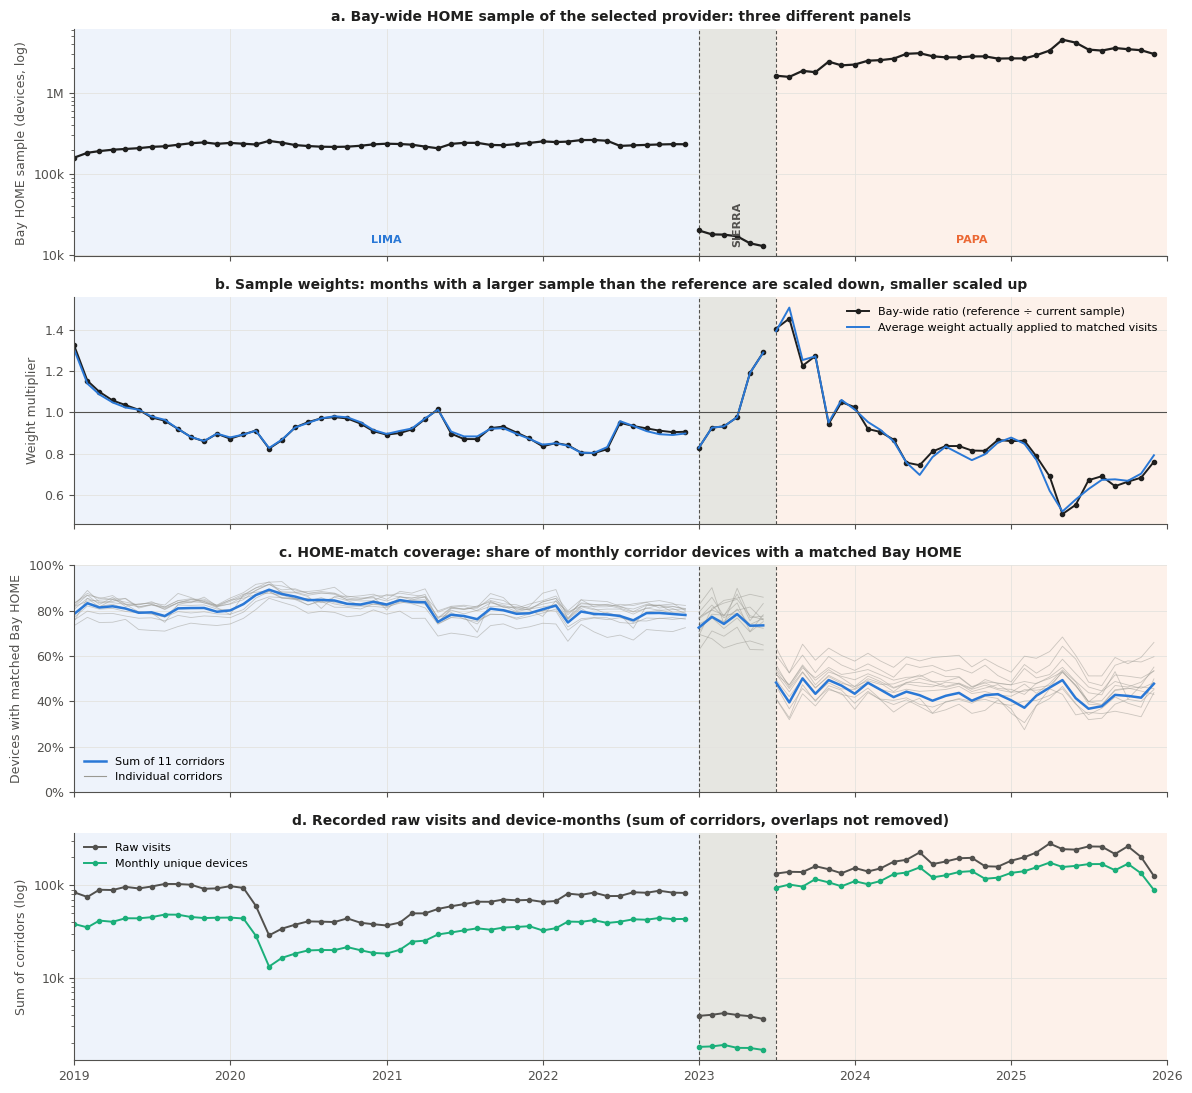

In [8]:
city = act.groupby(['year_month', 'date', 'year', 'provider_id', 'provider_segment']).agg(
    visits=('visit_count', 'sum'), devices=('unique_devices', 'sum'), matched_devices=('home_matched_devices', 'sum'),
    matched_visits=('home_matched_visits', 'sum'), adjusted=('adjusted_known_home_visits', 'sum')).reset_index()
city = city.merge(denoms[['year_month', 'bay_home_sample', 'bay_sample_ratio', 'baseline_bay_home_sample', 'is_reference_month']], on='year_month')
city['match_rate'] = city.matched_devices / city.devices
city['effective_weight'] = city.adjusted / city.matched_visits
city['visits_per_device'] = city.visits / city.devices

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
for i, ax in enumerate(axes):
    shade_segments(ax, labels=(i == 0))
ax = axes[0]
segment_lines(ax, city, 'bay_home_sample', color=INK, lw=1.6, marker='o', ms=3)
ax.set_yscale('log'); ax.set_ylabel('Bay HOME sample (devices, log)')
ax.set_title('a. Bay-wide HOME sample of the selected provider: three different panels')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M' if v >= 1e6 else f'{v/1e3:.0f}k'))
ax = axes[1]
segment_lines(ax, city, 'bay_sample_ratio', color=INK, lw=1.4, marker='o', ms=3, label='Bay-wide ratio (reference ÷ current sample)')
segment_lines(ax, city, 'effective_weight', color=C_BLUE, lw=1.4, label='Average weight actually applied to matched visits')
ax.axhline(1, color=INK_2, lw=0.8); ax.set_ylabel('Weight multiplier'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('b. Sample weights: months with a larger sample than the reference are scaled down, smaller scaled up')
ax = axes[2]
for c in CORRIDORS:
    g = act[act.corridor_name == c]
    segment_lines(ax, g, 'home_match_rate', color=C_GRAY, lw=0.6, alpha=0.5)
segment_lines(ax, city, 'match_rate', color=C_BLUE, lw=1.8, label='Sum of 11 corridors')
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1)); ax.set_ylabel('Devices with matched Bay HOME')
ax.plot([], [], color=C_GRAY, lw=0.8, label='Individual corridors'); ax.legend(loc='lower left', fontsize=8)
ax.set_title('c. HOME-match coverage: share of monthly corridor devices with a matched Bay HOME')
ax = axes[3]
segment_lines(ax, city, 'visits', color=INK_2, lw=1.4, marker='o', ms=3, label='Raw visits')
segment_lines(ax, city, 'devices', color=C_AQUA, lw=1.4, marker='o', ms=3, label='Monthly unique devices')
ax.set_yscale('log'); ax.set_ylabel('Sum of corridors (log)'); ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if v >= 1e3 else f'{v:.0f}'))
ax.set_title('d. Recorded raw visits and device-months (sum of corridors, overlaps not removed)')
plt.tight_layout(); plt.show()

In [9]:
sample_context = city.groupby('provider_id').agg(
    months=('year_month', 'size'), median_bay_home_sample=('bay_home_sample', 'median'),
    median_monthly_devices_all_corridors=('devices', 'median'), median_match_rate=('match_rate', 'median'),
    min_match_rate=('match_rate', 'min'), max_match_rate=('match_rate', 'max')).reindex(PROVIDER_ORDER)
display(sample_context)

sierra = act[act.provider_id == 'SIERRA']
sierra_tbl = sierra.groupby('corridor_name').agg(min_devices=('unique_devices', 'min'), median_devices=('unique_devices', 'median'),
             median_matched_devices=('home_matched_devices', 'median'), min_matched_devices=('home_matched_devices', 'min'),
             median_visits=('visit_count', 'median'), median_match_rate=('home_match_rate', 'median')).reindex(CORRIDORS)
ref_tbl = pd.DataFrame({'LIMA 2022': act[act.year == 2022].groupby('corridor_name').unique_devices.median(),
                        'SIERRA Jan–Jun 2023': sierra.groupby('corridor_name').unique_devices.median(),
                        'PAPA 2024': act[act.year == 2024].groupby('corridor_name').unique_devices.median()}).reindex(CORRIDORS)
sierra_tbl['SIERRA devices as % of LIMA 2022'] = 100 * ref_tbl['SIERRA Jan–Jun 2023'] / ref_tbl['LIMA 2022']
sierra_tbl['thin months (matched < %d)' % MIN_TREND_DEVICES] = sierra.assign(thin=sierra.home_matched_devices < MIN_TREND_DEVICES).groupby('corridor_name').thin.sum().reindex(CORRIDORS)
display(sierra_tbl.round(1))
print('Corridor-months with fewer than', MIN_TREND_DEVICES, 'matched devices, by provider:',
      act.assign(thin=act.home_matched_devices < MIN_TREND_DEVICES).groupby('provider_id').thin.sum().reindex(PROVIDER_ORDER).to_dict())

,months,median_bay_home_sample,median_monthly_devices_all_corridors,median_match_rate,min_match_rate,max_match_rate
provider_id,,,,,,
LIMA,48,"231,486.50","35,914.50",0.81,0.75,0.89
SIERRA,6,"17,527.50","1,782.50",0.74,0.73,0.78
PAPA,30,"2,777,092.00","133,484.00",0.43,0.37,0.50


,min_devices,median_devices,median_matched_devices,min_matched_devices,median_visits,median_match_rate,SIERRA devices as % of LIMA 2022,thin months (matched < 100)
corridor_name,,,,,,,,
Fruitvale,142,156.00,130.50,121,420.00,0.90,4.30,0
Lake Merritt,252,275.50,217.50,182,650.00,0.70,4.90,0
Downtown,228,249.50,169.00,143,621.50,0.70,4.60,0
Temescal/Telegraph,216,247.00,193.50,164,529.00,0.80,4.20,0
Chinatown,155,175.50,130.00,113,381.50,0.70,3.40,0
Jack London,204,226.50,152.50,136,462.50,0.70,4.40,0
Koreatown/Northgate,137,143.00,110.50,97,341.50,0.80,4.70,1
Rockridge,111,117.00,91.50,82,232.50,0.80,3.80,6
Laurel,52,68.50,59.00,40,124.00,0.80,4.20,6


Corridor-months with fewer than 100 matched devices, by provider: {'LIMA': 0, 'SIERRA': 25, 'PAPA': 0}


In [10]:
def pct_change(a, b): return 100 * (b / a - 1)
cs = city.groupby(['provider_id', 'year']).agg(
    months=('year_month', 'size'), bay_home_sample=('bay_home_sample', 'mean'), raw_visits=('visits', 'mean'), devices=('devices', 'mean'),
    matched_visits=('matched_visits', 'mean'), adjusted_visits=('adjusted', 'mean'), matched_dev=('matched_devices', 'sum'), dev_sum=('devices', 'sum'),
    vis_sum=('visits', 'sum')).reset_index()
cs['match_rate'] = cs.matched_dev / cs.dev_sum
cs['visits_per_device'] = cs.vis_sum / cs.dev_sum
cs = cs.drop(columns=['matched_dev', 'dev_sum', 'vis_sum']).set_index(['provider_id', 'year'])
display(cs.rename(columns={'bay_home_sample': 'mean Bay HOME sample', 'raw_visits': 'mean monthly raw visits', 'devices': 'mean monthly devices',
                           'matched_visits': 'mean monthly matched visits', 'adjusted_visits': 'mean monthly adjusted visits'}))

def delta_row(label, a, b):
    return {'comparison': label, 'Bay HOME sample': pct_change(cs.loc[a].bay_home_sample, cs.loc[b].bay_home_sample),
            'raw visits': pct_change(cs.loc[a].raw_visits, cs.loc[b].raw_visits),
            'monthly devices': pct_change(cs.loc[a].devices, cs.loc[b].devices),
            'matched visits (unweighted)': pct_change(cs.loc[a].matched_visits, cs.loc[b].matched_visits),
            'adjusted matched visits': pct_change(cs.loc[a].adjusted_visits, cs.loc[b].adjusted_visits),
            'match rate (pp)': 100 * (cs.loc[b].match_rate - cs.loc[a].match_rate),
            'visits per device': pct_change(cs.loc[a].visits_per_device, cs.loc[b].visits_per_device)}
deltas = pd.DataFrame([delta_row('PAPA 2024 → 2025', ('PAPA', 2024), ('PAPA', 2025)),
                       delta_row('LIMA 2019 → 2022', ('LIMA', 2019), ('LIMA', 2022))]).set_index('comparison')
print('Citywide = sum of the 11 corridors. All columns are % change except the match rate (percentage points).')
display(deltas.round(1).rename_axis(None))

months  mean Bay HOME sample  mean monthly raw visits  mean monthly devices  mean monthly matched visits  mean monthly adjusted visits  match_rate  visits_per_device
provider_id year                                                                                                                                                                       
LIMA        2019      12            211,000.17                93,118.58             43,380.33                    80,257.75                     80,475.08        0.80               2.15
            2020      12            230,422.08                49,658.83             23,798.17                    43,651.25                     39,988.97        0.84               2.09
            2021      12            231,508.17                58,024.17             29,679.08                    49,178.17                     44,957.40        0.80               1.96
            2022      12            242,419.67                79,409.00             40,569.58                    66,949.75                     58,363.87        0.78               1.96
PAPA        2023       6          1,914,168.17               143,195.33            102,623.50                    74,463.33                     91,647.77        0.46               1.40
            2024      12          2,717,228.00               175,722.50            126,862.33                    85,671.00                     70,884.39        0.43               1.39
            2025      12          3,366,045.83               226,737.00            150,993.00                   111,061.83                     75,367.91        0.42               1.50
SIERRA      2023       6             16,717.83                 3,925.67              1,786.00                     3,216.33                      3,276.27        0.75               2.20

Citywide = sum of the 11 corridors. All columns are % change except the match rate (percentage points).


,Bay HOME sample,raw visits,monthly devices,matched visits (unweighted),adjusted matched visits,match rate (pp),visits per device
PAPA 2024 → 2025,23.90,29.00,19.00,29.60,6.30,-1.00,8.40
LIMA 2019 → 2022,14.90,-14.70,-6.50,-16.60,-27.50,-1.90,-8.80


**Takeaways: measurement context**
- **The provider schedule is as expected**: LIMA Jan 2019–Dec 2022 (48 months), SIERRA Jan–Jun 2023 (6), PAPA Jul 2023–Dec 2025 (30), each starting on a half-year boundary, with 12, 6 and 12 reference months. The three panels are different in kind: the Bay HOME sample is ~0.23 M devices (LIMA, median), ~18 k (SIERRA) and ~2.8 M (PAPA, rising from 1.6 M to 4.5 M).
- **Coverage changes are as large as the panels.** HOME-match coverage is ~81% of corridor device-months in LIMA (75–89%), ~74% in SIERRA and only ~43% in PAPA (37–50%). The monthly sum of corridor devices goes 43 k (Dec 2022) → 1.8 k (Jan 2023) → 94 k (Jul 2023). These jumps are **panel changes, not activity changes**, so the provider switch is never read as recovery or decline, and 2025 adjusted levels are not set against 2019.
- **The early-2023 SIERRA panel is unsuitable for trend claims.** It averages ~1.8 k devices a month across all 11 corridors (3–5% of the LIMA 2022 level per corridor). The four smallest corridors have fewer than 100 matched devices in nearly every month (25 corridor-months below 100; Montclair as low as 22). It is kept and shaded in every chart, but not interpreted.
- **How much of apparent change could be the panel?** Within PAPA, the Bay HOME sample grew 24% from 2024 to 2025 and raw corridor visits grew 29% (matched visits, unweighted, 30%), but sample-adjusted matched visits grew only **6%**. Within LIMA, the Bay sample grew 15% from 2019 to 2022 while raw visits fell 15% and adjusted visits fell 28%. So **the weights are decisive**: the raw and adjusted lenses differ by 13 percentage points in LIMA and 23 in PAPA, and the truth sits between them depending on whether corridor visitors scale with the Bay-wide HOME sample (an assumption these tables cannot test). The panel also gets more thoroughly observed over time (visits per device in PAPA moves from 1.39 in 2024 to 1.50 in 2025), another reason not to read raw volume as demand.

## 2. How visitation differs across corridors
This is a snapshot of the PAPA period (2024 and 2025 are both fully inside it, so the within-provider change is meaningful). **Raw visits** are the main all-visitor volume measure; **adjusted matched-HOME visits** are a complementary measure for the roughly 40% of devices with a matched Bay HOME. *Visits per observed device* is total visits ÷ total monthly device counts, i.e. visits per device-month. Corridors differ in size, boundaries and land use, so these are comparisons of recorded activity, not of commercial performance, and no per-area or per-business measure is derived (no denominators are available in the exports).

In [11]:
def corridor_year_table(year):
    g = act[act.year == year].groupby('corridor_name')
    n = act[act.year == year].year_month.nunique()
    out = pd.DataFrame({
        'raw_visits': g.visit_count.sum() / n, 'devices': g.unique_devices.sum() / n,
        'visits_per_device': g.visit_count.sum() / g.unique_devices.sum(),
        'matched_visits': g.home_matched_visits.sum() / n, 'adjusted_visits': g.adjusted_known_home_visits.sum() / n,
        'match_rate': g.home_matched_devices.sum() / g.unique_devices.sum()})
    return out.reindex(CORRIDORS)

ov25, ov24 = corridor_year_table(2025), corridor_year_table(2024)
ov = ov25.copy()
for col, lab in [('raw_visits', 'Δ raw visits %'), ('devices', 'Δ devices %'), ('matched_visits', 'Δ matched visits (unweighted) %'), ('adjusted_visits', 'Δ adjusted %')]:
    ov[lab] = pct_change(ov24[col], ov25[col])
ov['visits_per_device 2024'] = ov24.visits_per_device
ov['raw_visits 2024'] = ov24.raw_visits
ov['adjusted_visits 2024'] = ov24.adjusted_visits
ov['raw rank'] = ov.raw_visits.rank(ascending=False).astype(int)
ov['adjusted rank'] = ov.adjusted_visits.rank(ascending=False).astype(int)
show = ov[['raw_visits', 'devices', 'visits_per_device', 'matched_visits', 'adjusted_visits', 'match_rate', 'raw rank', 'adjusted rank',
           'Δ raw visits %', 'Δ devices %', 'Δ matched visits (unweighted) %', 'Δ adjusted %']].rename(columns={
    'raw_visits': '2025 raw visits / month', 'devices': '2025 devices / month', 'visits_per_device': '2025 visits per device',
    'matched_visits': '2025 matched visits / month', 'adjusted_visits': '2025 adjusted visits / month', 'match_rate': '2025 HOME-match coverage'})
display(show.round({'2025 raw visits / month': 0, '2025 devices / month': 0, '2025 matched visits / month': 0, '2025 adjusted visits / month': 0,
                    '2025 visits per device': 2, '2025 HOME-match coverage': 2, 'Δ raw visits %': 1, 'Δ devices %': 1,
                    'Δ matched visits (unweighted) %': 1, 'Δ adjusted %': 1}))
print('Rank agreement between raw and adjusted 2025 volume (Spearman):', round(spearmanr(ov.raw_visits, ov.adjusted_visits)[0], 2))
print('Sum of the 11 corridors, 2025: raw visits/month =', f'{ov25.raw_visits.sum():,.0f}', '(overlapping corridors are double-counted by design)')

,2025 raw visits / month,2025 devices / month,2025 visits per device,2025 matched visits / month,2025 adjusted visits / month,2025 HOME-match coverage,raw rank,adjusted rank,Δ raw visits %,Δ devices %,Δ matched visits (unweighted) %,Δ adjusted %
corridor_name,,,,,,,,,,,,
Fruitvale,"51,986.00","35,122.00",1.48,"23,304.00","13,236.00",0.37,1,2,27.80,19.50,29.70,4.10
Lake Merritt,"45,328.00","28,820.00",1.57,"21,033.00","13,281.00",0.38,2,1,45.40,31.30,46.70,11.60
Downtown,"29,712.00","19,806.00",1.50,"13,768.00","10,200.00",0.40,3,3,14.40,7.00,14.70,-1.10
Temescal/Telegraph,"24,444.00","15,403.00",1.59,"13,274.00","8,504.00",0.47,4,5,39.90,20.20,45.00,6.80
Chinatown,"23,668.00","15,438.00",1.53,"12,667.00","9,491.00",0.46,5,4,34.90,27.30,31.00,12.90
Jack London,"18,967.00","12,948.00",1.46,"9,456.00","7,338.00",0.45,6,6,14.50,7.30,14.80,2.80
Koreatown/Northgate,"14,156.00","9,623.00",1.47,"7,048.00","5,378.00",0.45,7,7,36.00,25.60,31.20,15.40
Rockridge,"6,188.00","4,664.00",1.33,"3,688.00","2,784.00",0.55,8,8,16.10,12.30,18.60,2.90
Laurel,"4,890.00","3,578.00",1.37,"2,690.00","2,099.00",0.51,9,9,13.00,8.40,13.80,2.60


Rank agreement between raw and adjusted 2025 volume (Spearman): 0.98
Sum of the 11 corridors, 2025: raw visits/month = 226,737 (overlapping corridors are double-counted by design)


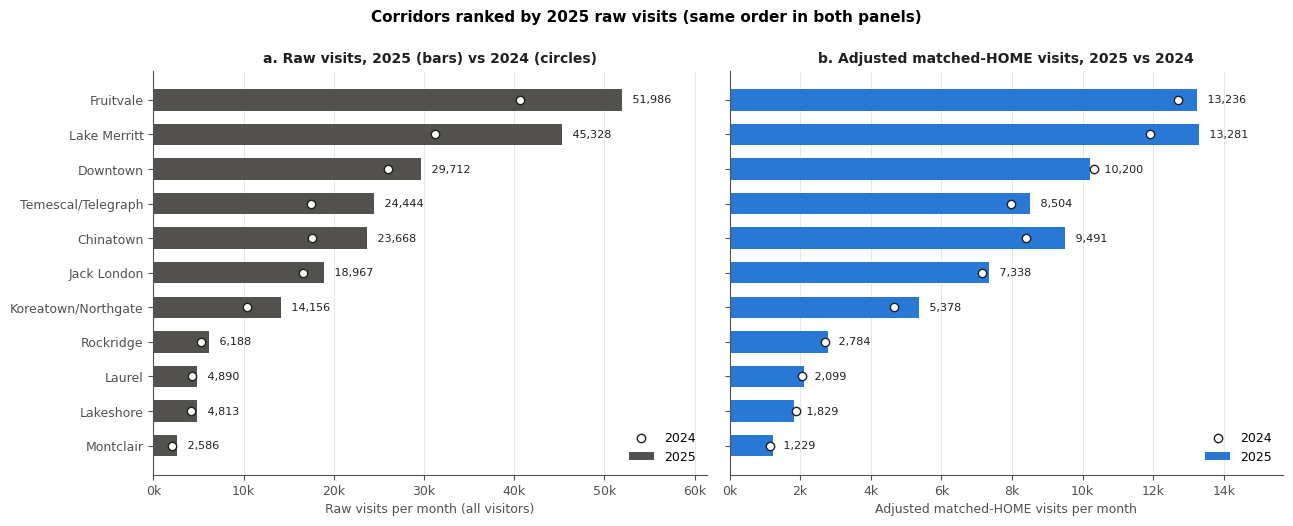

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
order = CORRIDORS
y = np.arange(len(order))[::-1]
for ax, col, lab, color in [(axes[0], 'raw_visits', 'Raw visits per month (all visitors)', INK_2), (axes[1], 'adjusted_visits', 'Adjusted matched-HOME visits per month', C_BLUE)]:
    ax.barh(y, ov25.loc[order, col], color=color, height=0.62, label='2025')
    ax.scatter(ov24.loc[order, col], y, s=36, facecolor='white', edgecolor=INK, zorder=3, label='2024')
    for yi, v, v24 in zip(y, ov25.loc[order, col], ov24.loc[order, col]):
        ax.text(max(v, v24), yi, f'   {v:,.0f}', va='center', fontsize=8, color=INK)
    ax.set_xlabel(lab); ax.grid(axis='y', visible=False); ax.set_xlim(0, ov25[col].max() * 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
    ax.legend(loc='lower right')
axes[0].set_yticks(y); axes[0].set_yticklabels(order)
axes[0].set_title('a. Raw visits, 2025 (bars) vs 2024 (circles)'); axes[1].set_title('b. Adjusted matched-HOME visits, 2025 vs 2024')
fig.suptitle('Corridors ranked by 2025 raw visits (same order in both panels)', y=1.0, fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

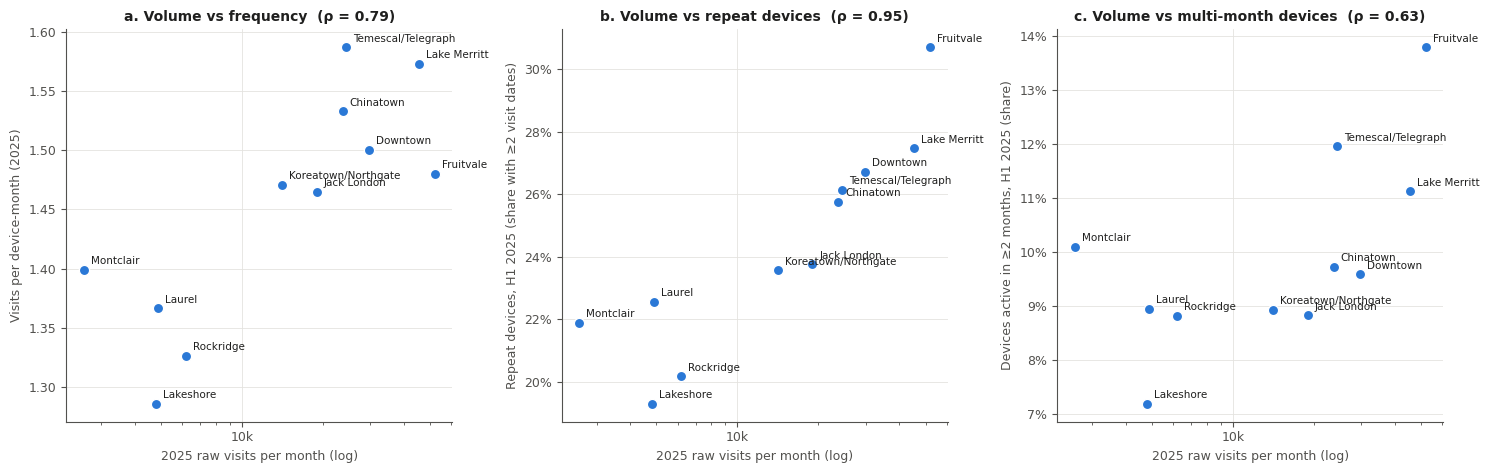

,raw visits / month,visits per device-month,repeat devices H1 2025,repeat devices H1 2024,multi-month devices H1 2025,visits per half-year device H1 2025
corridor_name,,,,,,
Fruitvale,"51,986.00",1.48,0.31,0.25,0.14,1.77
Lake Merritt,"45,328.00",1.57,0.28,0.25,0.11,1.75
Downtown,"29,712.00",1.50,0.27,0.25,0.10,1.67
Temescal/Telegraph,"24,444.00",1.59,0.26,0.22,0.12,1.77
Chinatown,"23,668.00",1.53,0.26,0.24,0.10,1.73
Jack London,"18,967.00",1.46,0.24,0.22,0.09,1.62
Koreatown/Northgate,"14,156.00",1.47,0.24,0.22,0.09,1.59
Laurel,"4,890.00",1.37,0.23,0.21,0.09,1.53
Montclair,"2,586.00",1.40,0.22,0.20,0.10,1.56


In [13]:
r = repeat[repeat.time_period == 'all'].set_index(['corridor_name', 'half_year'])
r = r.assign(multi_month_share=r.devices_active_multiple_months / r.unique_devices, visits_per_half_year_device=r.visit_count / r.unique_devices)
rep25h1 = r.xs('2025H1', level='half_year').reindex(CORRIDORS)
rep24h1 = r.xs('2024H1', level='half_year').reindex(CORRIDORS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
panels = [('visits_per_device', 'Visits per device-month (2025)', ov25.visits_per_device, None),
          ('repeat', 'Repeat devices, H1 2025 (share with ≥2 visit dates)', rep25h1.repeat_device_prop, 1),
          ('multi', 'Devices active in ≥2 months, H1 2025 (share)', rep25h1.multi_month_share, 1)]
offsets = {}
for ax, (k, ylab, yv, pc) in zip(axes, panels):
    x = ov25.raw_visits
    ax.scatter(x, yv, s=55, color=C_BLUE, edgecolor='white', lw=1, zorder=3)
    for c in CORRIDORS:
        ax.annotate(c, (x[c], yv[c]), xytext=(5, 4), textcoords='offset points', fontsize=7.5, color=INK)
    ax.set_xscale('log'); ax.set_xlabel('2025 raw visits per month (log)'); ax.set_ylabel(ylab)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if v >= 1e3 else f'{v:.0f}'))
    if pc: ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
    rho = spearmanr(x, yv)[0]
    ax.set_title(f'Spearman ρ = {rho:.2f} (n = 11)')
axes[0].set_title('a. Volume vs frequency  (ρ = %.2f)' % spearmanr(ov25.raw_visits, ov25.visits_per_device)[0])
axes[1].set_title('b. Volume vs repeat devices  (ρ = %.2f)' % spearmanr(ov25.raw_visits, rep25h1.repeat_device_prop)[0])
axes[2].set_title('c. Volume vs multi-month devices  (ρ = %.2f)' % spearmanr(ov25.raw_visits, rep25h1.multi_month_share)[0])
plt.tight_layout(); plt.show()
rt = pd.DataFrame({'raw visits / month': ov25.raw_visits.round(0), 'visits per device-month': ov25.visits_per_device.round(2),
                   'repeat devices H1 2025': rep25h1.repeat_device_prop.round(3), 'repeat devices H1 2024': rep24h1.repeat_device_prop.round(3),
                   'multi-month devices H1 2025': rep25h1.multi_month_share.round(3),
                   'visits per half-year device H1 2025': rep25h1.visits_per_half_year_device.round(2)})
display(rt.sort_values('repeat devices H1 2025', ascending=False))

**Takeaways: how corridors differ in 2025**
- **Volume is concentrated.** On raw visits (all visitors) Fruitvale (52 k a month), Lake Merritt (45 k) and Downtown (30 k) lead, followed by Temescal/Telegraph (24 k), Chinatown (24 k), Jack London (19 k) and Koreatown/Northgate (14 k); Rockridge, Laurel, Lakeshore and Montclair are an order of magnitude smaller (2.6–6.2 k). The adjusted matched-HOME measure gives the **same order except two swaps** (Lake Merritt first, Fruitvale second; Chinatown above Temescal; Spearman ρ = 0.98) because the highest-volume corridors have the lowest HOME-match coverage (Fruitvale 0.37, Lake Merritt 0.38, against 0.55–0.59 in Rockridge and Montclair).
- **Everything grew in raw terms between 2024 and 2025 (+13% to +45%) but far less after adjustment (−3% to +15%)**, with the exact mix examined in section 3.
- **High volume goes with sustained repeat use.** Repeat-device shares (≥2 visit dates in H1 2025) run from 19% (Lakeshore) to 31% (Fruitvale), and track volume closely (ρ = 0.95); visits per device-month track it less tightly (ρ = 0.79) and the share of devices active in two or more months least (ρ = 0.63). Fruitvale, Lake Merritt, Downtown, Temescal/Telegraph and Chinatown have the highest repeat shares (26–31%) and the highest multi-month shares (10–14%). Montclair is the small corridor with an above-expected multi-month share (10.1%).
- Absolute volume reflects corridor size and boundary as much as vitality; these rankings are not performance rankings.

## 3. Long-term trajectories, decline and recovery
Each corridor's monthly series is drawn **one provider segment at a time** (no line crosses a break, and the unreliable SIERRA months are kept but shaded grey). Thin lines with dots are the monthly observations; the thick line is a trailing 3-month mean computed *within* a segment. Raw visits (all visitors) and adjusted matched-HOME visits are shown in separate figures with independent y-axes because they describe different populations and scales.

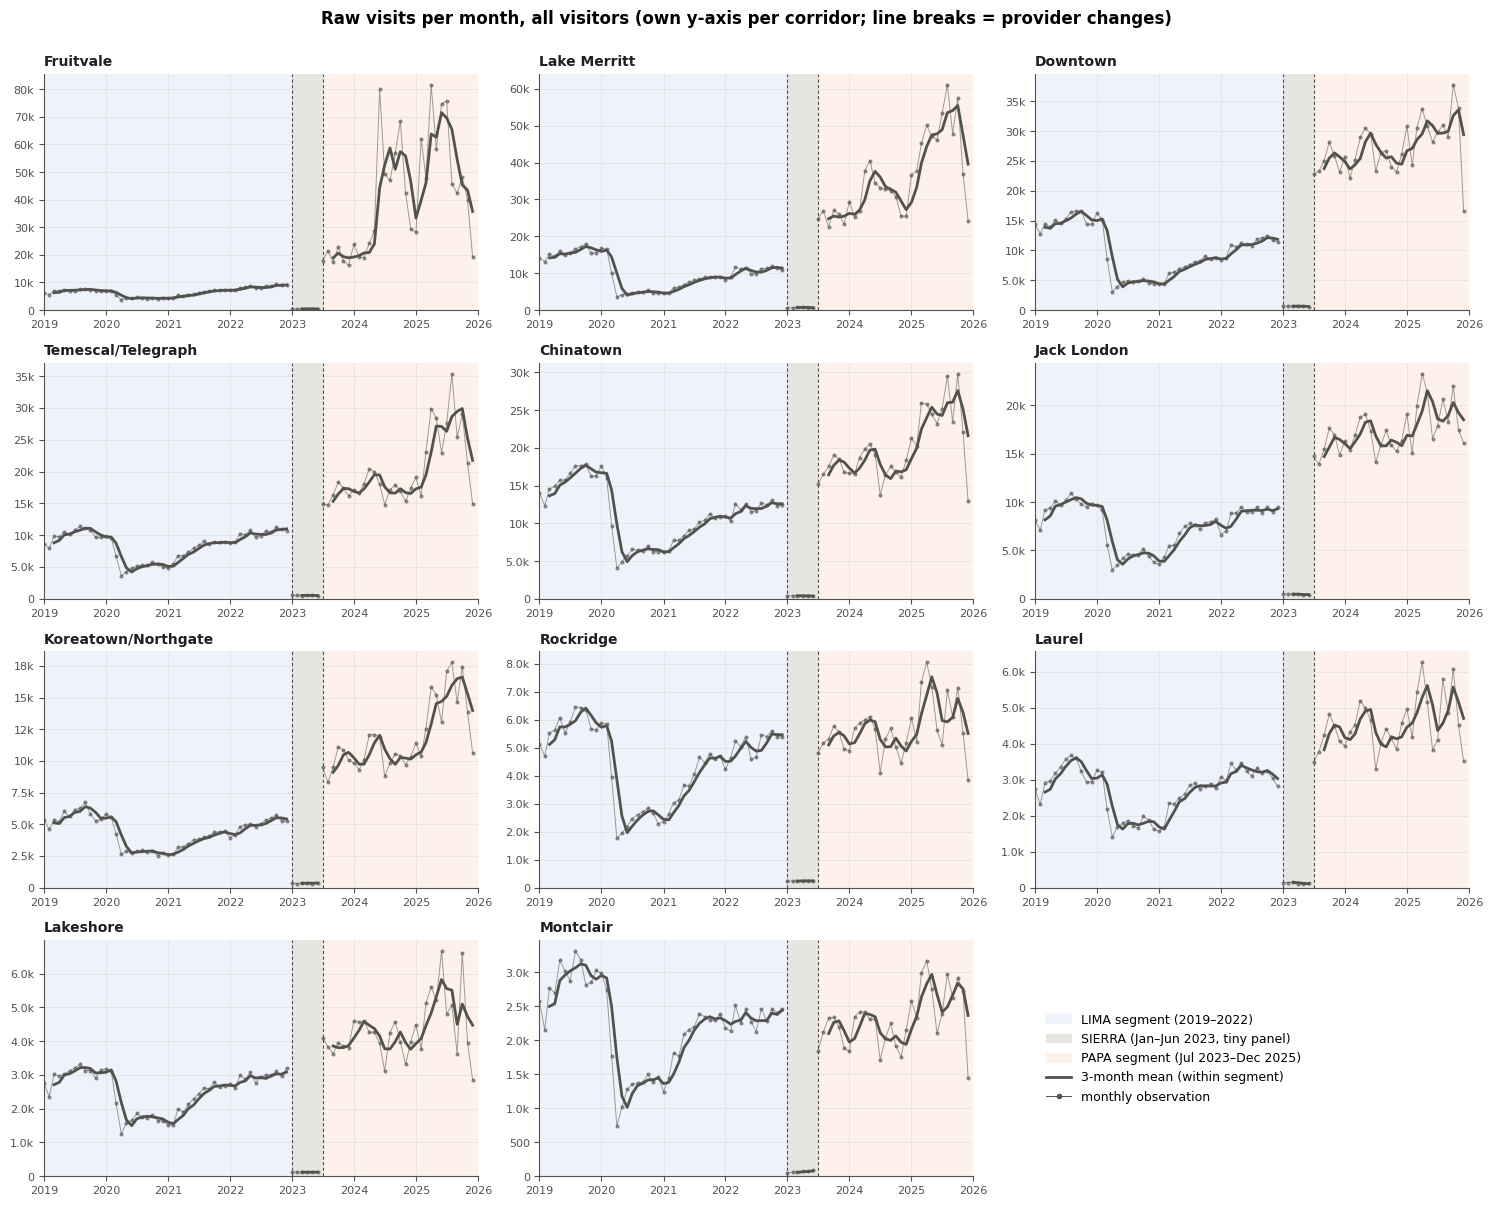

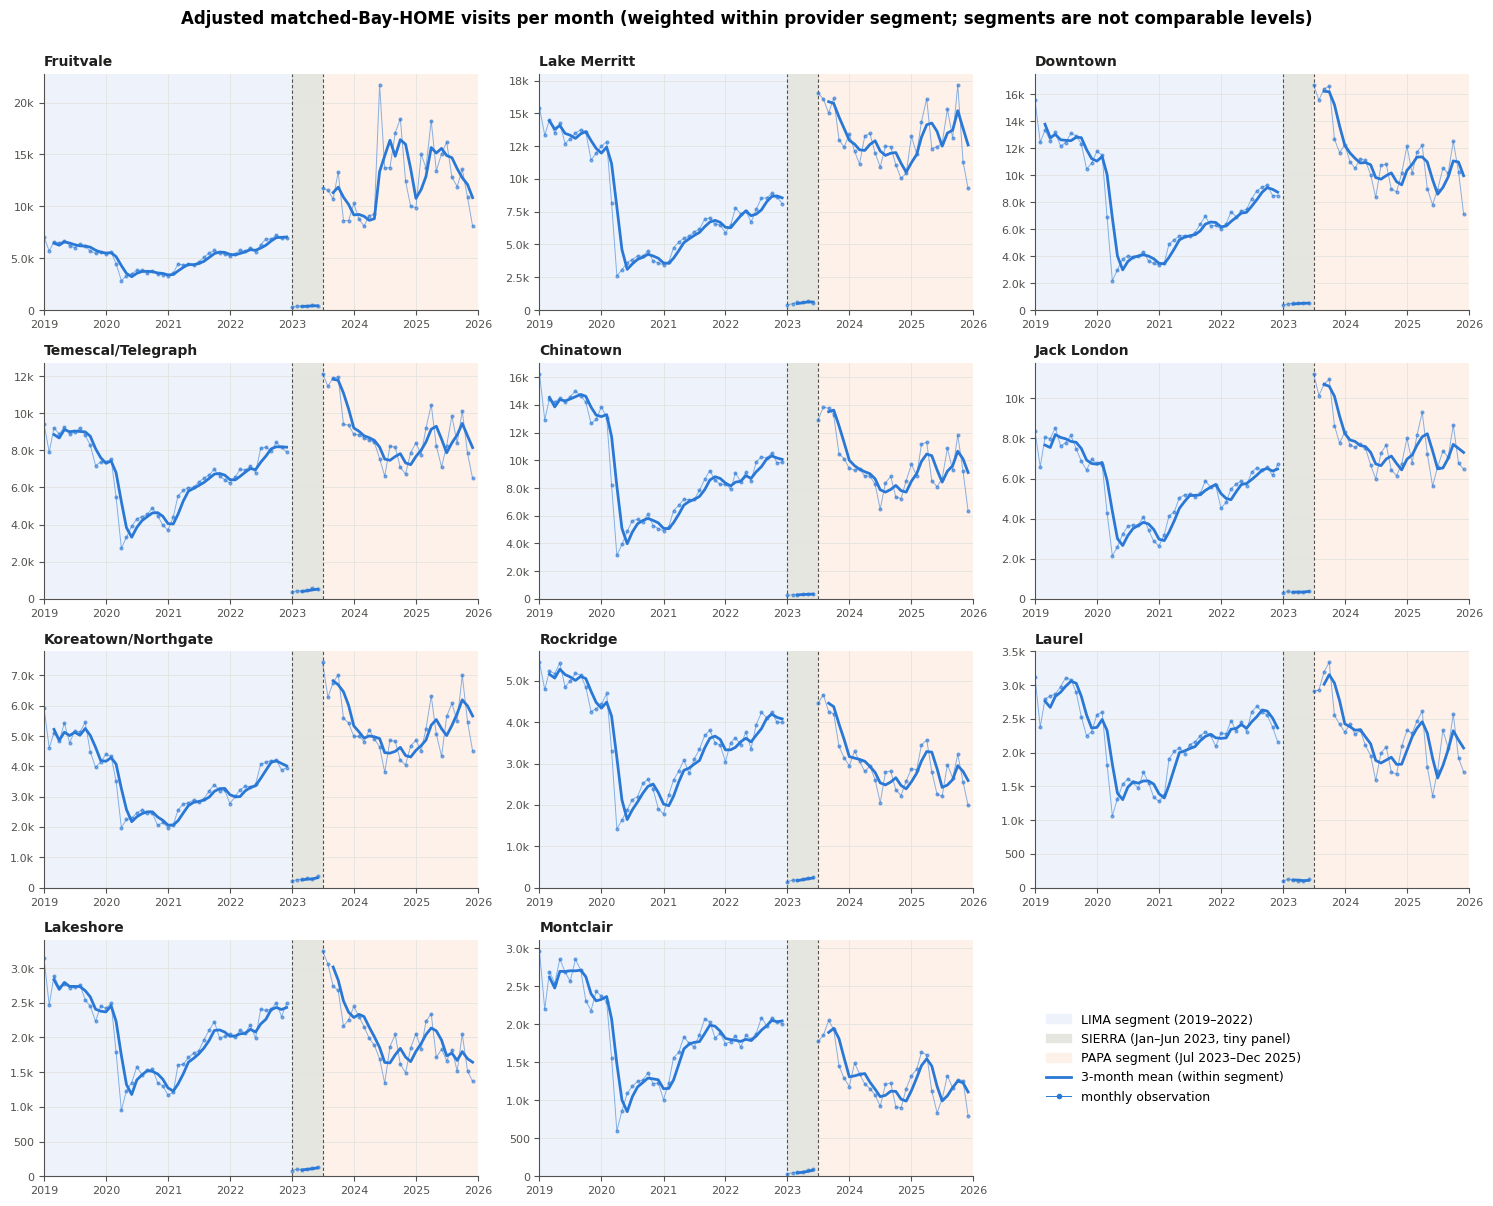

In [14]:
act = act.sort_values(['corridor_name', 'year_month']).reset_index(drop=True)
act['raw_ma3'] = ma3(act, 'visit_count')
act['matched_ma3'] = ma3(act, 'home_matched_visits')
act['adjusted_ma3'] = ma3(act, 'adjusted_known_home_visits')

def year_axis(ax, step=1):
    ax.xaxis.set_major_locator(mdates.YearLocator(step)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax.tick_params(labelsize=8)

def small_multiples(draw, title, figsize=(15, 12), sharey=False, legend=None, xlim=None, label_row=False):
    fig, axes = plt.subplots(4, 3, figsize=figsize, sharey=sharey)
    for i, (ax, c) in enumerate(zip(axes.flat, CORRIDORS)):
        shade_segments(ax, labels=(i < 3 and label_row), xlim=xlim)
        draw(ax, c)
        ax.set_title(c, loc='left')
        year_axis(ax)
    ax = axes.flat[11]; ax.axis('off')
    if legend:
        ax.legend(handles=legend, loc='center left', fontsize=9)
    fig.suptitle(title, y=1.0, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

def kfmt(ax, axis='y'):
    f = mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if abs(v) >= 1e4 else f'{v/1e3:.1f}k' if abs(v) >= 1e3 else f'{v:.0f}')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)

seg_legend = [Patch(color=PROVIDER_TINT['LIMA'], label='LIMA segment (2019–2022)'), Patch(color=PROVIDER_TINT['SIERRA'], label='SIERRA (Jan–Jun 2023, tiny panel)'),
              Patch(color=PROVIDER_TINT['PAPA'], label='PAPA segment (Jul 2023–Dec 2025)')]

def draw_level(col, ma, color):
    def draw(ax, c):
        g = act[act.corridor_name == c]
        segment_lines(ax, g, col, color=color, lw=0.7, alpha=0.55, marker='o', ms=2)
        segment_lines(ax, g, ma, color=color, lw=2.0)
        ax.set_ylim(bottom=0); kfmt(ax)
    return draw

small_multiples(draw_level('visit_count', 'raw_ma3', INK_2),
                'Raw visits per month, all visitors (own y-axis per corridor; line breaks = provider changes)',
                legend=seg_legend + [plt.Line2D([], [], color=INK_2, lw=2, label='3-month mean (within segment)'), plt.Line2D([], [], color=INK_2, lw=0.7, marker='o', ms=3, label='monthly observation')])
small_multiples(draw_level('adjusted_known_home_visits', 'adjusted_ma3', C_BLUE),
                'Adjusted matched-Bay-HOME visits per month (weighted within provider segment; segments are not comparable levels)',
                legend=seg_legend + [plt.Line2D([], [], color=C_BLUE, lw=2, label='3-month mean (within segment)'), plt.Line2D([], [], color=C_BLUE, lw=0.7, marker='o', ms=3, label='monthly observation')])

**Reading the monthly series.** (i) All corridors fall off a cliff in spring 2020 and then climb steadily through 2022: the shape of the pandemic decline and recovery is the same everywhere, only the depth and speed differ. (ii) SIERRA's six months are visually indistinguishable from zero next to LIMA and PAPA, which is the measurement problem, not an activity collapse. (iii) PAPA levels are not comparable with LIMA, so neither the raw nor the adjusted PAPA level should be read as growth over 2019. (iv) In the adjusted panel ten of the eleven corridors start the PAPA segment 34–66% above their 2024 mean (Jul–Oct 2023) and then step down from November 2023: that is the weight at work (average weight ≈1.35 in Jul–Oct 2023 against ≈0.83 in 2024 because the sample ramps up inside the reference window, see section 7), so adjusted PAPA levels before November 2023 are not interpreted. (v) Fruitvale's raw series shows isolated peaks (Jun 2024, Feb and Apr 2025) and a higher plateau after mid-2024 that the adjusted series mutes.

### 3.1 Indexed views within each provider segment
Each segment is indexed to its **own** reference so raw, unweighted matched and adjusted series can be compared on one scale: **LIMA = 2019 monthly mean = 100**; **PAPA = 2024 monthly mean = 100** (PAPA's weight reference is Jul 2023–Jun 2024, whereas the index reference is the calendar year 2024, which is the comparison year used throughout). Indexing separately does not make the two segments comparable.

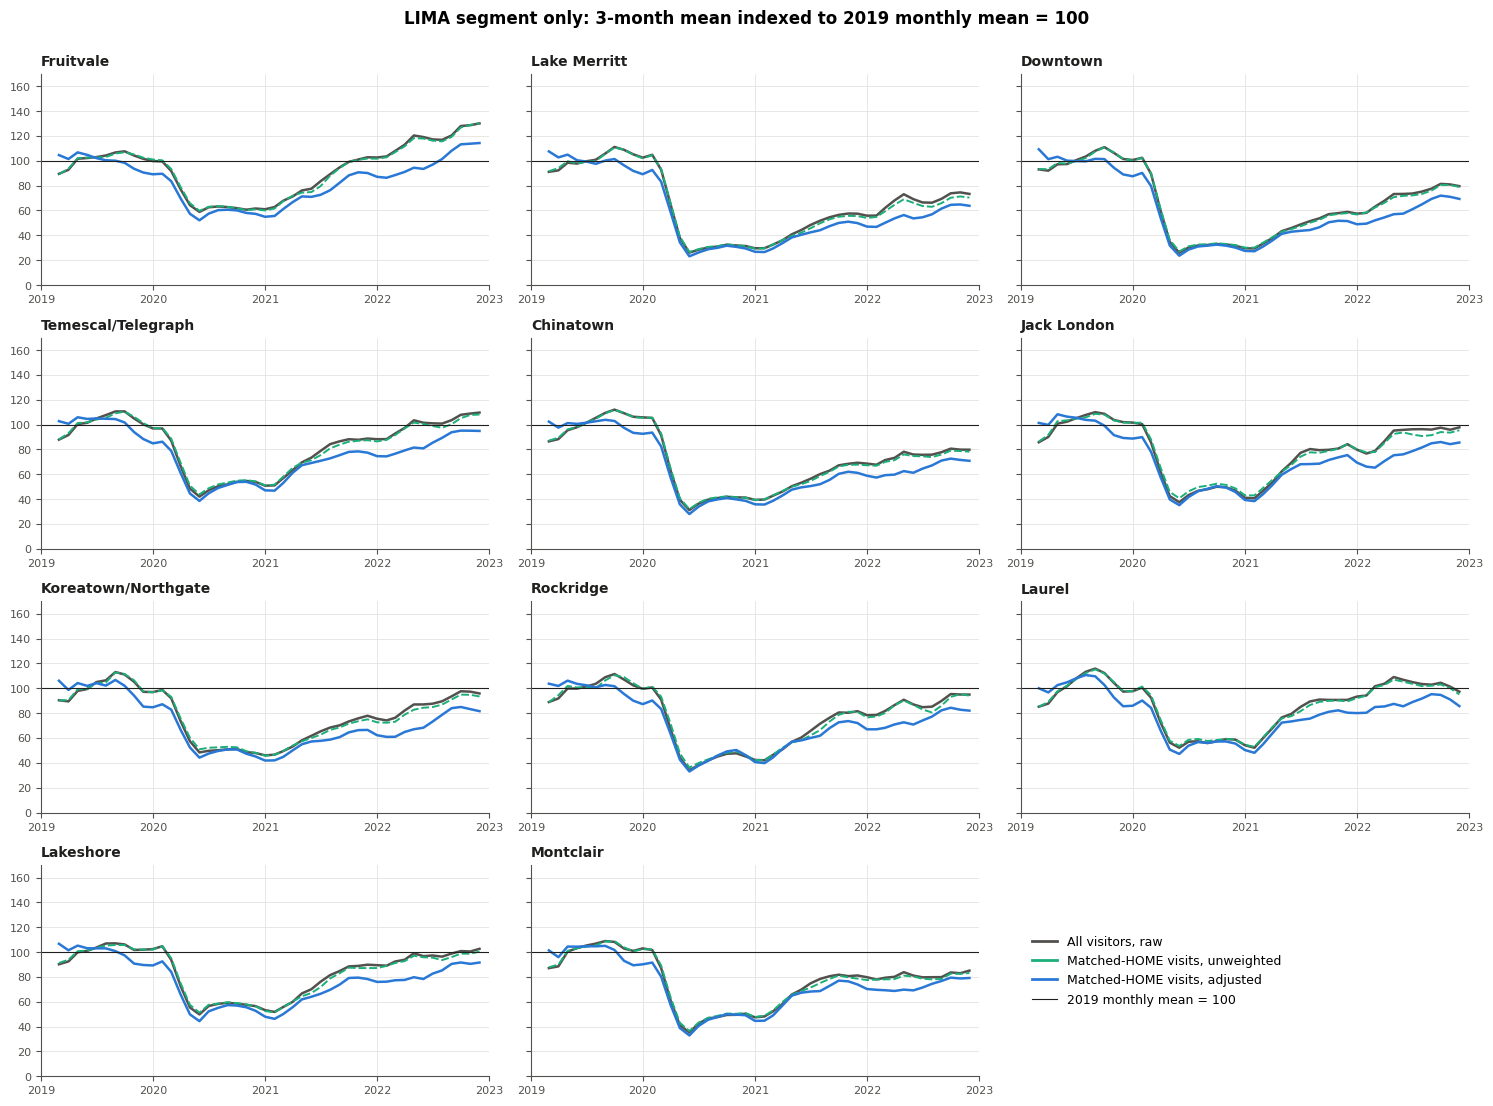

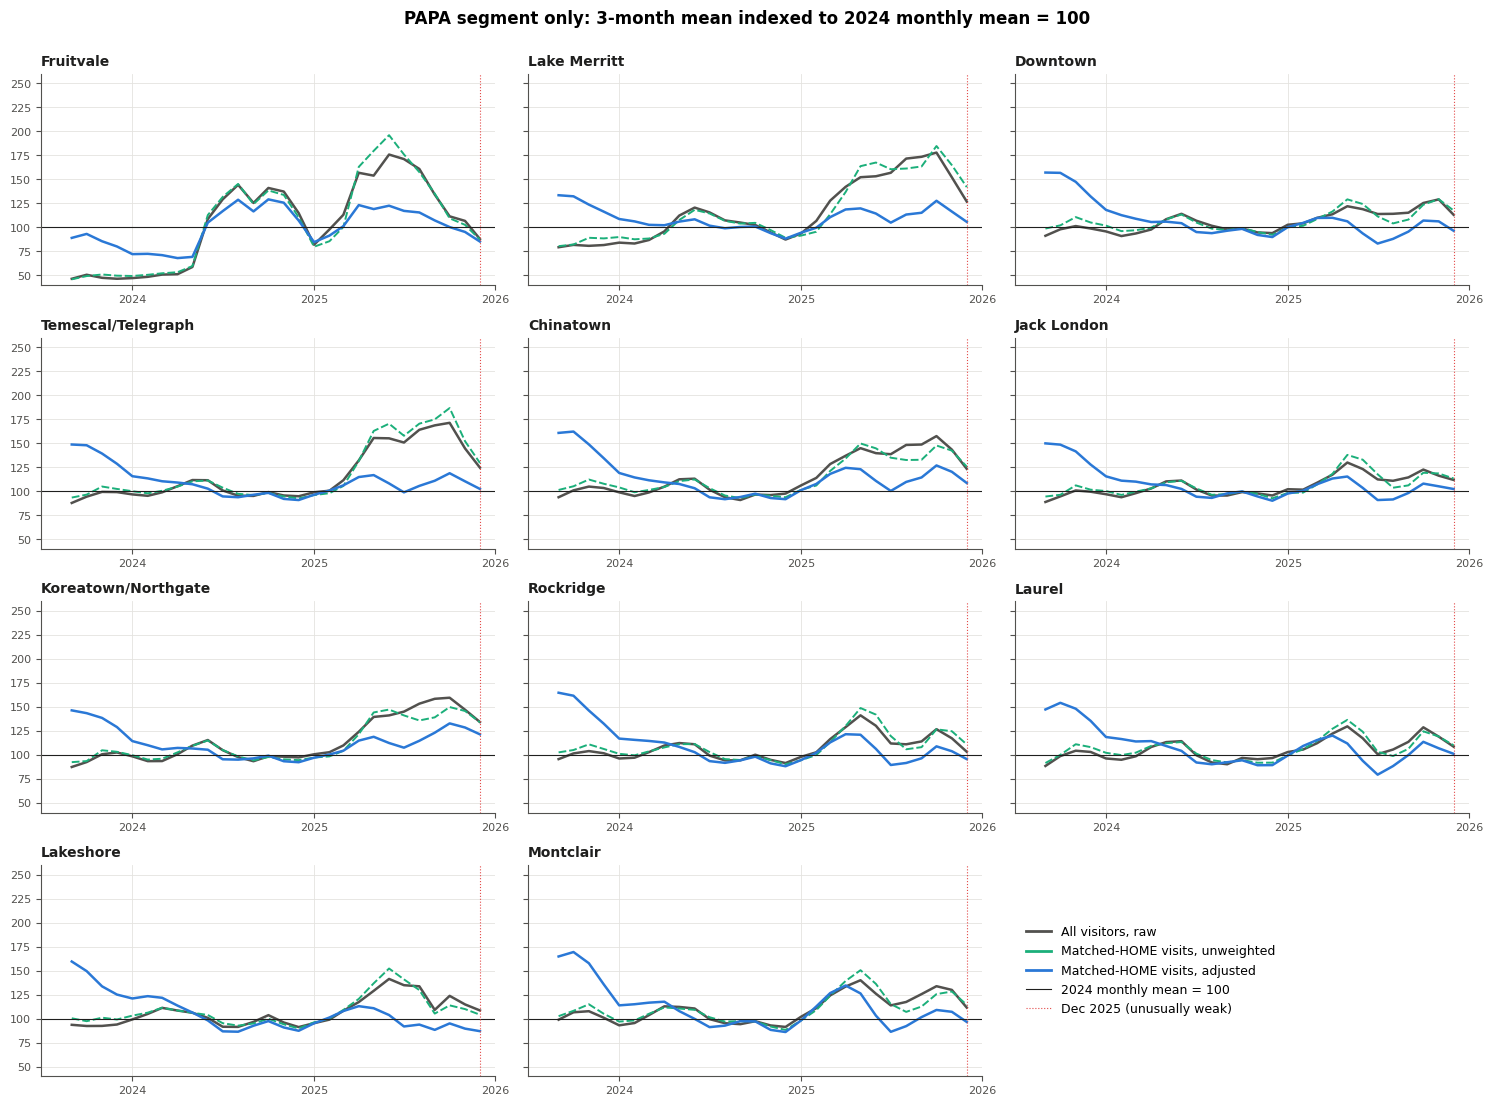

In [15]:
def index_frame(seg_prov, ref_year, months_range):
    d = act[act.provider_id == seg_prov].copy()
    for col, name in [('visit_count', 'raw'), ('home_matched_visits', 'matched'), ('adjusted_known_home_visits', 'adjusted')]:
        ref = d[d.year == ref_year].groupby('corridor_name')[col].mean()
        d['idx_' + name] = 100 * d[col] / d.corridor_name.map(ref)
        d['idxma_' + name] = d.sort_values('year_month').groupby('corridor_name')['idx_' + name].transform(lambda s: s.rolling(3, min_periods=3).mean())
    return d

lima_idx = index_frame('LIMA', BASE_YEAR, None)
papa_idx = index_frame('PAPA', COMPARISON_YEAR, None)

def draw_index(frame, xlim, ylim, ref_label, mark_dec=False):
    def draw(ax, c):
        g = frame[frame.corridor_name == c]
        for m, (lab, col) in MEASURES.items():
            ax.plot(g.date, g['idxma_' + m], color=col, lw=1.8 if m != 'matched' else 1.4, ls='-' if m != 'matched' else (0, (4, 1.5)))
        ax.axhline(100, color=INK, lw=0.8)
        ax.set_ylim(*ylim); ax.set_xlim(*xlim)
        if mark_dec: ax.axvline(pd.Timestamp('2025-12-01'), color=C_RED, lw=0.8, ls=':')
    return draw

lima_legend = [plt.Line2D([], [], color=col, lw=2, label=lab) for lab, col in MEASURES.values()] + [plt.Line2D([], [], color=INK, lw=0.8, label='2019 monthly mean = 100')]
papa_legend = [plt.Line2D([], [], color=col, lw=2, label=lab) for lab, col in MEASURES.values()] + [plt.Line2D([], [], color=INK, lw=0.8, label='2024 monthly mean = 100'), plt.Line2D([], [], color=C_RED, lw=0.8, ls=':', label='Dec 2025 (unusually weak)')]
def small_multiples_clean(draw, title, legend, xlim):
    fig, axes = plt.subplots(4, 3, figsize=(15, 11), sharey=True)
    for i, (ax, c) in enumerate(zip(axes.flat, CORRIDORS)):
        draw(ax, c); ax.set_title(c, loc='left'); year_axis(ax)
    axes.flat[11].axis('off'); axes.flat[11].legend(handles=legend, loc='center left', fontsize=9)
    fig.suptitle(title, y=1.0, fontsize=12, fontweight='bold'); plt.tight_layout(); plt.show()

small_multiples_clean(draw_index(lima_idx, (pd.Timestamp('2019-01-01'), pd.Timestamp('2023-01-01')), (0, 170), '2019'),
                      'LIMA segment only: 3-month mean indexed to 2019 monthly mean = 100', lima_legend, None)
small_multiples_clean(draw_index(papa_idx, (pd.Timestamp('2023-07-01'), pd.Timestamp('2026-01-01')), (40, 260), '2024', mark_dec=True),
                      'PAPA segment only: 3-month mean indexed to 2024 monthly mean = 100', papa_legend, None)

**Within-segment indices.** In LIMA the three lenses agree on timing and shape; the adjusted series sits lower in 2021–2022 because the Bay sample is larger than in 2019 (average weight below one). In PAPA, **raw and unweighted matched series move together**, so restricting to matched origins changes little, while the **adjusted series is flatter** than both: the raw three-month mean peaks at 130–180% of the 2024 mean in 2025 (Lake Merritt, Fruitvale and Temescal/Telegraph highest) and matched visits at 130–195%, whereas the adjusted peaks are 110–135%. Where all three rise together (e.g. Koreatown/Northgate, Chinatown, Lake Merritt) the signal is not a weighting artefact; where the unadjusted lines rise far more than the adjusted one (Temescal/Telegraph raw 171 vs adjusted 119 at the 2025 peak; Fruitvale 176 vs 123; Lakeshore 141 vs 113) panel growth is a likely contributor.

### 3.2 LIMA (2019–2022): the 2020 decline and the recovery
Comparisons use the **same calendar month in 2019** as the reference (so seasonality cancels) and annual monthly means. *Recovery* is defined, deliberately simply, as the first month after the 2020 trough when the trailing three-month mean reaches **90%** of the matching 2019 months. Everything here is within one provider (LIMA).

In [16]:
lima = act[act.provider_id == 'LIMA'].copy()
def same_month_ratio(df, col):
    p = df.pivot_table(index=['corridor_name', 'month'], columns='year', values=col)
    return {y: (p[y] / p[BASE_YEAR]).unstack('month') for y in [2020, 2021, 2022]}   # corridor × month

def annual_ratio(df, col):
    a = df.groupby(['corridor_name', 'year'])[col].mean().unstack()
    return a[[2020, 2021, 2022]].div(a[BASE_YEAR], axis=0)

lima_rows = {}
for lens, col in [('raw', 'visit_count'), ('adjusted', 'adjusted_known_home_visits')]:
    sm = same_month_ratio(lima, col)
    long = pd.concat({y: sm[y].stack() for y in sm}, names=['year', 'corridor_name', 'month']).rename('ratio').reset_index()
    long['year_month'] = long.year * 100 + long.month
    long = long.sort_values(['corridor_name', 'year_month'])
    long['ratio3'] = long.groupby('corridor_name').ratio.transform(lambda s: s.rolling(3, min_periods=3).mean())
    res = {}
    for c, g in long.groupby('corridor_name'):
        g2020 = g[g.year == 2020]
        trough = g2020.loc[g2020.ratio.idxmin()]
        after = g[(g.year_month >= trough.year_month) & (g.ratio3 >= RECOVERY_THRESHOLD)]
        res[c] = {'trough month': pd.to_datetime(str(int(trough.year_month)), format='%Y%m').strftime('%b %Y'), 'trough ratio': trough.ratio,
                  'first month 3-mo ≥ 90%': pd.to_datetime(str(int(after.year_month.iloc[0])), format='%Y%m').strftime('%b %Y') if len(after) else 'not by Dec 2022',
                  'Q4 2022 vs Q4 2019': g[(g.year == 2022) & g.month.isin([10, 11, 12])].ratio.mean()}
    lima_rows[lens] = pd.DataFrame(res).T
    lima_rows[lens]['trough ratio'] = lima_rows[lens]['trough ratio'].astype(float)
    lima_rows[lens]['Q4 2022 vs Q4 2019'] = lima_rows[lens]['Q4 2022 vs Q4 2019'].astype(float)
    lima_rows[lens + '_sm'] = sm
ann_raw, ann_adj = annual_ratio(lima, 'visit_count'), annual_ratio(lima, 'adjusted_known_home_visits')
lima_tbl = pd.concat({'annual ratio vs 2019 (raw)': ann_raw.rename(columns=str), 'annual ratio vs 2019 (adjusted)': ann_adj.rename(columns=str)}, axis=1).reindex(CORRIDORS)
lima_tbl[('timing (raw)', 'trough')] = lima_rows['raw']['trough month']
lima_tbl[('timing (raw)', 'trough ratio')] = lima_rows['raw']['trough ratio']
lima_tbl[('timing (raw)', 'recovery month')] = lima_rows['raw']['first month 3-mo ≥ 90%']
lima_tbl[('timing (adjusted)', 'recovery month')] = lima_rows['adjusted']['first month 3-mo ≥ 90%']
lima_tbl[('Q4 2022 vs Q4 2019', 'raw')] = lima_rows['raw']['Q4 2022 vs Q4 2019']
lima_tbl[('Q4 2022 vs Q4 2019', 'adjusted')] = lima_rows['adjusted']['Q4 2022 vs Q4 2019']
display(lima_tbl.round(2).sort_values(('annual ratio vs 2019 (raw)', '2022'), ascending=False))

annual ratio vs 2019 (raw)           annual ratio vs 2019 (adjusted)           timing (raw)                               timing (adjusted) Q4 2022 vs Q4 2019         
year                                      2020 2021 2022                            2020 2021 2022       trough trough ratio   recovery month    recovery month                raw adjusted
corridor_name                                                                                                                                                                              
Fruitvale                                 0.69 0.86 1.19                            0.63 0.76 1.01     Apr 2020         0.55         Oct 2021          Oct 2021               1.28     1.26
Laurel                                    0.65 0.80 1.02                            0.61 0.72 0.88     Sep 2020         0.46         Dec 2021          Dec 2021               1.00     1.00
Temescal/Telegraph                        0.59 0.76 1.02                            0.55 0.69 0.86     Apr 2020         0.37         Jan 2022          Oct 2022               1.10     1.08
Lakeshore                                 0.65 0.75 0.98                            0.60 0.67 0.84     Apr 2020         0.42         Jan 2022          Oct 2022               1.01     1.02
Jack London                               0.54 0.70 0.92                            0.52 0.63 0.78     Apr 2020         0.32         Mar 2022          Nov 2022               0.96     0.96
Rockridge                                 0.54 0.66 0.88                            0.52 0.61 0.76     Apr 2020         0.31         Mar 2022          Dec 2022               0.93     0.91
Koreatown/Northgate                       0.60 0.65 0.88                            0.56 0.57 0.74     Sep 2020         0.42         Apr 2022          Dec 2022               0.99     0.96
Montclair                                 0.55 0.71 0.81                            0.52 0.66 0.74     Apr 2020         0.27         Mar 2022   not by Dec 2022               0.84     0.89
Chinatown                                 0.51 0.57 0.76                            0.47 0.51 0.66     Apr 2020         0.27  not by Dec 2022   not by Dec 2022               0.75     0.76
Downtown                                  0.45 0.48 0.73                            0.41 0.43 0.62     Apr 2020         0.22  not by Dec 2022   not by Dec 2022               0.79     0.78
Lake Merritt                              0.45 0.47 0.68                            0.41 0.42 0.57     Apr 2020         0.25  not by Dec 2022   not by Dec 2022               0.70     0.70

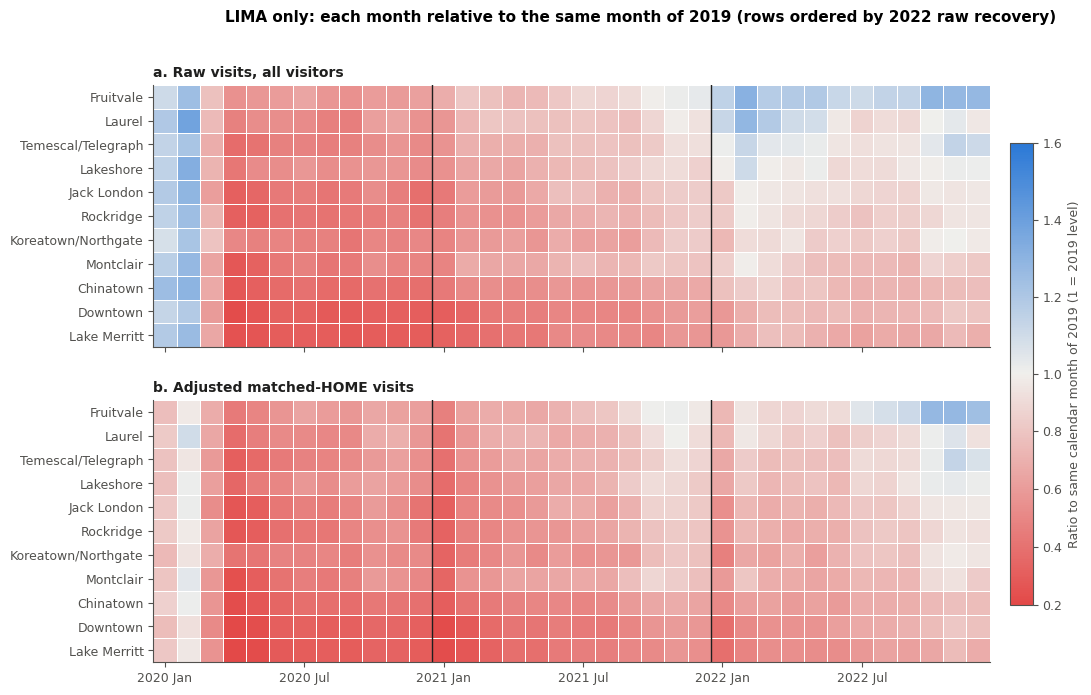

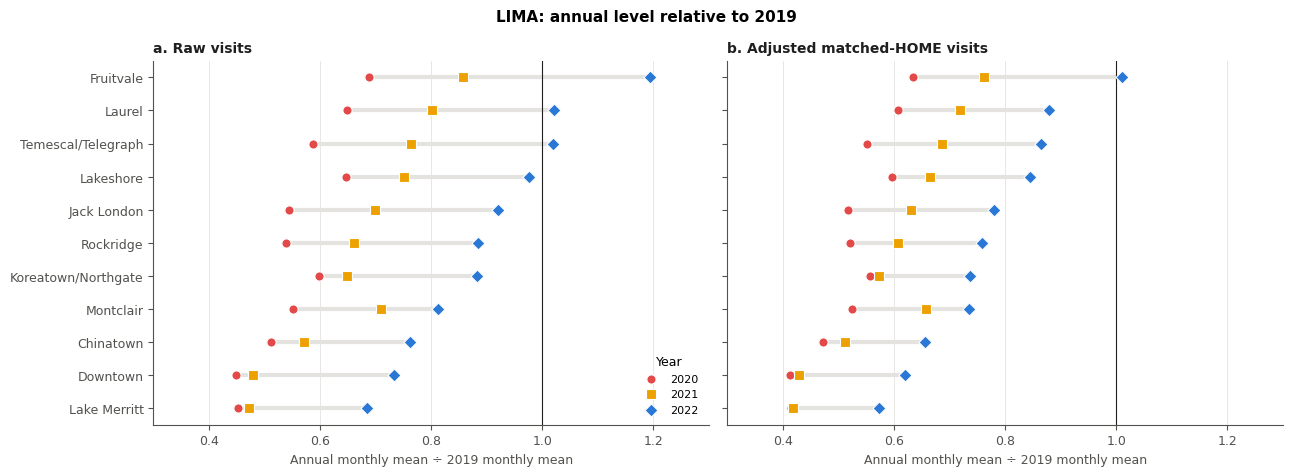

In [17]:
order_l = ann_raw.sort_values(2022, ascending=False).index.tolist()
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
norm = TwoSlopeNorm(vcenter=1.0, vmin=0.2, vmax=1.6)
for ax, lens, ttl in [(axes[0], 'raw', 'a. Raw visits, all visitors'), (axes[1], 'adjusted', 'b. Adjusted matched-HOME visits')]:
    sm = lima_rows[lens + '_sm']
    mat = np.hstack([sm[y].reindex(order_l).to_numpy() for y in [2020, 2021, 2022]])
    mesh = ax.pcolormesh(np.arange(37), np.arange(len(order_l) + 1), np.vstack([mat, mat[-1:]]) if False else mat, cmap=DIVERGING, norm=norm, edgecolors='white', linewidth=0.5)
    ax.set_yticks(np.arange(len(order_l)) + 0.5); ax.set_yticklabels(order_l); ax.invert_yaxis(); ax.grid(False)
    ax.set_title(ttl, loc='left')
ticks = np.arange(0, 36, 6) + 0.5
axes[1].set_xticks(ticks); axes[1].set_xticklabels([f'{y} {m}' for y in [2020, 2021, 2022] for m in ['Jan', 'Jul']])
for ax in axes: [ax.axvline(x, color=INK, lw=1) for x in (12, 24)]
cb = fig.colorbar(mesh, ax=axes, shrink=0.8, pad=0.02); cb.set_label('Ratio to same calendar month of 2019 (1 = 2019 level)')
fig.suptitle('LIMA only: each month relative to the same month of 2019 (rows ordered by 2022 raw recovery)', fontsize=11, fontweight='bold', y=0.98)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, ratio, ttl in [(axes[0], ann_raw, 'a. Raw visits'), (axes[1], ann_adj, 'b. Adjusted matched-HOME visits')]:
    y = np.arange(len(order_l))[::-1]
    ax.hlines(y, ratio.loc[order_l].min(axis=1), ratio.loc[order_l].max(axis=1), color=GRID, lw=3, zorder=1)
    for yr, col, mk in [(2020, C_RED, 'o'), (2021, C_YELLOW, 's'), (2022, C_BLUE, 'D')]:
        ax.scatter(ratio.loc[order_l, yr], y, s=44, color=col, marker=mk, zorder=3, label=str(yr), edgecolor='white', lw=0.8)
    ax.axvline(1, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_l); ax.set_title(ttl, loc='left')
    ax.set_xlabel('Annual monthly mean ÷ 2019 monthly mean'); ax.set_xlim(0.3, 1.3); ax.grid(axis='y', visible=False)
axes[0].legend(loc='lower right', title='Year', fontsize=8)
fig.suptitle('LIMA: annual level relative to 2019', fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()

**Takeaways: LIMA decline and recovery (2019–2022)**
- **The 2020 decline was severe everywhere**: the worst month stood at only 22% (Downtown) to 55% (Fruitvale) of the same month in 2019 (Apr 2020 for nine corridors; Sep 2020 for Laurel and Koreatown/Northgate). The 2020 annual level was 45–69% of 2019 (raw).
- **Neighbourhood corridors recovered first.** Measured against the same months of 2019 (raw), the first month with a three-month mean at or above 90% was Fruitvale (Oct 2021), Laurel (Dec 2021), Temescal/Telegraph and Lakeshore (Jan 2022), then Jack London, Rockridge and Montclair (Mar 2022) and Koreatown/Northgate (Apr 2022). **Chinatown, Downtown and Lake Merritt had not reached 90% by December 2022** (2022 annual raw ratios 0.76, 0.73, 0.68), and they were the three busiest corridors in 2019. Fruitvale (1.19), Laurel (1.02), Temescal/Telegraph (1.02) and Lakeshore (0.98) were at or above their 2019 annual level by 2022.
- **Relative position changed within LIMA.** Fruitvale gained 3.0 points of the 11-corridor share (7.5% → 10.5%) and Temescal/Telegraph 2.1; Lake Merritt lost 3.3, Downtown 2.2 and Chinatown 1.8 (Chinatown stayed first).
- *Why* the order looks like this is examined in sections 5.1 (origins) and 6.3 (weekday vs weekend).
- **The adjusted lens is more pessimistic by about 0.13 on average** (only Fruitvale reaches 1.0, and recovery months slip to Oct–Dec 2022 for Temescal/Telegraph, Lakeshore, Jack London, Rockridge and Koreatown/Northgate). The *order* of corridors is identical (ρ = 1.00), and the grouping (fast / slower / lagging) survives, so the ranking of recovery speed is robust while its level depends on the weights. Because LIMA adjusted weights use the Bay-wide fallback for ~46% of matched visits, the raw lens is the better guide within LIMA.

### 3.3 PAPA (Jul 2023–Dec 2025): 2024 versus 2025
The comparison that matters most is 2025 against 2024 (both complete years in one provider). Three lenses separate two effects: **raw** (all visitors), **matched, unweighted** (the same devices that survive HOME matching, with no sample weights) and **adjusted** (matched and weighted). *Raw → matched* isolates the effect of restricting to matched origins; *matched → adjusted* isolates the effect of the sample weights. Every comparison is also run on **January–November in both years**, since December 2025 is unusually weak across most corridors (see section 7), plus a leave-one-month-out range, so the headline does not depend on a favourable window.

In [18]:
papa = act[act.provider_id == 'PAPA'].copy()
LENSES = {'raw': 'visit_count', 'matched': 'home_matched_visits', 'adjusted': 'adjusted_known_home_visits'}
def yoy_change(df, col, months, y0=COMPARISON_YEAR, y1=FOCUS_YEAR):
    s = df[df.month.isin(months)].groupby(['corridor_name', 'year'])[col].sum().unstack()
    return pct_change(s[y0], s[y1])

cols = {}
for wname, wmonths in SAME_WINDOWS.items():
    for lens, col in LENSES.items():
        cols[(wname, lens)] = yoy_change(papa, col, wmonths)
papa_yoy = pd.DataFrame(cols).reindex(CORRIDORS)
papa_yoy.columns = pd.MultiIndex.from_tuples(papa_yoy.columns)
display(papa_yoy.round(1))

sm_yoy = {}
for lens, col in LENSES.items():
    p = papa[papa.year.isin([2024, 2025])].pivot_table(index='corridor_name', columns=['year', 'month'], values=col)
    sm_yoy[lens] = pd.DataFrame({m: pct_change(p[(2024, m)], p[(2025, m)]) for m in range(1, 13)}).reindex(CORRIDORS)
city_p = papa[papa.year.isin([2024, 2025])].groupby(['year', 'month'])[list(LENSES.values())].sum()
for lens, col in LENSES.items():
    sm_yoy[lens].loc['Sum of 11 corridors'] = [pct_change(city_p.loc[(2024, m), col], city_p.loc[(2025, m), col]) for m in range(1, 13)]

def leave_one_out(col):
    out = {}
    s = papa[papa.year.isin([2024, 2025])].pivot_table(index='corridor_name', columns=['year', 'month'], values=col)
    for c in CORRIDORS:
        vals = [pct_change(s.loc[c, 2024].drop(m).sum(), s.loc[c, 2025].drop(m).sum()) for m in range(1, 13)]
        out[c] = (min(vals), max(vals))
    return out
loo = leave_one_out('adjusted_known_home_visits')
loo_raw = leave_one_out('visit_count')
summary_p = pd.DataFrame({
    'adjusted Δ%, full year': papa_yoy[('Full year (Jan–Dec)', 'adjusted')],
    'adjusted Δ%, Jan–Nov': papa_yoy[('Jan–Nov (December excluded)', 'adjusted')],
    'adjusted: leave-one-month-out range': [f'{loo[c][0]:+.1f} to {loo[c][1]:+.1f}' for c in CORRIDORS],
    'adjusted: months up (of 12)': (sm_yoy['adjusted'].loc[CORRIDORS] > 0).sum(axis=1),
    'adjusted: median same-month Δ%': sm_yoy['adjusted'].loc[CORRIDORS].median(axis=1),
    'raw Δ%, full year': papa_yoy[('Full year (Jan–Dec)', 'raw')],
    'raw: months up (of 12)': (sm_yoy['raw'].loc[CORRIDORS] > 0).sum(axis=1)}, index=CORRIDORS)
display(summary_p.round(1))

Full year (Jan–Dec)                  Jan–Nov (December excluded)                 
                                    raw matched adjusted                         raw matched adjusted
corridor_name                                                                                        
Fruitvale                         27.80   29.70     4.10                       31.80   33.50     5.80
Lake Merritt                      45.40   46.70    11.60                       49.10   49.90    13.30
Downtown                          14.40   14.70    -1.10                       19.00   17.60     1.50
Temescal/Telegraph                39.90   45.00     6.80                       44.80   49.80     9.00
Chinatown                         34.90   31.00    12.90                       41.10   35.50    16.50
Jack London                       14.50   14.80     2.80                       15.90   15.80     3.30
Koreatown/Northgate               36.00   31.20    15.40                       39.00   33.90    17.10
Rockridge                         16.10   18.60     2.90                       19.70   21.50     5.10
Laurel                            13.00   13.80     2.60                       16.50   16.60     4.50
Lakeshore                         16.90   17.70    -3.20                       20.80   20.90    -1.20
Montclair                         21.80   21.80     7.00                       26.90   25.80    10.50

,"adjusted Δ%, full year","adjusted Δ%, Jan–Nov",adjusted: leave-one-month-out range,adjusted: months up (of 12),adjusted: median same-month Δ%,"raw Δ%, full year",raw: months up (of 12)
Fruitvale,4.10,5.80,-2.0 to +9.9,5,-5.30,27.80,6
Lake Merritt,11.60,13.30,+7.9 to +13.7,8,8.90,45.40,11
Downtown,-1.10,1.50,-4.2 to +1.5,5,-1.40,14.40,10
Temescal/Telegraph,6.80,9.00,+3.9 to +9.0,7,4.40,39.90,10
Chinatown,12.90,16.50,+9.1 to +16.5,8,12.00,34.90,11
Jack London,2.80,3.30,+0.1 to +4.3,6,-1.10,14.50,9
Koreatown/Northgate,15.40,17.10,+11.2 to +17.8,8,11.30,36.00,12
Rockridge,2.90,5.10,+0.3 to +5.1,6,2.20,16.10,9
Laurel,2.60,4.50,-0.9 to +5.5,7,4.90,13.00,9
Lakeshore,-3.20,-1.20,-5.5 to -1.0,6,-0.40,16.90,8


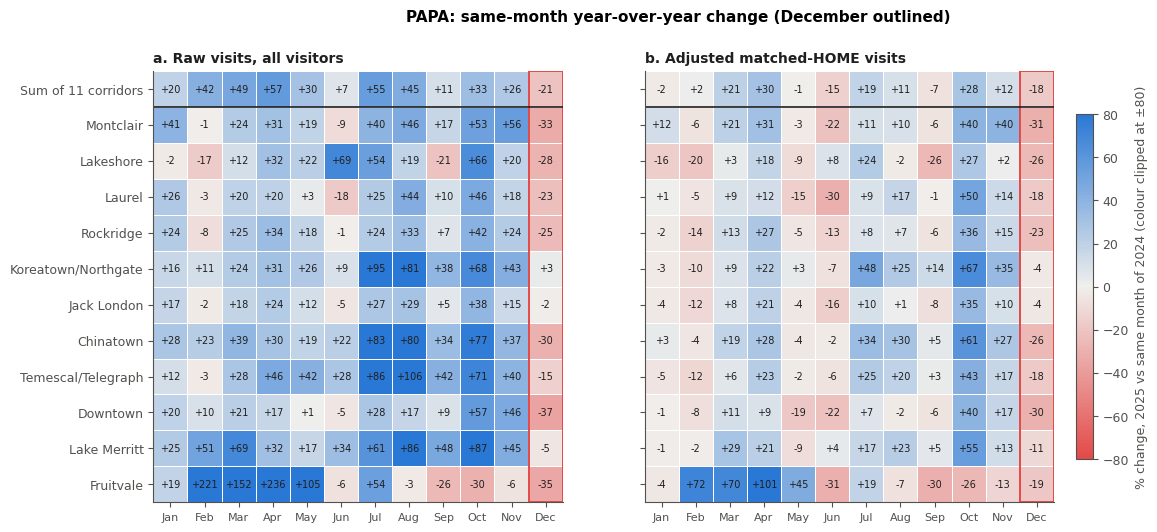

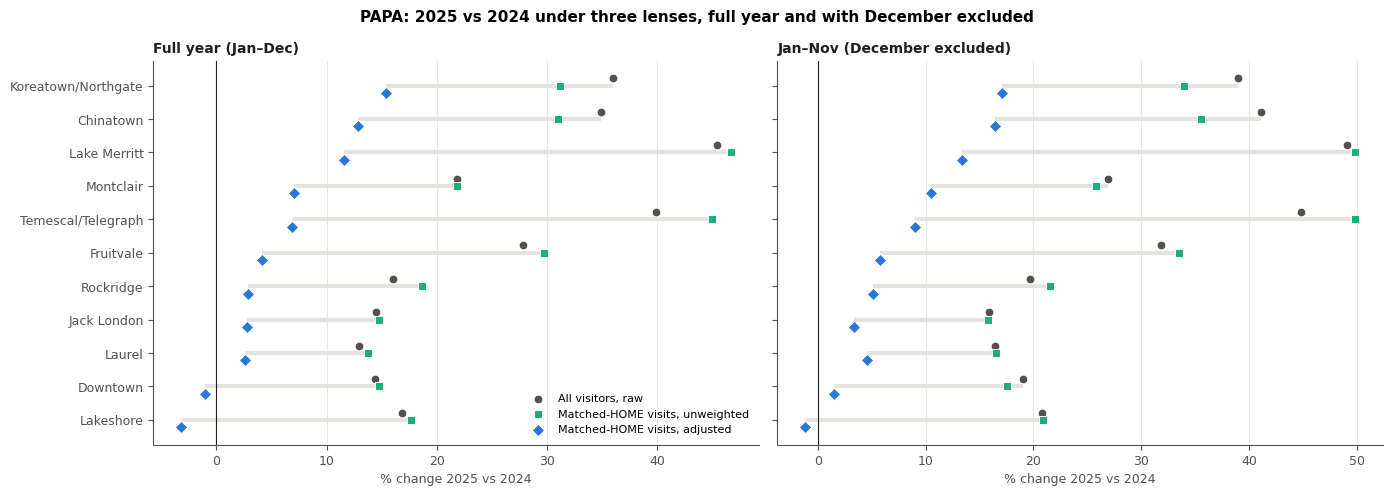

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)
norm = TwoSlopeNorm(vcenter=0, vmin=-80, vmax=80)
rows = CORRIDORS + ['Sum of 11 corridors']
for ax, lens, ttl in [(axes[0], 'raw', 'a. Raw visits, all visitors'), (axes[1], 'adjusted', 'b. Adjusted matched-HOME visits')]:
    mat = sm_yoy[lens].loc[rows].to_numpy()
    mesh = ax.pcolormesh(np.arange(13), np.arange(len(rows) + 1), mat, cmap=DIVERGING, norm=norm, edgecolors='white', linewidth=0.6)
    for i in range(mat.shape[0]):
        for j in range(12):
            ax.text(j + 0.5, i + 0.5, f'{mat[i, j]:+.0f}', ha='center', va='center', fontsize=7, color=INK)
    ax.set_xticks(np.arange(12) + 0.5); ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=8)
    ax.set_yticks(np.arange(len(rows)) + 0.5); ax.set_yticklabels(rows); ax.invert_yaxis(); ax.grid(False); ax.set_title(ttl, loc='left')
    ax.axhline(len(CORRIDORS), color=INK, lw=1.2)
    ax.add_patch(plt.Rectangle((11, 0), 1, len(rows), fill=False, ec=C_RED, lw=1.4))
cb = fig.colorbar(mesh, ax=axes, shrink=0.8, pad=0.02); cb.set_label('% change, 2025 vs same month of 2024 (colour clipped at ±80)')
fig.suptitle('PAPA: same-month year-over-year change (December outlined)', fontsize=11, fontweight='bold', y=0.99)
plt.show()

order_p = papa_yoy[('Full year (Jan–Dec)', 'adjusted')].sort_values(ascending=False).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
y = np.arange(len(order_p))[::-1]
for ax, wname in zip(axes, SAME_WINDOWS):
    for lens, off, mk in [('raw', 0.22, 'o'), ('matched', 0, 's'), ('adjusted', -0.22, 'D')]:
        ax.scatter(papa_yoy.loc[order_p, (wname, lens)], y + off, s=40, color=MEASURES[lens][1], marker=mk, edgecolor='white', lw=0.7, label=MEASURES[lens][0], zorder=3)
    ax.hlines(y, papa_yoy.loc[order_p, wname].min(axis=1), papa_yoy.loc[order_p, wname].max(axis=1), color=GRID, lw=3, zorder=1)
    ax.axvline(0, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_p); ax.grid(axis='y', visible=False)
    ax.set_title(wname, loc='left'); ax.set_xlabel('% change 2025 vs 2024')
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('PAPA: 2025 vs 2024 under three lenses, full year and with December excluded', fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()

**Takeaways: PAPA 2025 vs 2024**
- **Raw growth is large and universal; adjusted growth is modest and uneven.** Full-year raw visits are up 13% (Laurel) to 45% (Lake Merritt); matched-unweighted is within five points of raw; adjusted is −3% (Lakeshore) to +15% (Koreatown/Northgate). Sample weighting, not the restriction to matched origins, produces the difference (citywide +29.0% raw, +29.6% matched, +6.3% adjusted).
- **The window does not change the picture.** Excluding December from both years raises every adjusted change by 0.5–3.6 points (e.g. Chinatown +12.9% → +16.5%) and only Downtown flips sign (−1.1% → +1.5%); the order of corridors is almost unchanged (ρ = 0.99).
- **Sustained growth (positive in the full year, in Jan–Nov, in every leave-one-month-out test, and in 8 of 12 same-month comparisons):** Koreatown/Northgate (+15.4% full year, +17.1% Jan–Nov), Chinatown (+12.9%, +16.5%) and Lake Merritt (+11.6%, +13.3%). **Modest growth:** Temescal/Telegraph (+6.8%) and Montclair (+7.0%). **Roughly stable:** Downtown, Jack London, Rockridge and Laurel (−1% to +3%). **Slight weakening:** Lakeshore (−3.2%, negative in every leave-one-out test). **Unclear:** Fruitvale (+4.1% with a leave-one-out range of −2.0% to +9.9%, only 5 of 12 months up, median month −5%), where one or two spikes carry the result.
- **Not every change is a trend.** The same-month heatmap shows what is seasonal, isolated or panel-wide: April 2025 is strongly up in the raw lens for every corridor (+17% to +236%), October 2025 is strongly up in both lenses in ten corridors (adjusted +27% to +67%; Fruitvale is the exception at −26%), and December 2025 is down in ten of eleven corridors in the raw lens and all eleven in the adjusted lens (adjusted −4% to −31%). The raw rise from April is partly a panel effect (visits per device step up from April; section 7). Fruitvale's large Feb–May 2025 changes are against an unusually low early-2024 base and a series with spikes.

In [20]:
def neighbour_ratio(g, col):
    s = g.sort_values('year_month')[col].to_numpy(dtype=float)
    out = np.full(len(s), np.nan)
    for i in range(len(s)):
        nb = [s[j] for j in (i - 2, i - 1, i + 1, i + 2) if 0 <= j < len(s)]
        if len(nb) >= 2:
            out[i] = s[i] / np.median(nb)
    return pd.Series(out, index=g.sort_values('year_month').index)

act['neighbour_ratio'] = np.nan
for _, g in act.groupby(['corridor_name', 'provider_segment']):
    act.loc[g.index, 'neighbour_ratio'] = neighbour_ratio(g, 'visit_count')
spikes = act[(act.neighbour_ratio >= SPIKE_RATIO) | (act.neighbour_ratio <= 1 / SPIKE_RATIO)].copy()
spikes = spikes[~spikes.year_month.isin([202003, 202004, 202005, 202006])]       # the expected pandemic collapse
spike_tbl = spikes[['corridor_name', 'year_month', 'provider_id', 'visit_count', 'neighbour_ratio', 'visits_per_unique_device', 'home_match_rate']].sort_values(['provider_id', 'year_month', 'corridor_name'])
spike_tbl.columns = ['corridor', 'month', 'provider', 'raw visits', 'ratio to median of 4 neighbouring months', 'visits per device', 'HOME-match rate']
print(f'Corridor-months whose raw visits are ≥{SPIKE_RATIO}× or ≤1/{SPIKE_RATIO}× the median of the four nearest months in the same segment (Mar–Jun 2020 excluded):')
display(spike_tbl.round(2).reset_index(drop=True))

Corridor-months whose raw visits are ≥1.4× or ≤1/1.4× the median of the four nearest months in the same segment (Mar–Jun 2020 excluded):


,corridor,month,provider,raw visits,ratio to median of 4 neighbouring months,visits per device,HOME-match rate
0,Fruitvale,202406,PAPA,79938,2.12,1.58,0.38
1,Fruitvale,202410,PAPA,68404,1.53,1.38,0.35
2,Fruitvale,202412,PAPA,29442,0.56,1.22,0.41
3,Fruitvale,202501,PAPA,28174,0.62,1.26,0.37
4,Fruitvale,202502,PAPA,61915,1.60,1.43,0.28
5,Laurel,202506,PAPA,3822,0.70,1.28,0.52
6,Fruitvale,202507,PAPA,75777,1.46,1.55,0.35
7,Lakeshore,202510,PAPA,6606,1.74,1.31,0.41
8,Chinatown,202512,PAPA,12901,0.50,1.48,0.54
9,Downtown,202512,PAPA,16579,0.46,1.44,0.50


### 3.4 Share of recorded activity within a provider segment
A corridor's **share** is its visits divided by the sum over the 11 corridors in the same segment-year. Shares measure *relative position*, so they change when other corridors change (and because corridors overlap, the denominator is not a distinct-visit total). Shares are also not subject to a common sample-size level shift, which is why they are more robust than levels, but they still depend on the lens (raw vs adjusted).

LIMA raw                                 LIMA adjusted                                 PAPA raw                                 PAPA adjusted                                
year                    2019  2022  Δ pp rank 2019 rank 2022          2019  2022  Δ pp rank 2019 rank 2022     2024  2025  Δ pp rank 2024 rank 2025          2024  2025  Δ pp rank 2024 rank 2025
corridor_name                                                                                                                                                                                    
Fruitvale               7.50 10.50  3.00         6         6          7.70 10.70  3.00         6         5    23.10 22.90 -0.20         1         1         17.90 17.60 -0.40         1         2
Lake Merritt           16.70 13.40 -3.30         2         3         16.70 13.20 -3.50         2         3    17.70 20.00  2.30         2         2         16.80 17.60  0.80         2         1
Downtown               16.00 13.80 -2.20         3         2         15.70 13.40 -2.30         3         2    14.80 13.10 -1.70         3         3         14.50 13.50 -1.00         3         3
Temescal/Telegraph     10.80 12.90  2.10         4         4         10.70 12.80  2.10         4         4     9.90 10.80  0.80         5         4         11.20 11.30  0.10         5         5
Chinatown              17.00 15.20 -1.80         1         1         17.70 16.00 -1.70         1         1    10.00 10.40  0.50         4         5         11.90 12.60  0.70         4         4
Jack London            10.20 11.00  0.80         5         5          9.40 10.10  0.70         5         6     9.40  8.40 -1.10         6         6         10.10  9.70 -0.30         6         6
Koreatown/Northgate     6.10  6.30  0.20         8         8          6.10  6.20  0.10         8         8     5.90  6.20  0.30         7         7          6.60  7.10  0.60         7         7
Rockridge               6.20  6.40  0.20         7         7          6.20  6.50  0.30         7         7     3.00  2.70 -0.30         8         8          3.80  3.70 -0.10         8         8
Laurel                  3.30  4.00  0.70         9         9          3.40  4.20  0.70         9         9     2.50  2.20 -0.30         9         9          2.90  2.80 -0.10         9         9
Lakeshore               3.20  3.70  0.50        10        10          3.30  3.80  0.50        10        10     2.30  2.10 -0.20        10        10          2.70  2.40 -0.20        10        10
Montclair               3.10  2.90 -0.10        11        11          3.20  3.30  0.00        11        11     1.20  1.10 -0.10        11        11          1.60  1.60  0.00        11        11

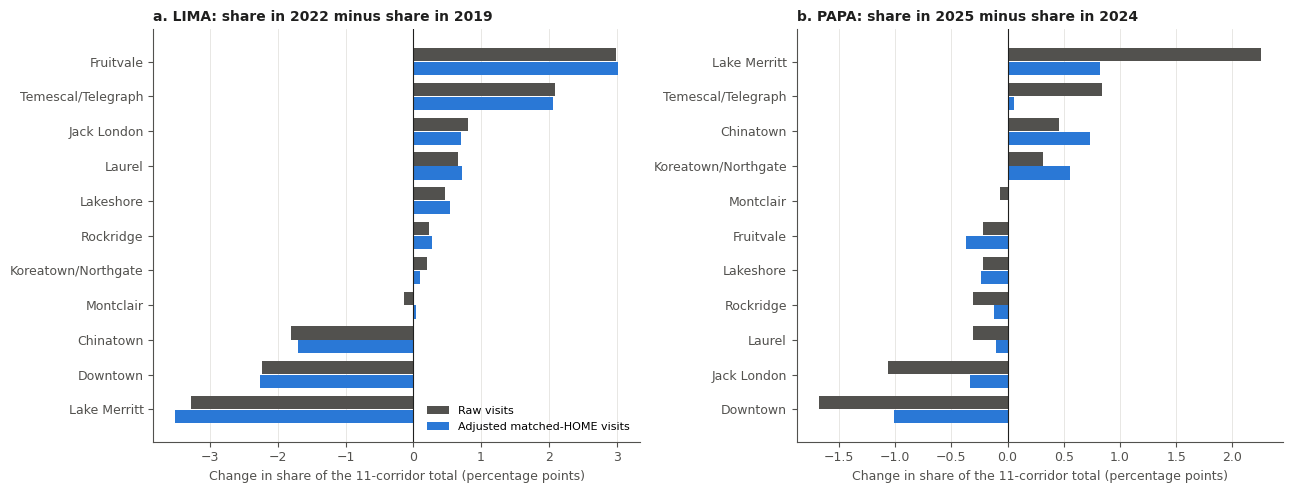

In [21]:
def share_table(prov, y0, y1, col):
    d = act[(act.provider_id == prov) & act.year.isin([y0, y1])]
    s = d.groupby(['corridor_name', 'year'])[col].sum().unstack()
    sh = 100 * s / s.sum()
    out = sh.rename(columns={y0: f'{y0}', y1: f'{y1}'}).reindex(CORRIDORS)
    out['Δ pp'] = out[f'{y1}'] - out[f'{y0}']
    out['rank ' + f'{y0}'] = out[f'{y0}'].rank(ascending=False).astype(int)
    out['rank ' + f'{y1}'] = out[f'{y1}'].rank(ascending=False).astype(int)
    return out
shares = {('LIMA', 'raw'): share_table('LIMA', 2019, 2022, 'visit_count'), ('LIMA', 'adjusted'): share_table('LIMA', 2019, 2022, 'adjusted_known_home_visits'),
          ('PAPA', 'raw'): share_table('PAPA', 2024, 2025, 'visit_count'), ('PAPA', 'adjusted'): share_table('PAPA', 2024, 2025, 'adjusted_known_home_visits')}
share_view = pd.concat({f'{p} {l}': t for (p, l), t in shares.items()}, axis=1)
display(share_view.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, prov, ttl in [(axes[0], 'LIMA', 'a. LIMA: share in 2022 minus share in 2019'), (axes[1], 'PAPA', 'b. PAPA: share in 2025 minus share in 2024')]:
    order_s = shares[(prov, 'raw')]['Δ pp'].sort_values(ascending=False).index
    y = np.arange(len(order_s))[::-1]
    ax.barh(y + 0.2, shares[(prov, 'raw')].loc[order_s, 'Δ pp'], height=0.38, color=INK_2, label='Raw visits')
    ax.barh(y - 0.2, shares[(prov, 'adjusted')].loc[order_s, 'Δ pp'], height=0.38, color=C_BLUE, label='Adjusted matched-HOME visits')
    ax.axvline(0, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_s); ax.grid(axis='y', visible=False)
    ax.set_xlabel('Change in share of the 11-corridor total (percentage points)'); ax.set_title(ttl, loc='left')
axes[0].legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

**Takeaways: shares of recorded activity.** Within LIMA the share shifts are modest but consistent across lenses: Fruitvale +3.0 points and Temescal/Telegraph +2.1, against Lake Merritt −3.3, Downtown −2.2 and Chinatown −1.8 (raw). Within PAPA the raw lens suggests Lake Merritt gaining 2.3 points and Downtown losing 1.7, but the adjusted lens shrinks these to +0.8 and −1.0, and every adjusted change is within ±1.0 point, so **relative positions were essentially stable in 2024–2025**. Shares from different segments are not comparable (Fruitvale is 7.5% of the LIMA 2019 corridor total, but 23% of PAPA 2024); a share shift is also a statement about the other corridors, not only about the corridor itself.

### 3.5 Plain-language trajectory types
These labels are descriptive summaries of the tables above under simple rules (thresholds are constants in the configuration cell). They are not clusters, not a composite score, and the PAPA labels use the **adjusted** lens that is least affected by the sample expansion; the raw lens is shown beside it because it tells a more optimistic story for every corridor.

In [22]:
def lima_label(raw22):
    if raw22 >= 0.95: return 'Recovered to ~2019 level by 2022'
    if raw22 >= 0.80: return 'Mostly recovered (80–95% of 2019)'
    return 'Still well below 2019 (<80%)'

def papa_label(c):
    full = papa_yoy.loc[c, ('Full year (Jan–Dec)', 'adjusted')]; jn = papa_yoy.loc[c, ('Jan–Nov (December excluded)', 'adjusted')]
    lo, hi = loo[c]
    if full < 0 and jn < 0 and hi < 0: return 'Slight weakening'
    if lo < 0 < hi and abs(full) >= STABLE_PCT: return 'Unclear: result depends on one or two months'
    if full >= GROWTH_PCT and jn >= GROWTH_PCT and lo > 0: return 'Sustained growth'
    if full >= STABLE_PCT and lo > 0: return 'Modest growth'
    return 'Roughly stable'

traj = pd.DataFrame({
    'LIMA: raw 2022 ÷ 2019': ann_raw[2022], 'LIMA: adjusted 2022 ÷ 2019': ann_adj[2022],
    'LIMA: raw recovery month': lima_rows['raw']['first month 3-mo ≥ 90%'],
    'PAPA: adjusted Δ% 2025 v 2024': summary_p['adjusted Δ%, full year'], 'PAPA: raw Δ%': summary_p['raw Δ%, full year']}).reindex(CORRIDORS)
traj['LIMA type'] = [lima_label(traj.loc[c, 'LIMA: raw 2022 ÷ 2019']) for c in CORRIDORS]
traj['PAPA type (adjusted lens)'] = [papa_label(c) for c in CORRIDORS]
display(traj.round(2))
print('LIMA types:', traj.groupby('LIMA type').apply(lambda d: list(d.index)).to_dict())
print('PAPA types:', traj.groupby('PAPA type (adjusted lens)').apply(lambda d: list(d.index)).to_dict())

,LIMA: raw 2022 ÷ 2019,LIMA: adjusted 2022 ÷ 2019,LIMA: raw recovery month,PAPA: adjusted Δ% 2025 v 2024,PAPA: raw Δ%,LIMA type,PAPA type (adjusted lens)
Fruitvale,1.19,1.01,Oct 2021,4.13,27.81,Recovered to ~2019 level by 2022,Unclear: result depends on one or two months
Lake Merritt,0.68,0.57,not by Dec 2022,11.56,45.43,Still well below 2019 (<80%),Sustained growth
Downtown,0.73,0.62,not by Dec 2022,-1.05,14.36,Still well below 2019 (<80%),Roughly stable
Temescal/Telegraph,1.02,0.86,Jan 2022,6.83,39.88,Recovered to ~2019 level by 2022,Modest growth
Chinatown,0.76,0.66,not by Dec 2022,12.89,34.93,Still well below 2019 (<80%),Sustained growth
Jack London,0.92,0.78,Mar 2022,2.76,14.48,Mostly recovered (80–95% of 2019),Roughly stable
Koreatown/Northgate,0.88,0.74,Apr 2022,15.35,35.96,Mostly recovered (80–95% of 2019),Sustained growth
Rockridge,0.88,0.76,Mar 2022,2.88,16.06,Mostly recovered (80–95% of 2019),Roughly stable
Laurel,1.02,0.88,Dec 2021,2.62,12.95,Recovered to ~2019 level by 2022,Roughly stable
Lakeshore,0.98,0.84,Jan 2022,-3.22,16.85,Recovered to ~2019 level by 2022,Slight weakening


LIMA types: {'Mostly recovered (80–95% of 2019)': ['Jack London', 'Koreatown/Northgate', 'Rockridge', 'Montclair'], 'Recovered to ~2019 level by 2022': ['Fruitvale', 'Temescal/Telegraph', 'Laurel', 'Lakeshore'], 'Still well below 2019 (<80%)': ['Lake Merritt', 'Downtown', 'Chinatown']}
PAPA types: {'Modest growth': ['Temescal/Telegraph', 'Montclair'], 'Roughly stable': ['Downtown', 'Jack London', 'Rockridge', 'Laurel'], 'Slight weakening': ['Lakeshore'], 'Sustained growth': ['Lake Merritt', 'Chinatown', 'Koreatown/Northgate'], 'Unclear: result depends on one or two months': ['Fruitvale']}


**Takeaways: trajectory types (descriptive).**
- **LIMA:** *recovered to about the 2019 level by 2022* (raw ≥ 0.95): Fruitvale, Laurel, Temescal/Telegraph, Lakeshore; *mostly recovered* (0.80–0.95): Jack London, Koreatown/Northgate, Rockridge, Montclair; *still well below 2019* (< 0.80): Chinatown, Downtown, Lake Merritt.
- **PAPA (adjusted lens):** *sustained growth:* Koreatown/Northgate, Chinatown, Lake Merritt; *modest growth:* Temescal/Telegraph, Montclair; *roughly stable:* Downtown, Jack London, Rockridge, Laurel; *slight weakening:* Lakeshore; *unclear / spike-dependent:* Fruitvale. Under the raw lens every corridor would look like "growth", which is why the labels use the adjusted lens.
- **Reading across the two eras (without joining them):** the three slowest LIMA recoverers include two of the three strongest PAPA growers (Chinatown, Lake Merritt), while none of the four fastest recoverers is in the sustained-growth group. That is a pattern to investigate, not a claim of catch-up, because levels cannot be linked across providers.

## 4. Visitor origins and corridor catchments
Origin composition uses **matched-origin visits as the denominator** (visits from devices with a matched Bay HOME in one of four categories). The unmatched share, which is a different population, is always shown separately and never mixed into those percentages. Adjusted shares weight each device by its CBG's sample weight; raw shares are unweighted counts of the same matched visits. If the two agree, the catchment distinctions do not depend on the weighting.

In [23]:
# Verify the category definitions from the exported geography (the extraction notebook defines them: Oakland by CBG
# representative point inside the TIGER2019 Oakland place polygon; East Bay = Alameda 001 + Contra Costa 013; SF = county 075).
geo_home['county'] = geo_home.block_group_id.str.split('.').str[2]
geo_home['state'] = geo_home.block_group_id.str.split('.').str[1]
xt = pd.crosstab(geo_home.county.map(lambda c: f'{c} {BAY_COUNTIES.get(c, "?")}'), geo_home.home_geography)[ORIGIN_ORDER]
display(xt)
rules = {
    'Every CBG is California (state CA) in a Bay county': bool((geo_home.state == 'CA').all() and geo_home.county.isin(BAY_COUNTIES).all()),
    'Oakland CBGs all lie in Alameda County': bool(geo_home[geo_home.home_geography == 'Oakland'].county.eq('001').all()),
    'San Francisco category = county 075 exactly': bool((geo_home.home_geography.eq('San Francisco') == geo_home.county.eq('075')).all()),
    'Rest East Bay CBGs lie only in Alameda or Contra Costa': bool(geo_home[geo_home.home_geography == 'Rest East Bay'].county.isin(EAST_BAY_COUNTIES).all()),
    'All other Bay CBGs are "Rest Bay Area"': bool(geo_home[~geo_home.county.isin(EAST_BAY_COUNTIES + ['075'])].home_geography.eq('Rest Bay Area').all()),
    'Alameda CBGs outside Oakland are Rest East Bay': bool(geo_home[(geo_home.county == '001') & (geo_home.home_geography != 'Oakland')].home_geography.eq('Rest East Bay').all())}
print('\n'.join(f'{"PASS" if ok else "FAIL"}: {r}' for r, ok in rules.items()))
print('Categories present in the origin table:', sorted(origin.home_geography.unique()))

home_geography,Oakland,San Francisco,Rest East Bay,Rest Bay Area
county,,,,
001 Alameda,336,0,711,0
013 Contra Costa,0,0,637,0
041 Marin,0,0,0,175
055 Napa,0,0,0,106
075 San Francisco,0,579,0,0
081 San Mateo,0,0,0,463
085 Santa Clara,0,0,0,1075
095 Solano,0,0,0,283
097 Sonoma,0,0,0,386


PASS: Every CBG is California (state CA) in a Bay county
PASS: Oakland CBGs all lie in Alameda County
PASS: San Francisco category = county 075 exactly
PASS: Rest East Bay CBGs lie only in Alameda or Contra Costa
PASS: All other Bay CBGs are "Rest Bay Area"
PASS: Alameda CBGs outside Oakland are Rest East Bay
Categories present in the origin table: ['No matched Bay Area HOME', 'Oakland', 'Rest Bay Area', 'Rest East Bay', 'San Francisco']


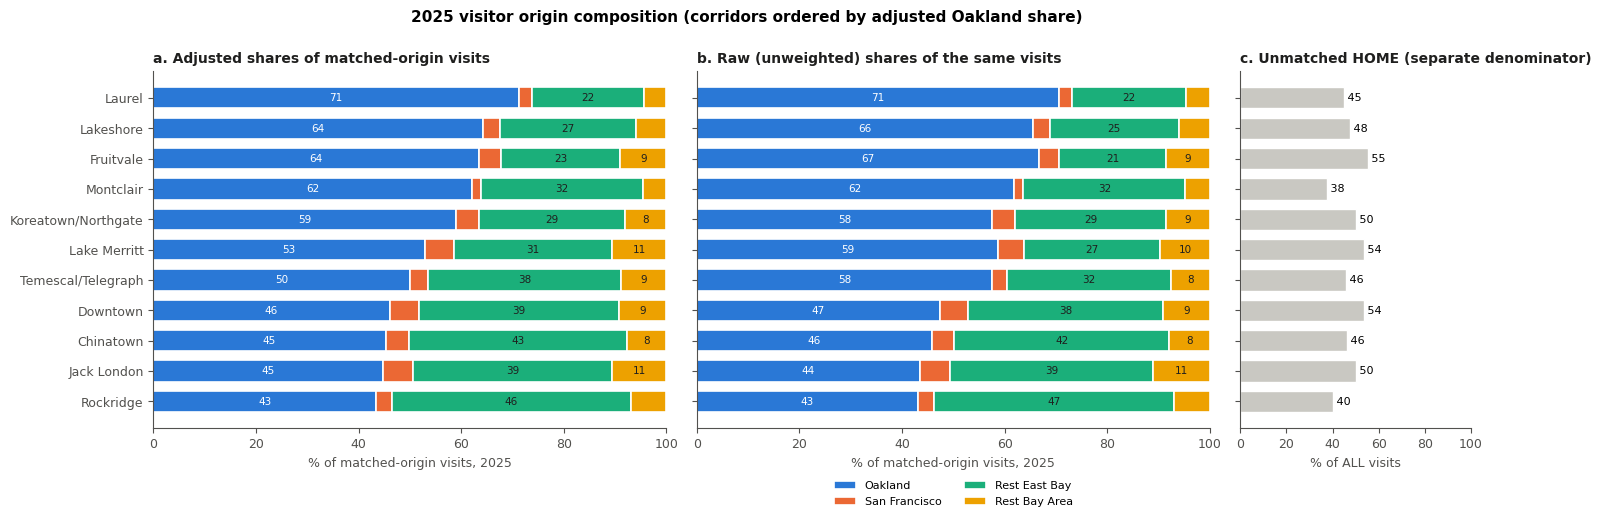

adjusted % of matched                                           raw % of matched                                           adjusted − raw, Oakland (pp) unmatched, % of all visits
home_geography                    Oakland San Francisco Rest East Bay Rest Bay Area          Oakland San Francisco Rest East Bay Rest Bay Area                                                        
corridor_name                                                                                                                                                                                         
Laurel                              71.30          2.50         21.80          4.40            70.60          2.50         22.20          4.70                         0.70                      45.00
Lakeshore                           64.20          3.40         26.50          6.00            65.60          3.20         25.20          6.00                        -1.40                      47.60
Fruitvale                           63.50          4.30         23.20          9.00            66.70          3.90         20.90          8.50                        -3.10                      55.20
Montclair                           62.10          1.80         31.50          4.60            61.80          1.90         31.60          4.80                         0.30                      37.70
Koreatown/Northgate                 59.00          4.50         28.50          8.00            57.60          4.50         29.30          8.60                         1.40                      50.20
Lake Merritt                        52.90          5.60         30.80         10.60            58.70          5.00         26.60          9.60                        -5.80                      53.60
Temescal/Telegraph                  50.00          3.50         37.60          8.80            57.60          2.90         31.90          7.60                        -7.60                      45.70
Downtown                            46.00          5.80         39.00          9.20            47.40          5.40         38.10          9.10                        -1.40                      53.70
Chinatown                           45.30          4.40         42.50          7.70            45.80          4.40         41.80          7.90                        -0.50                      46.50
Jack London                         44.70          5.90         38.70         10.70            43.50          5.90         39.50         11.10                         1.20                      50.10
Rockridge                           43.40          3.10         46.50          7.00            43.10          3.00         46.90          7.00                         0.30                      40.40

Rank agreement of Oakland share, adjusted vs raw (Spearman): 0.964 | max |adjusted − raw| for Oakland share: 7.6 pp


In [24]:
def origin_wide(year, months=range(1, 13), lens='adjusted', period='all'):
    col = {'adjusted': 'normalized_visit_count', 'raw': 'visit_count'}[lens]
    d = origin[(origin.year == year) & origin.month.isin(months) & (origin.time_period == period) & (origin.home_geography != UNMATCHED)]
    w = d.groupby(['corridor_name', 'home_geography'])[col].sum().unstack().reindex(index=CORRIDORS, columns=ORIGIN_ORDER).fillna(0)
    return w

def unmatched_share(year, months=range(1, 13)):
    d = stops[(stops.year == year) & stops.month.isin(months) & (stops.time_period == 'all')].groupby('corridor_name')[['visit_count', 'home_matched_visits']].sum().reindex(CORRIDORS)
    return 1 - d.home_matched_visits / d.visit_count

adj25, raw25 = origin_wide(2025, lens='adjusted'), origin_wide(2025, lens='raw')
sh_adj25, sh_raw25 = 100 * adj25.div(adj25.sum(axis=1), axis=0), 100 * raw25.div(raw25.sum(axis=1), axis=0)
order_o = sh_adj25.Oakland.sort_values(ascending=False).index.tolist()
unm25 = 100 * unmatched_share(2025)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.45]})
y = np.arange(len(order_o))[::-1]
for ax, sh, ttl in [(axes[0], sh_adj25, 'a. Adjusted shares of matched-origin visits'), (axes[1], sh_raw25, 'b. Raw (unweighted) shares of the same visits')]:
    left = np.zeros(len(order_o))
    for cat in ORIGIN_ORDER:
        v = sh.loc[order_o, cat].to_numpy()
        ax.barh(y, v, left=left, color=ORIGIN_COLORS[cat], height=0.7, edgecolor='white', linewidth=1.2, label=cat)
        for yi, l, w in zip(y, left, v):
            if w >= 7: ax.text(l + w / 2, yi, f'{w:.0f}', ha='center', va='center', fontsize=7.5, color='white' if cat in ('Oakland',) else INK)
        left += v
    ax.set_xlim(0, 100); ax.set_xlabel('% of matched-origin visits, 2025'); ax.set_title(ttl, loc='left'); ax.grid(False)
axes[0].set_yticks(y); axes[0].set_yticklabels(order_o)
axes[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=8)
axes[2].barh(y, unm25.loc[order_o], color=ORIGIN_COLORS[UNMATCHED], height=0.7, edgecolor='white')
for yi, v in zip(y, unm25.loc[order_o]): axes[2].text(v, yi, f' {v:.0f}', va='center', fontsize=8)
axes[2].set_xlim(0, 100); axes[2].set_xlabel('% of ALL visits'); axes[2].set_title('c. Unmatched HOME (separate denominator)', loc='left'); axes[2].grid(False)
fig.suptitle('2025 visitor origin composition (corridors ordered by adjusted Oakland share)', fontsize=11, fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

comp = pd.concat({'adjusted % of matched': sh_adj25.loc[order_o], 'raw % of matched': sh_raw25.loc[order_o]}, axis=1)
comp[('adjusted − raw, Oakland (pp)', '')] = sh_adj25.Oakland - sh_raw25.Oakland
comp[('unmatched, % of all visits', '')] = unm25
display(comp.round(1))
print('Rank agreement of Oakland share, adjusted vs raw (Spearman):', round(spearmanr(sh_adj25.Oakland, sh_raw25.Oakland)[0], 3),
      '| max |adjusted − raw| for Oakland share:', round((sh_adj25.Oakland - sh_raw25.Oakland).abs().max(), 1), 'pp')

**Takeaways: 2025 catchments.** Category definitions are verified from the exported geography: Oakland CBGs lie only in Alameda County, San Francisco is exactly county 075, Rest East Bay is Alameda/Contra Costa outside Oakland, and Rest Bay Area is the other six counties.
- **Predominantly Oakland-origin** (adjusted share of matched visits): Laurel 71%, Lakeshore 64%, Fruitvale 64%, Montclair 62% and Koreatown/Northgate 59%; Lake Merritt (53%) and Temescal/Telegraph (50%) are about half.
- **Strongest ties to the rest of the East Bay:** Rockridge (47% Rest East Bay, 43% Oakland), Chinatown (43%), Downtown (39%), Jack London (39%) and Temescal/Telegraph (38%), where Oakland-origin visits are only 43–50% of matched visits.
- **Broadest Bay Area reach** (San Francisco + Rest Bay Area): Jack London (17%), Lake Merritt (16%) and Downtown (15%); Laurel, Montclair, Lakeshore and Rockridge draw 6–10%. San Francisco alone is small everywhere (1.8–5.9%).
- **Weighting matters little to this classification:** adjusted and raw Oakland shares have ρ = 0.96, with the largest gaps in Temescal/Telegraph (adjusted 50.0% vs raw 57.6%), Lake Merritt (−5.8 pp) and Fruitvale (−3.1 pp), where raw matched growth was concentrated in Oakland CBGs. Unmatched visits are 38% (Montclair) to 55% (Fruitvale) of all visits and are shown separately; these are catchments of *matched* devices only.

### 4.1 Stability from 2024 to 2025, and what drives the change in Oakland share
Composition changes are expressed in **percentage points of matched-origin visits**, next to changes in the visit counts behind them. An Oakland share can rise because Oakland-origin visits grow, because visits from elsewhere decline, or both, so the table below separates the two.

,"Oakland share 2024 (adj, %)","Oakland share 2025 (adj, %)","Δ Oakland share, adj (pp)","Δ Oakland share, raw (pp)","Δ Oakland share, adj, Jan–Nov (pp)",Oakland-origin visits Δ% (adj),non-Oakland visits Δ% (adj),driver (adjusted),Oakland-origin visits Δ% (raw),non-Oakland visits Δ% (raw)
corridor_name,,,,,,,,,,
Laurel,69.40,71.30,1.90,1.10,1.80,5.40,-3.70,"Oakland up, elsewhere down",15.50,9.70
Lakeshore,61.40,64.20,2.80,4.80,2.70,1.10,-10.20,"Oakland up, elsewhere down",26.90,3.40
Fruitvale,55.60,63.50,8.00,9.00,7.60,19.10,-14.60,"Oakland up, elsewhere down",50.00,2.10
Montclair,58.10,62.10,4.00,3.80,3.80,14.40,-3.10,"Oakland up, elsewhere down",29.80,10.90
Koreatown/Northgate,54.70,59.00,4.30,3.00,4.10,24.50,4.30,"both up, Oakland faster",38.30,22.60
Lake Merritt,47.10,52.90,5.80,10.30,5.70,25.20,-0.60,"Oakland up, elsewhere down",78.10,17.30
Temescal/Telegraph,45.10,50.00,5.00,12.60,4.90,18.60,-2.80,"Oakland up, elsewhere down",85.70,11.70
Downtown,43.90,46.00,2.10,2.90,1.60,3.80,-4.80,"Oakland up, elsewhere down",22.30,8.70
Chinatown,42.60,45.30,2.60,3.00,2.20,19.90,7.70,"both up, Oakland faster",40.20,24.20


Δ share by origin category, adjusted, 2025 − 2024 (pp):


,Oakland,San Francisco,Rest East Bay,Rest Bay Area
corridor_name,,,,
Laurel,1.90,-0.20,-1.10,-0.60
Lakeshore,2.80,0.00,-1.40,-1.40
Fruitvale,8.00,-0.10,-4.80,-3.00
Montclair,4.00,-0.50,-2.50,-1.00
Koreatown/Northgate,4.30,-0.50,-3.10,-0.70
Lake Merritt,5.80,-0.10,-3.80,-1.90
Temescal/Telegraph,5.00,-0.20,-3.10,-1.60
Downtown,2.10,0.20,-1.30,-1.00
Chinatown,2.60,0.20,-2.20,-0.60


Spearman between change in total adjusted visits and change in Oakland share (n=11): 0.48


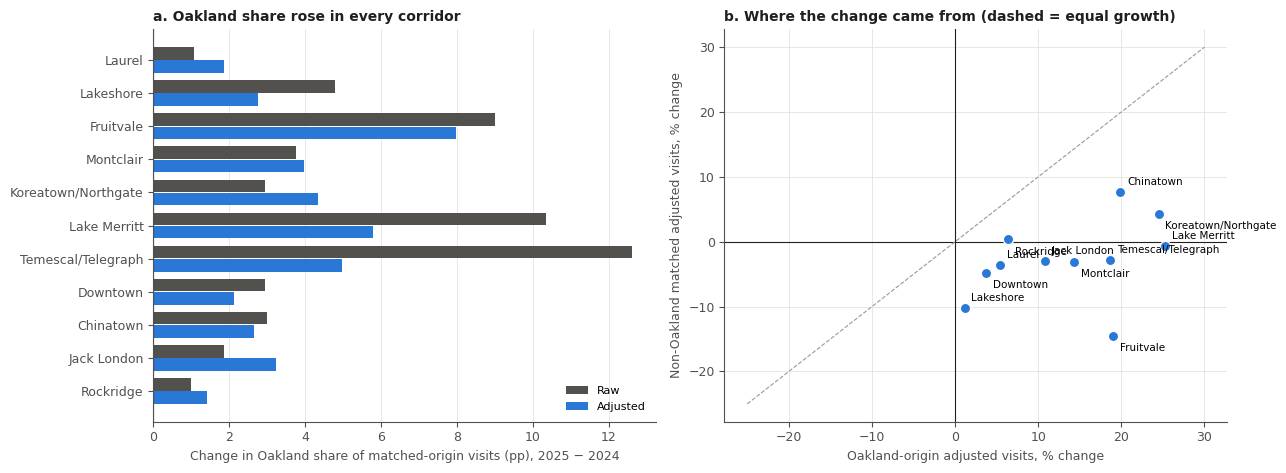

In [25]:
def comp_change(months, lens):
    a24, a25 = origin_wide(2024, months, lens), origin_wide(2025, months, lens)
    s24, s25 = 100 * a24.div(a24.sum(axis=1), axis=0), 100 * a25.div(a25.sum(axis=1), axis=0)
    return a24, a25, s24, s25

a24, a25, s24, s25 = comp_change(range(1, 13), 'adjusted')
r24, r25, rs24, rs25 = comp_change(range(1, 13), 'raw')
_, _, js24, js25 = comp_change(range(1, 12), 'adjusted')
oak_adj_g, non_adj_g = pct_change(a24.Oakland, a25.Oakland), pct_change(a24.drop(columns='Oakland').sum(axis=1), a25.drop(columns='Oakland').sum(axis=1))
oak_raw_g, non_raw_g = pct_change(r24.Oakland, r25.Oakland), pct_change(r24.drop(columns='Oakland').sum(axis=1), r25.drop(columns='Oakland').sum(axis=1))
def driver(go, gn):
    if go > 0 and gn < 0: return 'Oakland up, elsewhere down'
    if go > gn > 0: return 'both up, Oakland faster'
    if gn > go > 0: return 'both up, elsewhere faster'
    if go < 0 and gn < 0: return 'both down'
    return 'Oakland down, elsewhere up'
chg = pd.DataFrame({
    'Oakland share 2024 (adj, %)': s24.Oakland, 'Oakland share 2025 (adj, %)': s25.Oakland, 'Δ Oakland share, adj (pp)': s25.Oakland - s24.Oakland,
    'Δ Oakland share, raw (pp)': rs25.Oakland - rs24.Oakland, 'Δ Oakland share, adj, Jan–Nov (pp)': js25.Oakland - js24.Oakland,
    'Oakland-origin visits Δ% (adj)': oak_adj_g, 'non-Oakland visits Δ% (adj)': non_adj_g, 'driver (adjusted)': [driver(oak_adj_g[c], non_adj_g[c]) for c in CORRIDORS],
    'Oakland-origin visits Δ% (raw)': oak_raw_g, 'non-Oakland visits Δ% (raw)': non_raw_g}).reindex(order_o)
display(chg.round(1))
pp = pd.DataFrame({cat: s25[cat] - s24[cat] for cat in ORIGIN_ORDER}).reindex(order_o)
print('Δ share by origin category, adjusted, 2025 − 2024 (pp):'); display(pp.round(1))
tot_g = pct_change(a24.sum(axis=1), a25.sum(axis=1))
print('Spearman between change in total adjusted visits and change in Oakland share (n=11): %.2f' % spearmanr(tot_g, s25.Oakland - s24.Oakland)[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]; y = np.arange(len(order_o))[::-1]
ax.barh(y + 0.2, chg['Δ Oakland share, raw (pp)'], height=0.38, color=INK_2, label='Raw'); ax.barh(y - 0.2, chg['Δ Oakland share, adj (pp)'], height=0.38, color=C_BLUE, label='Adjusted')
ax.axvline(0, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_o); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel('Change in Oakland share of matched-origin visits (pp), 2025 − 2024'); ax.set_title('a. Oakland share rose in every corridor', loc='left')
ax = axes[1]
ax.scatter(oak_adj_g, non_adj_g, s=55, color=C_BLUE, edgecolor='white', zorder=3)
for k, c in enumerate(sorted(CORRIDORS, key=lambda c: oak_adj_g[c])):       # alternate label offsets to limit overlap
    ax.annotate(c, (oak_adj_g[c], non_adj_g[c]), xytext=(5, 5 if k % 2 == 0 else -11), textcoords='offset points', fontsize=7.5)
ax.axhline(0, color=INK, lw=0.8); ax.axvline(0, color=INK, lw=0.8); lim = [-25, 30]; ax.plot(lim, lim, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel('Oakland-origin adjusted visits, % change'); ax.set_ylabel('Non-Oakland matched adjusted visits, % change'); ax.set_title('b. Where the change came from (dashed = equal growth)', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: change in composition, 2024 → 2025.**
- **Oakland's share rose in every corridor**: +1.4 (Rockridge) to +8.0 points (Fruitvale) adjusted; +1.0 to +12.6 raw. Excluding December changes it by at most 0.5 points.
- **Why it rose depends on the lens.** Under the adjusted lens Oakland-origin visits rose in all 11 corridors (+1% Lakeshore to +25% Lake Merritt), while non-Oakland visits **fell in eight** (−0.6% to −14.6%, largest at Fruitvale, Lakeshore and Downtown) and rose in three (Koreatown/Northgate +4.3%, Chinatown +7.7%, Rockridge +0.4%). So in eight corridors the Oakland share rose because Oakland-origin visits grew *and* visits from elsewhere stagnated or declined; only in Koreatown/Northgate, Chinatown and Rockridge is it "both up, Oakland faster". Under the raw lens, non-Oakland visits rose in every corridor (+2% to +24%), and Oakland grew faster. The robust statement is therefore **Oakland-origin growth outpaced the rest everywhere; whether non-Oakland visits actually shrank depends on the weights.**
- Changes in total activity and Oakland share are only moderately related (ρ = 0.48): the three largest adjusted growers by volume (Koreatown/Northgate, Chinatown, Lake Merritt) saw Oakland shares rise 2.6–5.8 points, while Fruitvale's very large share gain (+8.0) came with only +4% total growth.
- Composition among non-Oakland origins is stable: San Francisco's share moves by ≤ 0.5 points; the Oakland gain is offset by Rest East Bay (−0.6 to −4.8 points) and Rest Bay Area (−0.6 to −3.0 points).

### 4.2 CBG-level detail for contrasting corridors
`corridor_homes` (half-year, CBG level) is used for a small number of contrasting corridors: the most Oakland-oriented, the one with the largest "Rest East Bay" share, and the one with the widest reach beyond the East Bay. CBGs are aggregated to counties from the county code inside each identifier. No municipality is inferred (the exports have only county codes and the four categories), so "Rest East Bay" is Alameda/Contra Costa outside Oakland city limits, and "Oakland" is the CBG-point definition above. To separate Oakland origins from *genuinely nearby* origins, each CBG's straight-line distance to the corridor centroid is recomputed from the exported coordinates, and the recomputation is first checked against the exported distance bands.

In [26]:
def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))

hh = homes_half[(homes_half.time_period == 'all') & homes_half.half_year.isin(['2024H1', '2025H1'])].merge(
    geo_home[['block_group_id', 'home_lat', 'home_lon', 'county']], on='block_group_id', how='left').merge(
    geo_cor[['corridor_name', 'corridor_lat', 'corridor_lon']], on='corridor_name')
hh['distance_km'] = haversine_km(hh.home_lat, hh.home_lon, hh.corridor_lat, hh.corridor_lon)
hh['origin_group'] = np.where(hh.block_group_id == 'UNKNOWN', UNMATCHED, hh.home_geography)
mh = hh[hh.block_group_id != 'UNKNOWN'].copy()
mh['place'] = np.where(mh.home_geography == 'Oakland', 'Oakland (city)', np.where(mh.county == '001', 'Alameda Co., outside Oakland',
              mh.county.map(lambda c: BAY_COUNTIES[c] + ' Co.')))

# reconciliation: recomputed within-5 km share of raw matched visits vs the exported monthly distance bands (same half-year)
def exported_within(halves, bands, col='visit_count'):
    months_in = [int(h[:4]) * 100 + m for h in halves for m in (range(1, 7) if h.endswith('H1') else range(7, 13))]
    d = dist[dist.year_month.isin(months_in) & (dist.time_period == 'all') & (dist.distance_band != UNKNOWN_DISTANCE)]
    g = d.groupby('corridor_name')
    return g.apply(lambda x: x[x.distance_band.isin(bands)][col].sum() / x[col].sum())
mine = mh[mh.half_year == '2025H1'].groupby('corridor_name').apply(lambda x: x[x.distance_km < 5].visit_count.sum() / x.visit_count.sum())
ref = exported_within(['2025H1'], WITHIN_5)
print('Max |recomputed − exported| within-5 km share of matched visits, 2025H1 (pp): %.2f' % (100 * (mine - ref).abs().max()))

pick = {'most Oakland-oriented': sh_adj25.Oakland.idxmax(), 'largest Rest East Bay share': sh_adj25['Rest East Bay'].idxmax(),
        'widest reach beyond East Bay': (sh_adj25['San Francisco'] + sh_adj25['Rest Bay Area']).idxmax()}
print('Selected corridors:', pick)
rows = []
for label, c in pick.items():
    d = mh[(mh.corridor_name == c) & (mh.half_year == '2025H1')]
    for lens, col in [('adjusted', 'normalized_visit_count'), ('raw', 'visit_count')]:
        s = d.groupby('place')[col].sum(); s = 100 * s / s.sum()
        for place, v in s.items(): rows.append({'corridor': f'{c} ({label})', 'lens': lens, 'origin place': place, 'share %': v})
county_tbl = pd.DataFrame(rows).pivot_table(index='origin place', columns=['corridor', 'lens'], values='share %').fillna(0)
county_tbl = county_tbl.loc[county_tbl.xs('adjusted', axis=1, level='lens').max(axis=1).sort_values(ascending=False).index]
display(county_tbl.round(1))

Max |recomputed − exported| within-5 km share of matched visits, 2025H1 (pp): 0.00
Selected corridors: {'most Oakland-oriented': 'Laurel', 'largest Rest East Bay share': 'Rockridge', 'widest reach beyond East Bay': 'Jack London'}


corridor                     Jack London (widest reach beyond East Bay)       Laurel (most Oakland-oriented)       Rockridge (largest Rest East Bay share)      
lens                                                           adjusted   raw                       adjusted   raw                                adjusted   raw
origin place                                                                                                                                                    
Oakland (city)                                                    43.20 42.90                          70.10 70.20                                   42.50 43.00
Alameda Co., outside Oakland                                      24.40 24.50                          15.60 15.40                                   27.80 27.40
Contra Costa Co.                                                  15.40 15.60                           7.10  7.30                                   19.60 19.70
San Francisco Co.                                                  6.00  5.80                           2.60  2.40                                    3.10  2.90
Solano Co.                                                         3.30  3.40                           1.60  1.70                                    2.30  2.30
Santa Clara Co.                                                    3.30  3.20                           1.30  1.40                                    1.80  1.70
San Mateo Co.                                                      2.70  2.70                           1.10  1.10                                    1.80  1.80
Sonoma Co.                                                         0.80  0.80                           0.30  0.30                                    0.40  0.50
Marin Co.                                                          0.60  0.70                           0.20  0.20                                    0.60  0.60
Napa Co.                                                           0.40  0.40                           0.10  0.10                                    0.20  0.20

In [27]:
def nearby_summary(half, col='normalized_visit_count'):
    d = mh[mh.half_year == half]
    out = {}
    for c, g in d.groupby('corridor_name'):
        tot = g[col].sum(); oak = g[g.home_geography == 'Oakland']; non = g[g.home_geography != 'Oakland']
        out[c] = {'Oakland share (%)': 100 * oak[col].sum() / tot,
                  'non-Oakland within 5 km (% of matched)': 100 * non[non.distance_km < 5][col].sum() / tot,
                  'Oakland-origin visits beyond 5 km (% of Oakland)': 100 * oak[oak.distance_km >= 5][col].sum() / oak[col].sum(),
                  'Oakland-origin visits beyond 10 km (% of Oakland)': 100 * oak[oak.distance_km >= 10][col].sum() / oak[col].sum(),
                  'Rest East Bay within 10 km (% of Rest East Bay)': 100 * g[(g.home_geography == 'Rest East Bay') & (g.distance_km < 10)][col].sum() / max(g[g.home_geography == 'Rest East Bay'][col].sum(), 1e-9),
                  'matched CBGs with ≥1 visit': g.block_group_id.nunique()}
    return pd.DataFrame(out).T.reindex(order_o)
nb25 = nearby_summary('2025H1'); nb24 = nearby_summary('2024H1')
display(nb25.round(1).astype({'matched CBGs with ≥1 visit': int}))
print('Change 2024H1 → 2025H1 (pp) in non-Oakland-within-5km share:'); display((nb25['non-Oakland within 5 km (% of matched)'] - nb24['non-Oakland within 5 km (% of matched)']).round(1).to_frame('Δ pp'))

,Oakland share (%),non-Oakland within 5 km (% of matched),Oakland-origin visits beyond 5 km (% of Oakland),Oakland-origin visits beyond 10 km (% of Oakland),Rest East Bay within 10 km (% of Rest East Bay),matched CBGs with ≥1 visit
Laurel,70.10,0.60,16.50,0.00,21.50,1841
Lakeshore,63.80,4.10,24.20,2.60,30.00,2103
Fruitvale,60.70,1.60,17.00,0.00,17.10,3887
Montclair,60.30,6.40,24.80,2.00,34.30,1484
Koreatown/Northgate,56.00,3.10,18.90,6.20,26.20,3133
Lake Merritt,50.90,3.40,19.30,5.80,22.80,4171
Temescal/Telegraph,47.70,7.80,25.80,11.80,34.40,3616
Downtown,45.30,3.80,25.70,7.50,21.80,3907
Chinatown,44.30,6.50,22.40,3.70,26.70,3645
Jack London,43.20,6.10,28.40,7.20,24.70,3733


Change 2024H1 → 2025H1 (pp) in non-Oakland-within-5km share:


,Δ pp
Laurel,-0.10
Lakeshore,0.30
Fruitvale,-0.50
Montclair,0.30
Koreatown/Northgate,-0.20
Lake Merritt,0.10
Temescal/Telegraph,-0.20
Downtown,0.00
Chinatown,-0.40
Jack London,-0.30


**Takeaways: CBG-level detail for three contrasting corridors (H1 2025).**
- **Laurel (most Oakland-oriented)**: 70% Oakland city CBGs, 16% elsewhere in Alameda, 7% Contra Costa, 2.6% San Francisco; its non-Oakland visitors are rarely close (only 0.6% of matched visits come from non-Oakland CBGs within 5 km).
- **Rockridge (largest Rest East Bay share)**: 43% Oakland, 28% Alameda outside Oakland and 20% Contra Costa. **15% of its matched visits come from non-Oakland CBGs within 5 km of the corridor centroid**, against 0.6–8% elsewhere, and 45% of its Rest East Bay visits are within 10 km (17–34% in the other corridors), so its East Bay connection is mostly adjacent neighbourhoods rather than a regional draw. Municipality names are not available in the exports and are not inferred.
- **Jack London (widest reach)**: 43% Oakland, 24% Alameda outside Oakland, 15% Contra Costa, 6% San Francisco and 3% each from Solano and Santa Clara counties. Its Oakland-origin visits are among the most spread (28% from more than 5 km, second only to Rockridge's 33%).
- **"Oakland" is not the same as "near".** Between 17% (Laurel) and 33% (Rockridge) of Oakland-origin visits come from CBGs more than 5 km away, and up to 12% (Temescal/Telegraph) from more than 10 km, while the nearby non-Oakland share is stable (−0.5 to +0.3 points, 2024H1 → 2025H1). Adjusted and raw county shares agree to about a point. The recomputed within-5 km shares equal the exported distance bands exactly (0.00 pp), which also verifies the exported distance logic.

## 5. Distance and local versus regional reach
Distances are **straight-line kilometres from a CBG's internal point to the corridor centroid**. They are not travel distances, not exact homes (HOME is a block group) and, because each corridor has a single centroid, long corridors are measured less precisely. Shares use *known-distance* visits (matched Bay HOME) as the denominator; unknown distance is identical to "no matched Bay HOME" and is shown separately. Bands are 0–2, 2–5, 5–10, 10–25, 25–50, 50–100 and 100+ km, so the summaries below use only the band edges that are exact: within 5 km, within 10 km and beyond 25 km.

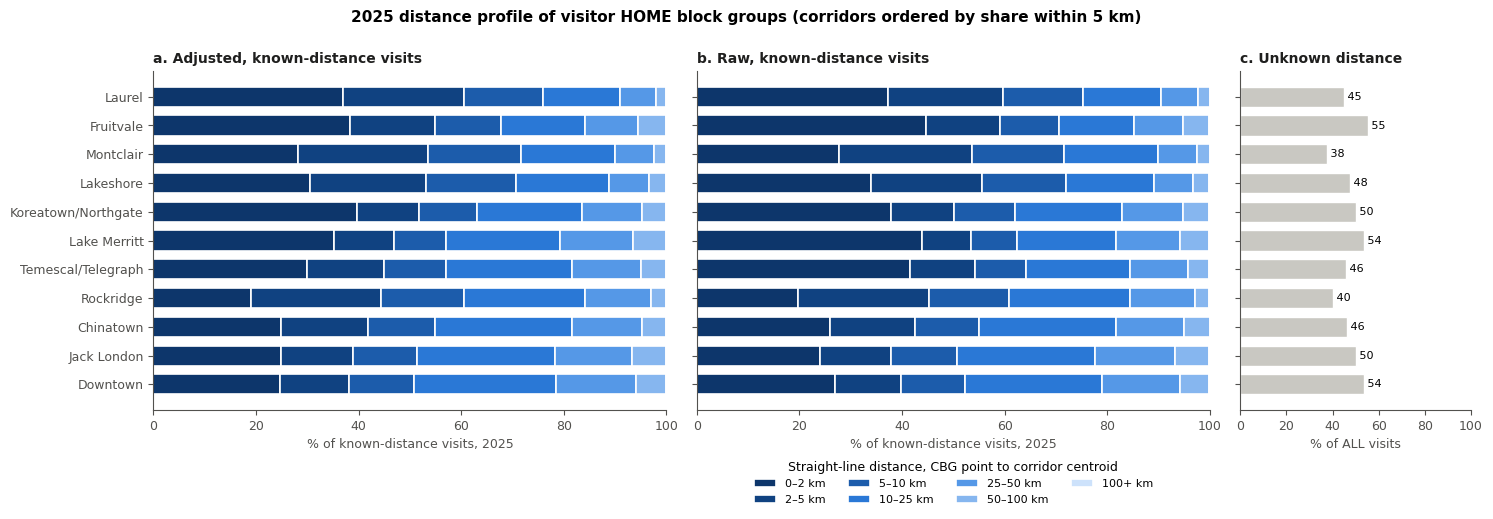

adjusted 2025                           adjusted 2024                              raw 2025                              raw 2024                            \
                      within 5 km within 10 km beyond 25 km   within 5 km within 10 km beyond 25 km within 5 km within 10 km beyond 25 km within 5 km within 10 km beyond 25 km   
corridor_name                                                                                                                                                                     
Laurel                      60.50        76.00         9.10         58.20        74.40        10.00       59.60        75.40         9.60       58.20        74.50        10.10   
Fruitvale                   54.90        67.70        15.90         46.80        59.90        21.50       59.20        70.50        14.80       48.50        61.30        21.20   
Montclair                   53.50        71.70        10.10         49.00        68.40        11.30       53.60        71.60        10.20       48.70        68.30        11.40   
Lakeshore                   53.20        70.60        11.10         50.80        68.00        13.10       55.50        72.00        11.00       50.10        67.40        13.30   
Koreatown/Northgate         51.80        63.00        16.50         47.40        59.00        18.00       50.10        61.90        17.20       47.30        58.90        18.10   
Lake Merritt                46.90        57.10        20.80         40.20        51.20        23.90       53.50        62.30        18.30       41.20        52.10        23.50   
Temescal/Telegraph          45.00        57.00        18.40         40.00        52.90        20.70       54.30        64.20        15.50       39.80        52.70        20.80   
Rockridge                   44.30        60.50        15.90         43.30        59.40        16.10       45.30        60.90        15.60       43.10        59.20        16.10   
Chinatown                   41.90        54.90        18.30         39.60        53.20        19.40       42.50        55.10        18.30       39.70        53.30        19.40   
Jack London                 38.90        51.40        21.80         35.50        48.60        23.90       37.90        50.60        22.40       35.60        48.70        23.80   
Downtown                    38.10        50.80        21.50         35.90        48.70        23.10       39.80        52.30        21.10       36.30        49.10        23.00   

                    Δ adjusted 2025−2024 (pp)                           unknown distance, % of all visits  
                                  within 5 km within 10 km beyond 25 km                              2025  
corridor_name                                                                                              
Laurel                                   2.30         1.50        -0.90                             45.00  
Fruitvale                                8.10         7.90        -5.60                             55.20  
Montclair                                4.50         3.20        -1.20                             37.70  
Lakeshore                                2.40         2.70        -2.00                             47.60  
Koreatown/Northgate                      4.40         4.00        -1.60                             50.20  
Lake Merritt                             6.70         5.90        -3.10                             53.60  
Temescal/Telegraph                       5.00         4.20        -2.30                             45.70  
Rockridge                                1.00         1.20        -0.20                             40.40  
Chinatown                                2.20         1.70        -1.10                             46.50  
Jack London                              3.40         2.80        -2.10                             50.10  
Downtown                                 2.20         2.10        -1.70                             53.70

In [28]:
def dist_wide(year, months=range(1, 13), lens='adjusted'):
    col = {'adjusted': 'normalized_visit_count', 'raw': 'visit_count'}[lens]
    d = dist[(dist.year == year) & dist.month.isin(months) & (dist.time_period == 'all') & (dist.distance_band != UNKNOWN_DISTANCE)]
    return d.groupby(['corridor_name', 'distance_band'])[col].sum().unstack().reindex(index=CORRIDORS, columns=DIST_BANDS).fillna(0)

def dist_summary(year, months=range(1, 13), lens='adjusted'):
    w = dist_wide(year, months, lens); t = w.sum(axis=1)
    return pd.DataFrame({'within 5 km': 100 * w[WITHIN_5].sum(axis=1) / t, 'within 10 km': 100 * w[WITHIN_10].sum(axis=1) / t, 'beyond 25 km': 100 * w[BEYOND_25].sum(axis=1) / t})

ds = {(y, l): dist_summary(y, lens=l) for y in (2024, 2025) for l in ('adjusted', 'raw')}
unk = {y: 100 * unmatched_share(y) for y in (2024, 2025)}
dw25 = dist_wide(2025, lens='adjusted'); dwr25 = dist_wide(2025, lens='raw')
order_d = ds[(2025, 'adjusted')]['within 5 km'].sort_values(ascending=False).index.tolist()
BAND_COLORS = ['#0d366b', '#104281', '#1c5cab', '#2a78d6', '#5598e7', '#86b6ef', '#cde2fb']

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.45]})
y = np.arange(len(order_d))[::-1]
for ax, w, ttl in [(axes[0], dw25, 'a. Adjusted, known-distance visits'), (axes[1], dwr25, 'b. Raw, known-distance visits')]:
    sh = 100 * w.div(w.sum(axis=1), axis=0).loc[order_d]; left = np.zeros(len(order_d))
    for band, col in zip(DIST_BANDS, BAND_COLORS):
        ax.barh(y, sh[band], left=left, color=col, height=0.7, edgecolor='white', linewidth=1.2, label=band[4:])
        left += sh[band].to_numpy()
    ax.set_xlim(0, 100); ax.set_xlabel('% of known-distance visits, 2025'); ax.set_title(ttl, loc='left'); ax.grid(False)
axes[0].set_yticks(y); axes[0].set_yticklabels(order_d)
axes[1].legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=8, title='Straight-line distance, CBG point to corridor centroid')
axes[2].barh(y, unk[2025].loc[order_d], color=ORIGIN_COLORS[UNMATCHED], height=0.7, edgecolor='white')
for yi, v in zip(y, unk[2025].loc[order_d]): axes[2].text(v, yi, f' {v:.0f}', va='center', fontsize=8)
axes[2].set_xlim(0, 100); axes[2].set_xlabel('% of ALL visits'); axes[2].set_title('c. Unknown distance', loc='left'); axes[2].grid(False)
fig.suptitle('2025 distance profile of visitor HOME block groups (corridors ordered by share within 5 km)', fontsize=11, fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

dtab = pd.concat({'adjusted 2025': ds[(2025, 'adjusted')], 'adjusted 2024': ds[(2024, 'adjusted')], 'raw 2025': ds[(2025, 'raw')], 'raw 2024': ds[(2024, 'raw')]}, axis=1).loc[order_d]
dtab[('Δ adjusted 2025−2024 (pp)', 'within 5 km')] = ds[(2025, 'adjusted')]['within 5 km'] - ds[(2024, 'adjusted')]['within 5 km']
dtab[('Δ adjusted 2025−2024 (pp)', 'within 10 km')] = ds[(2025, 'adjusted')]['within 10 km'] - ds[(2024, 'adjusted')]['within 10 km']
dtab[('Δ adjusted 2025−2024 (pp)', 'beyond 25 km')] = ds[(2025, 'adjusted')]['beyond 25 km'] - ds[(2024, 'adjusted')]['beyond 25 km']
dtab[('unknown distance, % of all visits', '2025')] = unk[2025]
display(dtab.round(1))

,"Δ within 5 km, adj (pp)","Δ within 5 km, raw (pp)","Δ within 5 km, adj, Jan–Nov (pp)","Δ beyond 25 km, adj (pp)","Δ Oakland share, adj (pp)"
corridor_name,,,,,
Laurel,2.30,1.50,2.40,-0.90,1.90
Fruitvale,8.10,10.70,7.80,-5.60,8.00
Montclair,4.50,4.90,4.40,-1.20,4.00
Lakeshore,2.40,5.50,2.10,-2.00,2.80
Koreatown/Northgate,4.40,2.90,4.30,-1.60,4.30
Lake Merritt,6.70,12.30,6.70,-3.10,5.80
Temescal/Telegraph,5.00,14.50,4.90,-2.30,5.00
Rockridge,1.00,2.10,0.90,-0.20,1.40
Chinatown,2.20,2.90,1.90,-1.10,2.60


Spearman: Oakland share vs within-5 km share, 2025 adjusted (n=11): 0.89
Spearman: Δ Oakland share vs Δ within-5 km share: 0.96


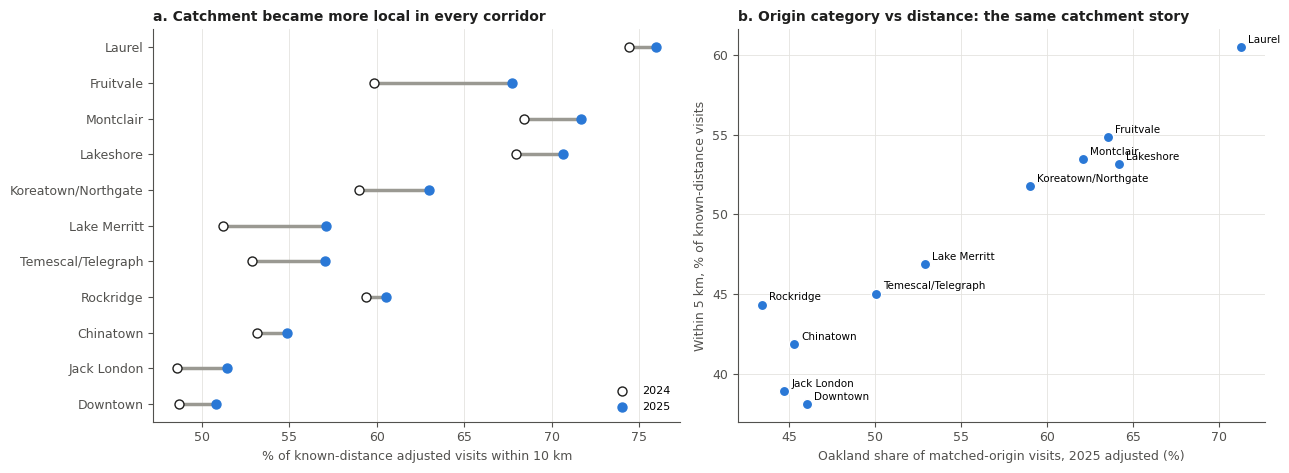

In [29]:
_, _, _, _ = None, None, None, None
js = dist_summary(2024, range(1, 12)), dist_summary(2025, range(1, 12))
chg_d = pd.DataFrame({'Δ within 5 km, adj (pp)': ds[(2025, 'adjusted')]['within 5 km'] - ds[(2024, 'adjusted')]['within 5 km'],
                      'Δ within 5 km, raw (pp)': ds[(2025, 'raw')]['within 5 km'] - ds[(2024, 'raw')]['within 5 km'],
                      'Δ within 5 km, adj, Jan–Nov (pp)': js[1]['within 5 km'] - js[0]['within 5 km'],
                      'Δ beyond 25 km, adj (pp)': ds[(2025, 'adjusted')]['beyond 25 km'] - ds[(2024, 'adjusted')]['beyond 25 km'],
                      'Δ Oakland share, adj (pp)': chg['Δ Oakland share, adj (pp)']}).reindex(order_d)
display(chg_d.round(1))
print('Spearman: Oakland share vs within-5 km share, 2025 adjusted (n=11): %.2f' % spearmanr(sh_adj25.Oakland, ds[(2025, 'adjusted')]['within 5 km'])[0])
print('Spearman: Δ Oakland share vs Δ within-5 km share: %.2f' % spearmanr(chg_d['Δ Oakland share, adj (pp)'], chg_d['Δ within 5 km, adj (pp)'])[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]; y = np.arange(len(order_d))[::-1]
a, b = ds[(2024, 'adjusted')]['within 10 km'].loc[order_d], ds[(2025, 'adjusted')]['within 10 km'].loc[order_d]
ax.hlines(y, a, b, color=C_GRAY, lw=2.5, zorder=1); ax.scatter(a, y, s=42, facecolor='white', edgecolor=INK, zorder=3, label='2024'); ax.scatter(b, y, s=42, color=C_BLUE, zorder=3, label='2025')
ax.set_yticks(y); ax.set_yticklabels(order_d); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel('% of known-distance adjusted visits within 10 km'); ax.set_title('a. Catchment became more local in every corridor', loc='left')
ax = axes[1]
ax.scatter(sh_adj25.Oakland, ds[(2025, 'adjusted')]['within 5 km'], s=55, color=C_BLUE, edgecolor='white', zorder=3)
for c in CORRIDORS: ax.annotate(c, (sh_adj25.Oakland[c], ds[(2025, 'adjusted')]['within 5 km'][c]), xytext=(5, 3), textcoords='offset points', fontsize=7.5)
ax.set_xlabel('Oakland share of matched-origin visits, 2025 adjusted (%)'); ax.set_ylabel('Within 5 km, % of known-distance visits'); ax.set_title('b. Origin category vs distance: the same catchment story', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: distance and reach (adjusted, known-distance visits, 2025).**
- **Most local:** Laurel (61% within 5 km, 76% within 10 km, 9% beyond 25 km), then Fruitvale, Montclair, Lakeshore and Koreatown/Northgate (52–55% within 5 km). **Most regional:** Downtown (38% within 5 km, 51% within 10 km), Jack London (39%, 51%), Chinatown (42%, 55%); beyond-25 km shares are highest in Jack London (22%), Downtown (21–22%) and Lake Merritt (21%). Unknown distance is 38–55% of all visits and is shown separately: it is the unmatched population, not a distance band.
- **Catchments became more local in every corridor.** Within-5 km share rose in all 11 (+1.0 Rockridge to +8.1 Fruitvale; Lake Merritt +6.7, Temescal/Telegraph +5.0, Koreatown/Northgate +4.4) and the beyond-25 km share fell in all 11 (−0.2 to −5.6 points). The direction is identical under the raw lens and excluding December (11 of 11 under all three).
- **This is the origin-category finding seen another way, not new evidence.** Oakland share and within-5 km share are strongly related across corridors (ρ = 0.89) and their changes are almost the same (ρ = 0.96). Distance adds one distinction the categories hide: **Rockridge** is both East-Bay-oriented (47% Rest East Bay) and local (44% within 5 km), because its non-Oakland visitors live next door, whereas **Chinatown/Downtown/Jack London** combine a large East Bay share with a genuinely wide reach.
- Bands are coarse and distances are to a single centroid, so differences of a point or two are not meaningful; the cross-corridor ordering and the all-corridor direction of change are.

### 5.1 Did catchments change during the LIMA recovery? (origins and distance, 2019 → 2022)
The same origin and distance summaries are available for the LIMA years, within one provider. The **raw** matched lens is used because LIMA's adjusted weights are largely a Bay-wide fallback (section 7.3); the adjusted lens is shown for the share change as a check. The question is whether corridors that recovered slowly lost *Oakland-origin* or *non-Oakland* visits.

,Oakland share 2019 (%),Oakland share 2022 (%),Δ pp (raw),Δ pp (adjusted),Oakland-origin visits 2022 ÷ 2019,non-Oakland matched visits 2022 ÷ 2019,"Δ within 5 km (pp, raw)",all-visitor recovery 2022 ÷ 2019 (raw)
corridor_name,,,,,,,,
Lake Merritt,31.58,40.56,8.99,8.83,0.84,0.57,6.98,0.68
Downtown,30.64,37.12,6.48,5.53,0.88,0.66,5.32,0.73
Chinatown,35.86,40.15,4.29,3.55,0.84,0.70,3.63,0.76
Montclair,65.49,63.77,-1.71,-0.32,0.78,0.84,-6.67,0.81
Koreatown/Northgate,40.54,46.22,5.68,5.56,0.97,0.77,4.49,0.88
Rockridge,42.64,40.68,-1.96,-0.51,0.83,0.90,1.21,0.88
Jack London,32.92,36.49,3.57,3.48,0.99,0.85,2.64,0.92
Lakeshore,66.28,63.93,-2.36,-2.76,0.92,1.03,-1.74,0.98
Temescal/Telegraph,38.97,37.63,-1.34,-0.47,0.97,1.02,-0.59,1.02


Spearman: Oakland share 2019 vs 2022÷2019 recovery: 0.75; Δ Oakland share vs recovery: -0.57 (n = 11)


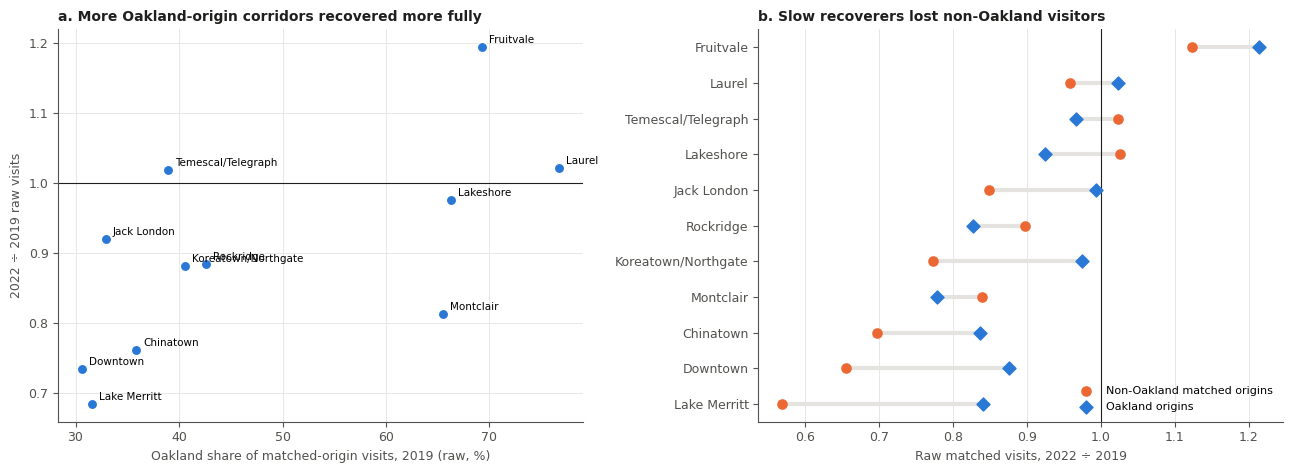

In [30]:
lo = {y: origin_wide(y, lens='raw') for y in (2019, 2022)}
lo_adj = {y: origin_wide(y, lens='adjusted') for y in (2019, 2022)}
oak_share = {y: 100 * lo[y].Oakland / lo[y].sum(axis=1) for y in lo}
oak_share_adj = {y: 100 * lo_adj[y].Oakland / lo_adj[y].sum(axis=1) for y in lo_adj}
lima_origin = pd.DataFrame({
    'Oakland share 2019 (%)': oak_share[2019], 'Oakland share 2022 (%)': oak_share[2022], 'Δ pp (raw)': oak_share[2022] - oak_share[2019], 'Δ pp (adjusted)': oak_share_adj[2022] - oak_share_adj[2019],
    'Oakland-origin visits 2022 ÷ 2019': lo[2022].Oakland / lo[2019].Oakland,
    'non-Oakland matched visits 2022 ÷ 2019': lo[2022].drop(columns='Oakland').sum(axis=1) / lo[2019].drop(columns='Oakland').sum(axis=1),
    'Δ within 5 km (pp, raw)': dist_summary(2022, lens='raw')['within 5 km'] - dist_summary(2019, lens='raw')['within 5 km'],
    'all-visitor recovery 2022 ÷ 2019 (raw)': ann_raw[2022]}).reindex(ann_raw[2022].sort_values().index)
display(lima_origin.round(2))
print('Spearman: Oakland share 2019 vs 2022÷2019 recovery: %.2f; Δ Oakland share vs recovery: %.2f (n = 11)' % (
    spearmanr(lima_origin['Oakland share 2019 (%)'], lima_origin['all-visitor recovery 2022 ÷ 2019 (raw)'])[0],
    spearmanr(lima_origin['Δ pp (raw)'], lima_origin['all-visitor recovery 2022 ÷ 2019 (raw)'])[0]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.scatter(lima_origin['Oakland share 2019 (%)'], lima_origin['all-visitor recovery 2022 ÷ 2019 (raw)'], s=55, color=C_BLUE, edgecolor='white', zorder=3)
for c in lima_origin.index: ax.annotate(c, (lima_origin.loc[c, 'Oakland share 2019 (%)'], lima_origin.loc[c, 'all-visitor recovery 2022 ÷ 2019 (raw)']), xytext=(5, 3), textcoords='offset points', fontsize=7.5)
ax.axhline(1, color=INK, lw=0.8); ax.set_xlabel('Oakland share of matched-origin visits, 2019 (raw, %)'); ax.set_ylabel('2022 ÷ 2019 raw visits'); ax.set_title('a. More Oakland-origin corridors recovered more fully', loc='left')
ax = axes[1]; y = np.arange(len(lima_origin))
ax.hlines(y, lima_origin['non-Oakland matched visits 2022 ÷ 2019'], lima_origin['Oakland-origin visits 2022 ÷ 2019'], color=GRID, lw=3, zorder=1)
ax.scatter(lima_origin['non-Oakland matched visits 2022 ÷ 2019'], y, s=44, color=C_ORANGE, zorder=3, label='Non-Oakland matched origins')
ax.scatter(lima_origin['Oakland-origin visits 2022 ÷ 2019'], y, s=44, color=C_BLUE, marker='D', zorder=3, label='Oakland origins')
ax.axvline(1, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(lima_origin.index); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel('Raw matched visits, 2022 ÷ 2019'); ax.set_title('b. Slow recoverers lost non-Oakland visitors', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: catchments during the LIMA recovery.**
- **The corridors that recovered slowly lost their non-Oakland visitors.** In Lake Merritt, Downtown and Chinatown (the three slowest, with only 31–36% Oakland-origin visits in 2019) Oakland-origin matched visits came back to 84–88% of their 2019 level, but non-Oakland matched visits only to 57%, 66% and 70%. Their Oakland share therefore rose by 9.0, 6.5 and 4.3 points (raw; 8.8, 5.5, 3.6 adjusted), and the share within 5 km by 7.0, 5.3 and 3.6 points. Koreatown/Northgate (+5.7) and Jack London (+3.6) show the same, milder, pattern.
- **Corridors that were already Oakland-oriented recovered most fully.** Oakland share in 2019 is positively related to the 2022 ÷ 2019 ratio (ρ = 0.75): Fruitvale (69%, ratio 1.19), Laurel (77%, 1.02) and Lakeshore (66%, 0.98) against Lake Merritt (32%, 0.68) and Downtown (31%, 0.73). Montclair is the exception: 65% Oakland in 2019, recovery 0.81, with both Oakland (0.78) and non-Oakland (0.84) visits below 2019.
- Because LIMA is a single provider, this is a real *within-panel* change in catchment and not a provider artefact (the raw lens is used because LIMA adjusted weights are largely a Bay-wide fallback; adjusted shares tell the same story). It is **the strongest catchment–trajectory link in the data**, and it concerns origins of *matched* devices only.

## 6. Timing, seasonality and repeat visitation
**Periods overlap and cover different hours.** `weekdays` and `weekends` split all visits exactly (they sum to `all`). `nine-five` is weekdays 09:00–16:59 (8 hours, a subset of weekdays) and `evening` is every day 17:00–22:59 (6 hours; a device-day is counted if *any* stop starts in the window). A device-day can belong to several windows, so these shares are not additive and one window is not a complement of another. Because weekdays outnumber weekend days about 5 to 2, **weekday and weekend activity is compared as visits per available calendar day**, not as raw totals.

,weekday visits per weekday,weekend visits per weekend day,weekend ÷ weekday per-day ratio,09–17 share of weekday visits (%),evening share of all visits (%),evening visits per window-hour ÷ 09–17 per window-hour
corridor_name,,,,,,
Rockridge,200.79,210.12,1.05,55.82,35.05,0.85
Jack London,620.88,630.37,1.02,49.31,33.77,0.92
Lakeshore,157.60,159.78,1.01,46.61,37.67,1.08
Temescal/Telegraph,802.40,806.70,1.01,46.86,34.83,0.99
Lake Merritt,"1,493.82","1,481.27",0.99,42.16,37.36,1.18
Montclair,85.26,84.43,0.99,60.80,26.23,0.57
Fruitvale,"1,714.10","1,696.63",0.99,37.31,40.15,1.43
Koreatown/Northgate,467.29,460.62,0.99,47.00,35.83,1.01
Downtown,981.70,964.59,0.98,48.89,30.20,0.82


Change 2024 → 2025:


,Δ weekday visits per weekday,Δ weekend visits per weekend day,Δ weekend ÷ weekday per-day ratio,Δ 09–17 share of weekday visits (%),Δ evening share of all visits (%),Δ evening visits per window-hour ÷ 09–17 per window-hour
corridor_name,,,,,,
Rockridge,29.56,26.30,-0.03,1.33,-1.12,-0.06
Jack London,91.48,52.37,-0.08,1.19,0.06,-0.04
Lakeshore,24.24,20.54,-0.03,-2.05,3.18,0.12
Temescal/Telegraph,227.45,238.77,0.02,-2.47,1.57,0.10
Lake Merritt,465.31,475.94,0.01,-4.14,6.50,0.30
Montclair,16.30,13.25,-0.04,-0.98,0.28,0.01
Fruitvale,385.16,351.18,-0.02,0.24,3.32,0.10
Koreatown/Northgate,126.87,116.85,-0.02,1.77,2.21,0.02
Downtown,131.58,108.50,-0.02,-0.82,2.79,0.08


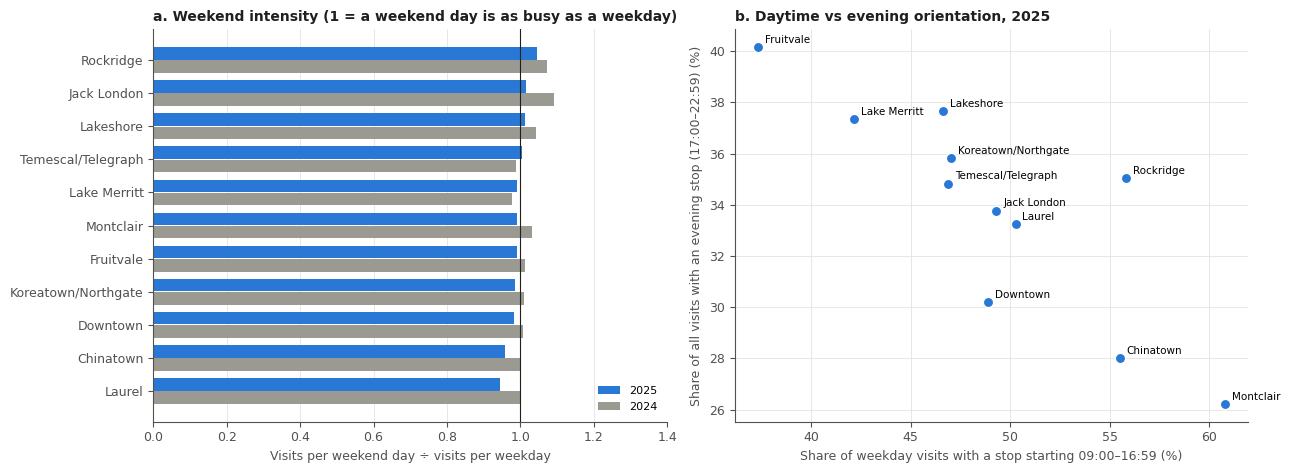

In [31]:
cal = pd.DataFrame({'date': pd.date_range('2019-01-01', '2025-12-31')})
cal['year_month'] = cal.date.dt.year * 100 + cal.date.dt.month
cal['weekday'] = cal.date.dt.dayofweek < 5
cal = cal.groupby('year_month').agg(days=('date', 'size'), weekdays=('weekday', 'sum')).assign(weekend_days=lambda d: d.days - d.weekdays)

def timing_table(year):
    d = stops[stops.year == year].merge(cal, left_on='year_month', right_index=True)
    g = d.pivot_table(index='corridor_name', columns='time_period', values='visit_count', aggfunc='sum')
    days = cal.loc[stops[stops.year == year].year_month.unique()].sum()
    out = pd.DataFrame({'weekday visits per weekday': g['weekdays'] / days.weekdays, 'weekend visits per weekend day': g['weekends'] / days.weekend_days})
    out['weekend ÷ weekday per-day ratio'] = out.iloc[:, 1] / out.iloc[:, 0]
    out['09–17 share of weekday visits (%)'] = 100 * g['nine-five'] / g['weekdays']
    out['evening share of all visits (%)'] = 100 * g['evening'] / g['all']
    out['evening visits per window-hour ÷ 09–17 per window-hour'] = (g['evening'] / (days.days * PERIOD_HOURS['evening'])) / (g['nine-five'] / (days.weekdays * PERIOD_HOURS['nine-five']))
    return out.reindex(CORRIDORS)
tm25, tm24 = timing_table(2025), timing_table(2024)
order_t = tm25['weekend ÷ weekday per-day ratio'].sort_values(ascending=False).index.tolist()
tt = pd.concat({'2025': tm25, '2024': tm24}, axis=1).loc[order_t]
display(tm25.loc[order_t].round(2))
print('Change 2024 → 2025:'); display((tm25 - tm24).loc[order_t].round(2).rename(columns=lambda c: 'Δ ' + c))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]; y = np.arange(len(order_t))[::-1]
ax.barh(y + 0.2, tm25.loc[order_t, 'weekend ÷ weekday per-day ratio'], height=0.38, color=C_BLUE, label='2025')
ax.barh(y - 0.2, tm24.loc[order_t, 'weekend ÷ weekday per-day ratio'], height=0.38, color=C_GRAY, label='2024')
ax.axvline(1, color=INK, lw=0.8); ax.set_xlim(0, 1.4); ax.set_yticks(y); ax.set_yticklabels(order_t); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel('Visits per weekend day ÷ visits per weekday'); ax.set_title('a. Weekend intensity (1 = a weekend day is as busy as a weekday)', loc='left')
ax = axes[1]
ax.scatter(tm25['09–17 share of weekday visits (%)'], tm25['evening share of all visits (%)'], s=55, color=C_BLUE, edgecolor='white', zorder=3)
for c in CORRIDORS: ax.annotate(c, (tm25.loc[c, '09–17 share of weekday visits (%)'], tm25.loc[c, 'evening share of all visits (%)']), xytext=(5, 3), textcoords='offset points', fontsize=7.5)
ax.set_xlabel('Share of weekday visits with a stop starting 09:00–16:59 (%)'); ax.set_ylabel('Share of all visits with an evening stop (17:00–22:59) (%)')
ax.set_title('b. Daytime vs evening orientation, 2025', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: timing.**
- **Weekend days are as busy as weekdays in every corridor** (weekend ÷ weekday visits per day 0.94–1.05): Rockridge 1.05, Jack London 1.02, Lake Merritt and Fruitvale 0.99, Downtown 0.98, Chinatown 0.96, Laurel 0.94. No corridor shows the weekday-dominated pattern one might expect of an office district.
- **Daytime vs evening differs more:** Montclair (61% of weekday visits have a stop starting 09:00–16:59), Rockridge (56%) and Chinatown (56%) are daytime-oriented; Fruitvale (37%) and Lake Merritt (42%) lean evening. Evening visits (17:00–22:59) are 40% of all Fruitvale visits and 37–38% in Lake Merritt and Lakeshore, against 26% in Montclair and 28% in Chinatown. Per window-hour, evening intensity is 1.43× the weekday daytime window in Fruitvale (1.18× Lake Merritt) but 0.57× in Montclair (0.66× Chinatown). The windows overlap and cover different hours (8 vs 6), so shares are not additive.
- **2024 → 2025:** evening share rose in seven corridors (Lake Merritt +6.5 points, Fruitvale +3.3, Lakeshore +3.2, Chinatown +3.0, Downtown +2.8, Koreatown/Northgate +2.2, Temescal/Telegraph +1.6) and weekend intensity barely moved (change ≤ 0.08). Timing does not line up with the PAPA trajectories (growers such as Lake Merritt, Chinatown and Koreatown/Northgate shifted toward evenings, but so did the flat Downtown), so within PAPA it is a descriptive difference between corridors rather than an explanation; section 6.3 shows that it *does* matter for the LIMA recovery.

### 6.1 Seasonality within provider segments
Monthly visits per calendar day (sum of the 11 corridors) are indexed to each year's own mean, so only within-year shape is shown. The dotted line is the **Bay-wide HOME sample** indexed the same way: where a visit peak coincides with a sample peak, it may reflect the panel rather than behaviour. 2020–2021 are omitted (pandemic disruption inside LIMA), SIERRA is too small, and PAPA has only two full years, so these are *comparisons of years*, not an established seasonal cycle.

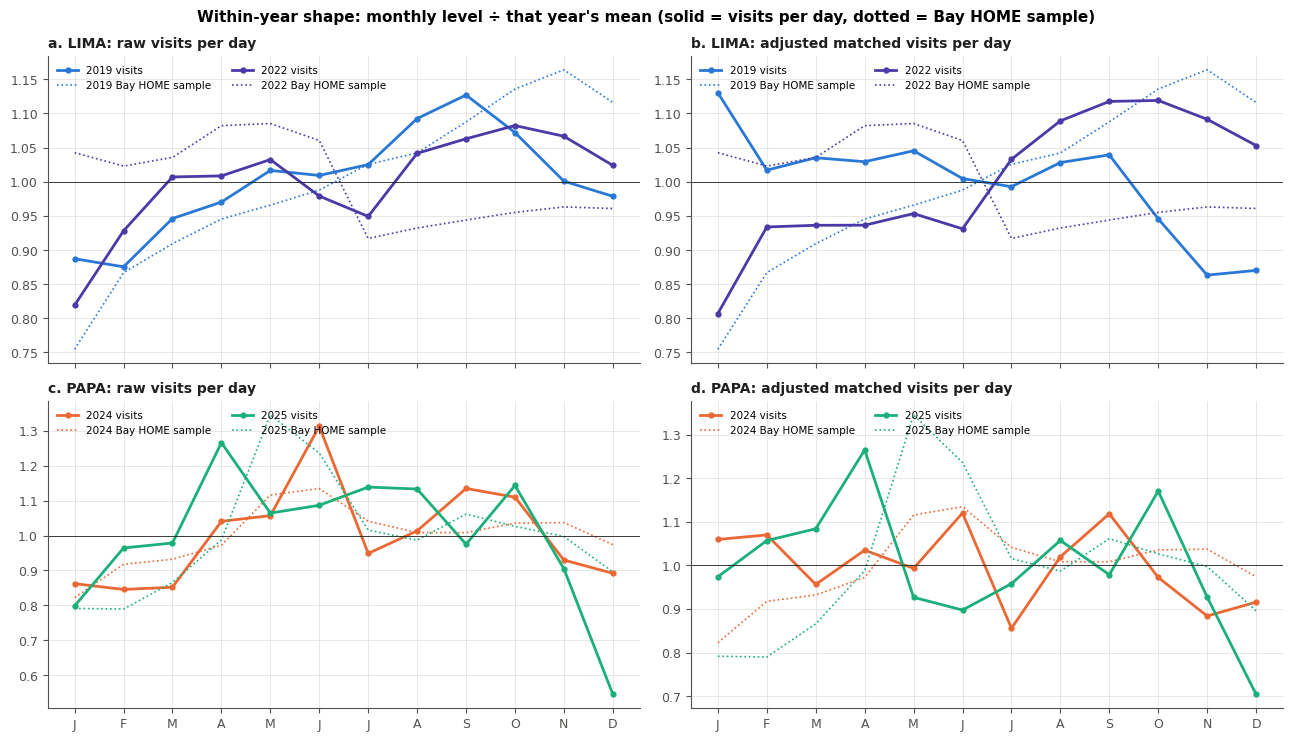

,provider,"peak month, raw visits/day","peak month, adjusted/day","peak month, Bay HOME sample","corr(raw/day, Bay sample)","corr(adjusted/day, Bay sample)","peak ÷ trough, raw/day","peak ÷ trough, adjusted/day"
year,,,,,,,,
2019,LIMA,9,1,11,0.73,-0.81,1.29,1.31
2022,LIMA,10,10,5,-0.33,-0.79,1.32,1.39
2024,PAPA,6,6,6,0.74,-0.08,1.55,1.31
2025,PAPA,4,4,5,0.41,-0.15,2.32,1.80


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
raw visits,19.80,42.50,48.60,57.40,30.30,7.10,55.30,44.70,11.20,33.30,25.90,-20.90
adjusted,-2.00,1.70,20.90,30.30,-0.50,-14.60,19.40,10.50,-6.70,28.30,11.80,-18.00
Bay HOME sample,19.20,6.60,15.10,25.90,49.40,34.90,20.80,21.20,30.40,22.80,19.10,13.90
visits per device,-2.60,3.10,5.50,18.00,13.60,3.10,11.70,9.40,6.30,11.10,9.90,7.60


Across the 12 months, correlation of YoY change in raw visits with YoY change in Bay HOME sample: -0.09; adjusted vs Bay sample: -0.16; raw vs visits-per-device: 0.40


In [32]:
sea = city.merge(cal, left_on='year_month', right_index=True)
sea['raw_per_day'], sea['adj_per_day'] = sea.visits / sea.days, sea.adjusted / sea.days
sea['month'] = sea.year_month % 100
panels = [('LIMA', [2019, 2022], 'raw_per_day', 'a. LIMA: raw visits per day'), ('LIMA', [2019, 2022], 'adj_per_day', 'b. LIMA: adjusted matched visits per day'),
          ('PAPA', [2024, 2025], 'raw_per_day', 'c. PAPA: raw visits per day'), ('PAPA', [2024, 2025], 'adj_per_day', 'd. PAPA: adjusted matched visits per day')]
YEAR_COLOR = {2019: C_BLUE, 2022: C_VIOLET, 2024: C_ORANGE, 2025: C_AQUA}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
for ax, (prov, years, col, ttl) in zip(axes.flat, panels):
    for yr in years:
        g = sea[sea.year == yr].sort_values('month')
        ax.plot(g.month, g[col] / g[col].mean(), color=YEAR_COLOR[yr], lw=2, marker='o', ms=3.5, label=f'{yr} visits')
        ax.plot(g.month, g.bay_home_sample / g.bay_home_sample.mean(), color=YEAR_COLOR[yr], lw=1.2, ls=':', label=f'{yr} Bay HOME sample')
    ax.axhline(1, color=INK, lw=0.6); ax.set_title(ttl, loc='left'); ax.set_xticks(range(1, 13)); ax.set_xticklabels(list('JFMAMJJASOND')); ax.legend(fontsize=7.5, ncol=2, loc='upper left')
fig.suptitle('Within-year shape: monthly level ÷ that year\'s mean (solid = visits per day, dotted = Bay HOME sample)', fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()

rows = []
for yr in [2019, 2022, 2024, 2025]:
    g = sea[sea.year == yr]
    rows.append({'year': yr, 'provider': g.provider_id.iloc[0], 'peak month, raw visits/day': int(g.loc[g.raw_per_day.idxmax(), 'month']), 'peak month, adjusted/day': int(g.loc[g.adj_per_day.idxmax(), 'month']),
                 'peak month, Bay HOME sample': int(g.loc[g.bay_home_sample.idxmax(), 'month']),
                 'corr(raw/day, Bay sample)': np.corrcoef(g.raw_per_day, g.bay_home_sample)[0, 1], 'corr(adjusted/day, Bay sample)': np.corrcoef(g.adj_per_day, g.bay_home_sample)[0, 1],
                 'peak ÷ trough, raw/day': g.raw_per_day.max() / g.raw_per_day.min(), 'peak ÷ trough, adjusted/day': g.adj_per_day.max() / g.adj_per_day.min()})
display(pd.DataFrame(rows).set_index('year').round(2))
p24 = sea[sea.year == 2024].set_index('month'); p25 = sea[sea.year == 2025].set_index('month')
yoy_m = pd.DataFrame({'raw visits': pct_change(p24.visits, p25.visits), 'adjusted': pct_change(p24.adjusted, p25.adjusted), 'Bay HOME sample': pct_change(p24.bay_home_sample, p25.bay_home_sample),
                      'visits per device': pct_change(p24.visits_per_device, p25.visits_per_device)})
display(yoy_m.round(1).T.rename(columns=dict(zip(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']))))
print('Across the 12 months, correlation of YoY change in raw visits with YoY change in Bay HOME sample: %.2f; adjusted vs Bay sample: %.2f; raw vs visits-per-device: %.2f' %
      (yoy_m['raw visits'].corr(yoy_m['Bay HOME sample']), yoy_m['adjusted'].corr(yoy_m['Bay HOME sample']), yoy_m['raw visits'].corr(yoy_m['visits per device'])))

**Takeaways: seasonality.** The shapes are not stable enough to call seasonal. Raw visits per day peak in different months each year (Sep 2019, Oct 2022, **Jun 2024, Apr 2025**), and the raw peak-to-trough range is 1.3–1.6× in 2019, 2022 and 2024 but **2.3× in 2025**, driven by the April–August 2025 rise and the December 2025 fall. Adjusted visits show a smaller range (1.3–1.4×; 1.8× in 2025). The Bay HOME sample is an imperfect guide: the 2024 raw peak coincides with the sample peak (both June; r = +0.74) but the adjusted series is uncorrelated with it (−0.08), and in 2025 the sample peaks in May (4.5 M) while visits peak in April. Month by month, 2025 year-over-year change in raw visits is unrelated to year-over-year change in the Bay sample (r = −0.09), whereas it is moderately related to the change in visits per device (r = 0.40; +18% in April). A one-year peak is not seasonality; **only 2019 and 2024 are clean candidate years (2020–2022 are pandemic recovery, 2025 has the panel step), and they do not share a pattern.**

### 6.2 Repeat visitation
A *repeat device* is one with **two or more visit dates in the corridor within a half-year** (device-days, not stops); *multi-month devices* are active in two or more calendar months. Both are unweighted, apply to **one provider's half-year device IDs only** and are not comparable across the ID reset at each half-year boundary. They describe **recorded return visits**, not customer loyalty or business retention. The halves are compared like for like (H1 2024 vs H1 2025 first; H2 is affected by weak December 2025). Because visits per device rose in many 2025 months (section 7), a corridor's change is read relative to the 11-corridor median.

,repeat share H1 2024 (%),repeat share H1 2025 (%),Δ pp (H1),Δ pp (H2),multi-month devices H1 2025 (%),Δ pp multi-month (H1),visits per device H1 2024,visits per device H1 2025,Δ pp (H1) relative to median
corridor_name,,,,,,,,,
Fruitvale,24.70,30.71,6.01,-0.96,13.80,5.17,1.55,1.77,4.23
Lake Merritt,24.90,27.47,2.57,3.96,11.12,1.03,1.60,1.75,0.78
Downtown,24.85,26.72,1.87,1.92,9.59,0.20,1.59,1.67,0.08
Temescal/Telegraph,22.21,26.15,3.94,4.71,11.96,2.19,1.55,1.77,2.16
Chinatown,24.33,25.76,1.43,1.01,9.73,-0.69,1.68,1.73,-0.36
Jack London,22.39,23.76,1.37,-0.08,8.82,-0.55,1.56,1.62,-0.41
Koreatown/Northgate,22.30,23.57,1.27,1.98,8.93,-0.34,1.54,1.59,-0.51
Laurel,20.82,22.57,1.75,0.94,8.95,0.84,1.46,1.53,-0.04
Montclair,19.88,21.89,2.01,2.80,10.10,0.82,1.49,1.56,0.23


,repeat share H1 2025,"Oakland share (H1 2025, adj)","within 5 km (H1 2025, adj)",raw visits / month 2025
repeat share H1 2025,1.00,-0.12,-0.34,0.95


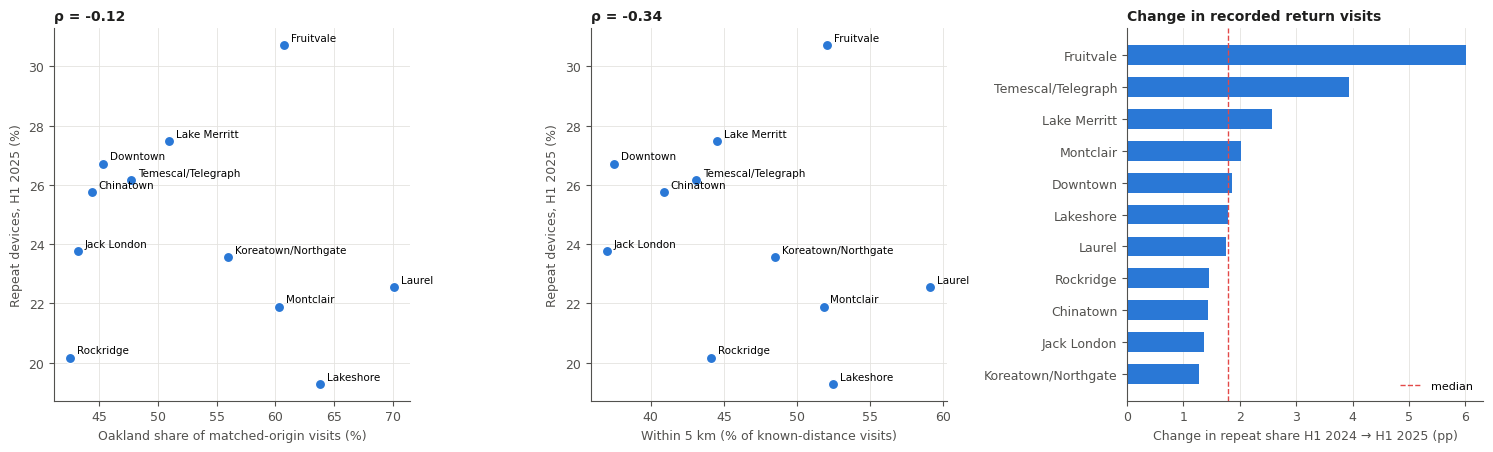

In [33]:
rr = repeat[repeat.time_period == 'all'].copy()
rr['multi_month_share'], rr['visits_per_device_half'] = rr.devices_active_multiple_months / rr.unique_devices, rr.visit_count / rr.unique_devices
rep = {h: rr[rr.half_year == h].set_index('corridor_name').reindex(CORRIDORS) for h in ['2024H1', '2025H1', '2024H2', '2025H2']}
rep_tbl = pd.DataFrame({
    'repeat share H1 2024 (%)': 100 * rep['2024H1'].repeat_device_prop, 'repeat share H1 2025 (%)': 100 * rep['2025H1'].repeat_device_prop,
    'Δ pp (H1)': 100 * (rep['2025H1'].repeat_device_prop - rep['2024H1'].repeat_device_prop),
    'Δ pp (H2)': 100 * (rep['2025H2'].repeat_device_prop - rep['2024H2'].repeat_device_prop),
    'multi-month devices H1 2025 (%)': 100 * rep['2025H1'].multi_month_share, 'Δ pp multi-month (H1)': 100 * (rep['2025H1'].multi_month_share - rep['2024H1'].multi_month_share),
    'visits per device H1 2024': rep['2024H1'].visits_per_device_half, 'visits per device H1 2025': rep['2025H1'].visits_per_device_half})
rep_tbl['Δ pp (H1) relative to median'] = rep_tbl['Δ pp (H1)'] - rep_tbl['Δ pp (H1)'].median()
display(rep_tbl.sort_values('repeat share H1 2025 (%)', ascending=False).round(2))

# relate repeat visitation to origins and distance (H1 2025, adjusted lenses)
o_h1 = origin_wide(2025, range(1, 7), 'adjusted'); oak_h1 = 100 * o_h1.Oakland / o_h1.sum(axis=1)
d_h1 = dist_summary(2025, range(1, 7), 'adjusted')
vol = ov25.raw_visits
rel = pd.DataFrame({'repeat share H1 2025': rep['2025H1'].repeat_device_prop, 'Oakland share (H1 2025, adj)': oak_h1, 'within 5 km (H1 2025, adj)': d_h1['within 5 km'], 'raw visits / month 2025': vol})
display(rel.corr(method='spearman').round(2).loc[['repeat share H1 2025']])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (xcol, xl) in zip(axes[:2], [('Oakland share (H1 2025, adj)', 'Oakland share of matched-origin visits (%)'), ('within 5 km (H1 2025, adj)', 'Within 5 km (% of known-distance visits)')]):
    ax.scatter(rel[xcol], 100 * rel['repeat share H1 2025'], s=55, color=C_BLUE, edgecolor='white', zorder=3)
    for c in CORRIDORS: ax.annotate(c, (rel.loc[c, xcol], 100 * rel.loc[c, 'repeat share H1 2025']), xytext=(5, 3), textcoords='offset points', fontsize=7.5)
    ax.set_xlabel(xl); ax.set_ylabel('Repeat devices, H1 2025 (%)'); ax.set_title('ρ = %.2f' % spearmanr(rel[xcol], rel['repeat share H1 2025'])[0], loc='left')
ax = axes[2]; od = rep_tbl['Δ pp (H1)'].sort_values().index; y = np.arange(len(od))
ax.barh(y, rep_tbl.loc[od, 'Δ pp (H1)'], color=C_BLUE, height=0.62); ax.axvline(rep_tbl['Δ pp (H1)'].median(), color=C_RED, lw=1, ls='--', label='median')
ax.set_yticks(y); ax.set_yticklabels(od); ax.grid(axis='y', visible=False); ax.set_xlabel('Change in repeat share H1 2024 → H1 2025 (pp)'); ax.legend(fontsize=8); ax.set_title('Change in recorded return visits', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: recorded return visits.**
- **Repeat shares rose in every corridor** from H1 2024 to H1 2025 (+1.3 to +6.0 points, median +1.8), partly because visits per device rose across corridors. Relative to that median the clear outliers are **Fruitvale (+4.2 points; multi-month devices 8.6% → 13.8%)** and **Temescal/Telegraph (+2.2)**; the others are within ±0.8 points. H2 changes (−1.0 to +4.7) include the weak December 2025.
- **Repeat use follows volume, not locality.** Repeat share correlates with raw volume (ρ = 0.95, 0.94 with adjusted volume) but not with Oakland share (ρ = −0.12) and slightly negatively with the within-5 km share (ρ = −0.34): the most local and Oakland-oriented corridors (Laurel, Lakeshore, Montclair) are not the ones with the most return visits. The densest corridors are where the same devices are recorded on several dates, which could reflect workers, residents or frequent visitors; the exports cannot say which.
- These are **recorded return visits of devices in one provider's half-year ID space**, not customer loyalty or business retention; they are unweighted and sensitive to how long a device is observed.

### 6.3 Weekday vs weekend during the LIMA recovery (2019 → 2022)
Within LIMA, the weekend ÷ weekday per-day ratio and the separate recovery of weekday and weekend visits show whether slow recoverers were weekday-oriented corridors.

,"weekend ÷ weekday per day, 2019","weekend ÷ weekday per day, 2022",weekday visits 2022 ÷ 2019,weekend visits 2022 ÷ 2019,evening share 2019 (%),evening share 2022 (%),all-visitor recovery 2022 ÷ 2019 (raw)
corridor_name,,,,,,,
Lake Merritt,0.52,0.81,0.62,0.98,24.10,31.88,0.68
Downtown,0.49,0.78,0.67,1.08,19.21,27.05,0.73
Chinatown,0.86,0.96,0.74,0.84,22.27,18.98,0.76
Montclair,1.04,0.93,0.84,0.76,25.38,21.64,0.81
Koreatown/Northgate,0.90,0.98,0.86,0.95,30.98,32.98,0.88
Rockridge,1.02,1.14,0.85,0.96,35.15,32.56,0.88
Jack London,1.11,1.08,0.92,0.91,32.49,32.28,0.92
Lakeshore,1.19,1.01,1.02,0.88,29.46,27.45,0.98
Temescal/Telegraph,0.90,0.93,1.00,1.06,30.55,32.36,1.02


Spearman: 2019 weekend ÷ weekday ratio vs recovery: 0.52; weekday recovery vs all-visitor recovery: 0.98


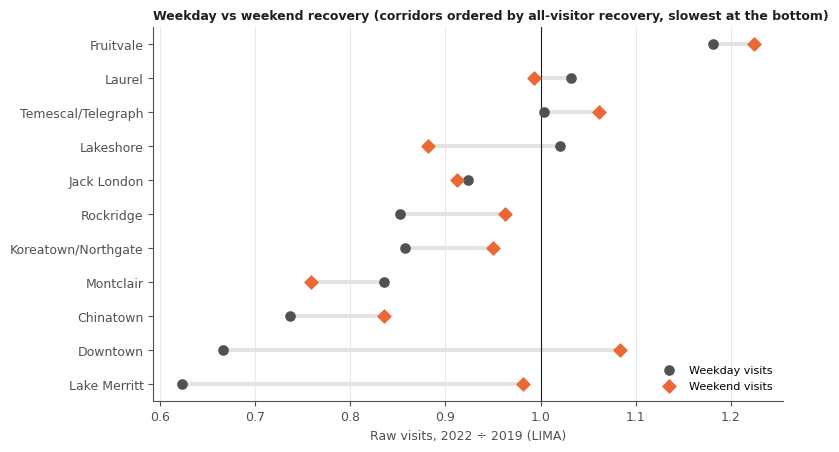

In [34]:
tm19, tm22 = timing_table(2019), timing_table(2022)
def period_ratio(period):
    s = stops[(stops.time_period == period) & stops.year.isin([2019, 2022])].groupby(['corridor_name', 'year']).visit_count.sum().unstack()
    return (s[2022] / s[2019]).reindex(CORRIDORS)
lima_time = pd.DataFrame({'weekend ÷ weekday per day, 2019': tm19['weekend ÷ weekday per-day ratio'], 'weekend ÷ weekday per day, 2022': tm22['weekend ÷ weekday per-day ratio'],
                          'weekday visits 2022 ÷ 2019': period_ratio('weekdays'), 'weekend visits 2022 ÷ 2019': period_ratio('weekends'),
                          'evening share 2019 (%)': tm19['evening share of all visits (%)'], 'evening share 2022 (%)': tm22['evening share of all visits (%)'],
                          'all-visitor recovery 2022 ÷ 2019 (raw)': ann_raw[2022]}).reindex(ann_raw[2022].sort_values().index)
display(lima_time.round(2))
print('Spearman: 2019 weekend ÷ weekday ratio vs recovery: %.2f; weekday recovery vs all-visitor recovery: %.2f' % (
    spearmanr(lima_time['weekend ÷ weekday per day, 2019'], lima_time['all-visitor recovery 2022 ÷ 2019 (raw)'])[0],
    spearmanr(lima_time['weekday visits 2022 ÷ 2019'], lima_time['all-visitor recovery 2022 ÷ 2019 (raw)'])[0]))
fig, ax = plt.subplots(figsize=(8, 4.6)); y = np.arange(len(lima_time))
ax.hlines(y, lima_time['weekday visits 2022 ÷ 2019'], lima_time['weekend visits 2022 ÷ 2019'], color=GRID, lw=3, zorder=1)
ax.scatter(lima_time['weekday visits 2022 ÷ 2019'], y, s=44, color=INK_2, zorder=3, label='Weekday visits'); ax.scatter(lima_time['weekend visits 2022 ÷ 2019'], y, s=44, color=C_ORANGE, marker='D', zorder=3, label='Weekend visits')
ax.axvline(1, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(lima_time.index); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel('Raw visits, 2022 ÷ 2019 (LIMA)'); ax.set_title('Weekday vs weekend recovery (corridors ordered by all-visitor recovery, slowest at the bottom)', loc='left', fontsize=9)
plt.tight_layout(); plt.show()

**Takeaways: weekday vs weekend in the LIMA recovery.** The slowest-recovering corridors were the weekday-oriented ones. In 2019, Downtown and Lake Merritt had weekend days at only 0.49× and 0.52× a weekday's visits, against 0.9–1.2 elsewhere (Chinatown 0.86). By 2022 weekday visits had recovered to only 0.67× and 0.62× of 2019 while weekend visits were back at 1.08× and 0.98×, so their weekend ÷ weekday ratio rose to 0.78 and 0.81. Chinatown shows a milder version (0.86 → 0.96; weekdays 0.74×, weekends 0.84×). The 2019 weekend ÷ weekday ratio is positively related to recovery (ρ = 0.52), and weekday recovery tracks the all-visitor recovery almost perfectly (ρ = 0.98). Evening shares rose in Downtown (19% → 27%) and Lake Merritt (24% → 32%). **The slow recoverers lost weekday, mostly non-Oakland activity: a pattern consistent with commuter or office-linked visitation, though the exports contain no information on purpose.**

## 7. Data validity, completeness and focused robustness checks
The basic counts reconciled in section 0. This section asks whether the exports can *support the substantive questions* and how much the headline findings depend on measurement choices. It first reviews completeness and the diagnostics that are available, then traces the extraction choices that could change a finding (using the extraction notebook `east_bay_corridor_activity_full.ipynb`: its code, saved outputs and the pilots), then investigates suspicious patterns seen in sections 1–6, tests the headline findings against alternative lenses, and ends with an action table. Nothing here modifies an export, redefines a measure or re-runs extraction.

### 7.1 Completeness and available diagnostics

In [35]:
present = {p.name for p in DATA_DIR.iterdir() if p.is_dir()}
diag = pd.DataFrame([{'table': t, 'status': 'exported' if t in present else 'NOT exported', 'role': r} for t, r in [
    ('provider_coverage_screen', 'candidate-provider device counts on the 10th ±1 day, which drove the provider schedule'),
    ('extraction_coverage', 'requested days vs days with activity per chunk (the notebook only asserts the total 2,557 = 2,557)'),
    ('provider_activity_daily', 'daily stop assignments and distinct IDs of the selected provider: the only day-level view of source completeness'),
    ('home_sample_index', 'CBG × month sample counts, weights, extreme-weight flags'),
    ('provider_home_sample', 'HOME sample by provider and month'),
    ('corridors_geohash9_diagnostics', 'geohash cover and shared-cell counts between corridors'),
    ('corridor_homes_monthly', 'corridor × month × CBG detail (loaded selectively below)')]])
display(diag)
print('Months with exactly one HOME snapshot (day 10):', int((denoms.snapshots == 1).sum()), '/ 84;',
      'months with one contributing HOME provider:', int((denoms.contributing_providers == 1).sum()), '/ 84;',
      'unclassified HOME sample (should be 0):', float(denoms.unclassified_home_sample.sum()))

exp_rows = EXPECTED_CORRIDORS * EXPECTED_MONTHS * len(TIME_PERIODS)
absent_o = (exp_rows - origin.groupby('home_geography').size()).rename('absent rows')
absent_d = (exp_rows - dist.groupby('distance_band').size()).rename('absent rows')
print('\nAbsent origin-category rows (corridor × month × period with no device in the category): expected', exp_rows, 'per category'); display(absent_o[absent_o > 0].to_frame().T)
print('Absent distance-band rows:'); display(absent_d[absent_d > 0].to_frame().T)
ab = origin.groupby(['corridor_name', 'home_geography']).size().unstack().reindex(CORRIDORS)
print('Share of absent origin rows falling in the three smallest corridors:', f'{((exp_rows / 5 - ab.min(axis=1)).reindex(["Montclair", "Lakeshore", "Laurel"]).sum() / max((exp_rows / 5 - ab).sum().sum(), 1)):.0%}')

mins = act.groupby(['corridor_name', 'provider_id']).agg(min_devices=('unique_devices', 'min'), min_matched=('home_matched_devices', 'min')).unstack().reindex(CORRIDORS)
display(mins)

,table,status,role
0,provider_coverage_screen,NOT exported,"candidate-provider device counts on the 10th ±1 day, which drove the provider schedule"
1,extraction_coverage,NOT exported,"requested days vs days with activity per chunk (the notebook only asserts the total 2,557 = 2,557)"
2,provider_activity_daily,NOT exported,daily stop assignments and distinct IDs of the selected provider: the only day-level view of source completeness
3,home_sample_index,NOT exported,"CBG × month sample counts, weights, extreme-weight flags"
4,provider_home_sample,NOT exported,HOME sample by provider and month
5,corridors_geohash9_diagnostics,NOT exported,geohash cover and shared-cell counts between corridors
6,corridor_homes_monthly,exported,corridor × month × CBG detail (loaded selectively below)


Months with exactly one HOME snapshot (day 10): 84 / 84; months with one contributing HOME provider: 84 / 84; unclassified HOME sample (should be 0): 0.0

Absent origin-category rows (corridor × month × period with no device in the category): expected 4620 per category


home_geography,No matched Bay Area HOME,Rest Bay Area,Rest East Bay,San Francisco
absent rows,1,17,1,52


Absent distance-band rows:


distance_band,02: 5–10 km,03: 10–25 km,04: 25–50 km,05: 50–100 km,06: 100+ km,Unknown distance
absent rows,1,6,9,77,1838,1


Share of absent origin rows falling in the three smallest corridors: 6%


min_devices               min_matched             
provider_id                LIMA   PAPA SIERRA        LIMA  PAPA SIERRA
corridor_name                                                         
Fruitvale                  1601  12244    142        1416  5347    121
Lake Merritt               1504  15310    252        1330  6507    182
Downtown                   1202  11512    228        1035  5750    143
Temescal/Telegraph         1723  10300    216        1510  4781    164
Chinatown                  1625   8699    155        1487  4662    113
Jack London                1203   9849    204        1028  4151    136
Koreatown/Northgate        1485   6169    137        1338  2815     97
Rockridge                  1001   2996    111         928  1789     82
Laurel                      759   2548     52         674  1347     40
Lakeshore                   774   2278     67         710  1236     53
Montclair                   415   1118     32         384   738     22

**Completeness reading.** All 84 months and 11 corridors are present at every grain, with no zero-activity corridor-month. The rows that are absent in the category and distance tables are all legitimate zeros (far distance bands and the small categories in the small corridors; totals reconcile exactly). Six extraction tables listed in the extraction notebook were not exported to this folder, including the only diagnostics that could demonstrate day-level source completeness (`provider_activity_daily`, `extraction_coverage`) and provider screening (`provider_coverage_screen`). The extraction notebook's own QA shows only that *some* corridor recorded activity on all 2,557 requested dates, which cannot rule out a corridor- or provider-specific shortfall inside a month. This matters most for December 2025 and for the 2023 provider transition, examined below.

### 7.2 Provider comparability: levels differ by provider for reasons beyond activity
Pooled by provider, the same corridors look very different in *how* devices are observed. These are ratios computed from the exported totals, not extra extractions.

In [36]:
def comparability(df):
    g = df.groupby('provider_id')[['raw_stop_count', 'visit_count', 'unique_devices', 'home_matched_devices', 'home_matched_visits', 'unmatched_visits']].sum()
    return pd.DataFrame({'stop assignments per visit': g.raw_stop_count / g.visit_count, 'visits per device-month': g.visit_count / g.unique_devices,
                         'HOME-match rate (devices)': g.home_matched_devices / g.unique_devices, 'matched share of visits': g.home_matched_visits / g.visit_count,
                         'visits per matched device-month': g.home_matched_visits / g.home_matched_devices,
                         'visits per unmatched device-month': g.unmatched_visits / (g.unique_devices - g.home_matched_devices)})
pc = comparability(act).reindex(PROVIDER_ORDER)
papa_year = pd.concat({f'PAPA {y}': comparability(act[(act.provider_id == 'PAPA') & (act.year == y)]).iloc[0] for y in (2023, 2024, 2025)}, axis=1).T
display(pd.concat([pc, papa_year]).round(3))

bnd_months = [202212, 202301, 202306, 202307, 202308]
bnd = city[city.year_month.isin(bnd_months)][['year_month', 'provider_id', 'visits', 'devices', 'matched_devices', 'adjusted', 'bay_home_sample', 'match_rate', 'visits_per_device', 'effective_weight']].set_index('year_month')
print('The three provider boundaries (sum of 11 corridors):'); display(bnd.round(2))

,stop assignments per visit,visits per device-month,HOME-match rate (devices),matched share of visits,visits per matched device-month,visits per unmatched device-month
LIMA,1.34,2.04,0.80,0.86,2.18,1.48
SIERRA,1.56,2.20,0.75,0.82,2.40,1.58
PAPA,1.26,1.44,0.43,0.49,1.65,1.28
PAPA 2023,1.26,1.40,0.46,0.52,1.57,1.25
PAPA 2024,1.25,1.39,0.43,0.49,1.57,1.25
PAPA 2025,1.27,1.50,0.42,0.49,1.75,1.32


The three provider boundaries (sum of 11 corridors):


,provider_id,visits,devices,matched_devices,adjusted,bay_home_sample,match_rate,visits_per_device,effective_weight
year_month,,,,,,,,,
202212,LIMA,82835,43444,33916,"62,609.74","232,911.00",0.78,1.91,0.90
202301,SIERRA,3899,1804,1308,"2,524.46","20,217.00",0.73,2.16,0.83
202306,SIERRA,3610,1672,1229,"3,757.26","12,947.00",0.74,2.16,1.29
202307,PAPA,134089,94313,45595,"101,093.61","1,628,994.00",0.48,1.42,1.39
202308,PAPA,140107,102035,40402,"97,434.03","1,574,605.00",0.40,1.37,1.51


**Providers are not comparable, which is why every long-term chart is segmented.** Visits per device-month are about 2.0–2.2 for LIMA and SIERRA but about 1.4–1.5 for PAPA, and the HOME-match rate falls from roughly 0.8 to 0.4; raw monthly devices are ~44 k in Dec 2022, ~1.8 k in Jan 2023 and ~94 k in Jul 2023. None of those jumps can be interpreted as activity change. Within a provider, matched devices are consistently more active than unmatched ones (visits per matched device-month is about 1.6× the unmatched figure in PAPA), which means the matched population is the more persistent part of the panel, not a random draw.

In [37]:
# Sample-weight reconstruction from the exported denominators (the CBG-level weights live in corridor_homes_monthly, section 7.3).
ref = denoms[denoms.is_reference_month == 1].groupby('provider_segment').bay_home_sample.mean()
recomputed_ratio = denoms.provider_segment.map(ref) / denoms.bay_home_sample
print('Max |recomputed − exported| Bay-wide sample ratio: %.2e' % (recomputed_ratio - denoms.bay_sample_ratio).abs().max())
print('Reference months per segment (is_reference_month sums) vs exported reference_months:',
      denoms.groupby('provider_segment').is_reference_month.sum().to_dict(), denoms.groupby('provider_segment').reference_months.first().to_dict())
papa_ref = denoms[(denoms.provider_segment == 'S3_PAPA')].set_index('year_month')
print('PAPA reference window Jul 2023–Jun 2024: Bay HOME sample rises from %.2fM to %.2fM (×%.1f) inside it; its mean (%.2fM) is the weight baseline.' % (
      papa_ref.bay_home_sample.loc[202307] / 1e6, papa_ref.bay_home_sample.loc[202406] / 1e6, papa_ref.bay_home_sample.loc[202406] / papa_ref.bay_home_sample.loc[202307], ref['S3_PAPA'] / 1e6))
print('Adjusted ÷ matched visits (average weight) in Jul–Oct 2023 vs Jan–Dec 2024: %.2f vs %.2f' % (
      city[city.year_month.between(202307, 202310)].adjusted.sum() / city[city.year_month.between(202307, 202310)].matched_visits.sum(),
      city[city.year == 2024].adjusted.sum() / city[city.year == 2024].matched_visits.sum()))

Max |recomputed − exported| Bay-wide sample ratio: 4.99e-13
Reference months per segment (is_reference_month sums) vs exported reference_months: {'S1_LIMA': 12, 'S2_SIERRA': 6, 'S3_PAPA': 12} {'S1_LIMA': 12, 'S2_SIERRA': 6, 'S3_PAPA': 12}
PAPA reference window Jul 2023–Jun 2024: Bay HOME sample rises from 1.63M to 3.08M (×1.9) inside it; its mean (2.29M) is the weight baseline.
Adjusted ÷ matched visits (average weight) in Jul–Oct 2023 vs Jan–Dec 2024: 1.35 vs 0.83


**Methodological review: what was traced in the extraction notebook, and what the exports let us verify**

| Choice | How it is implemented | Evidence in the exports / pilots | Assessment |
|---|---|---|---|
| **Provider selection** | One provider per half-year: the largest summed sampled device count on the 10th (±1 padded day) across six months, among providers present on all six dates; no manual overrides. | Schedule matches LIMA / SIERRA / PAPA exactly. Pilot 4 shows SIERRA alongside LIMA in 2019 (2,292 vs 2,598 corridor devices on one day) and alongside PAPA later (68–94 vs 4,061–6,269). `provider_coverage_screen` was not exported, so the H1-2023 candidates cannot be seen. | **Reasonable limitation.** Coverage is estimated from one day a month. The unusually small H1-2023 panel is unexplained without the screen (flagged below). |
| **Event date vs local date** | Source rows are fetched for event dates ±1 day, then filtered to the *local* date of `stop_zoned_datetime`; duplicates from overlapping event partitions are removed (latest processing date kept). | Weekday + weekend visits equal all visits in every row; no corridor-month is empty. Daily counts are not exported. | **Sound by construction;** day-level completeness unverified. |
| **Stop de-duplication and counting** | Key = provider, corridor, ID, geohash, stop time, dwell. A stop spanning several geohash cells of a corridor is several raw *stop assignments*; visits (device-days) are unaffected. | Stop assignments per visit: 1.34 (LIMA), 1.56 (SIERRA), 1.26 (PAPA). | **Documented limitation.** Raw stop counts are less comparable than visits; this notebook uses visits. |
| **Time-period assignment** | Local start hour and weekday of each stop; a device-day belongs to a window if *any* stop starts in it. | 09–17 ⊆ weekdays and evening ⊆ all in every row; stops starting 23:00–08:59 appear only in `all`/`weekdays`/`weekends`. | **Verified;** windows overlap and have different hours. |
| **HOME snapshot and matching** | HOME of the same provider, US, nine Bay counties, confidence ≥ 0.60, **one snapshot on the 10th**; the Bay-county filter is applied *before* choosing each device's highest-confidence record; visitors are matched only to their own month's snapshot. | Match rate 0.80 (LIMA) → 0.43 (PAPA). Pilot 4: 70% of corridor devices seen on 10 Jan 2024 had a confident HOME code (any location) vs 43% of January 2024 device-months. Matched devices are more active (1.65 vs 1.28 visits per device-month in PAPA). No "Rest California/US" categories occur, consistent with the Bay filter coming first. | **Limitation with potential material effect** on origin and distance results (a device first seen after the 10th is unmatched). Not a confirmed error; prevalence of multi-record devices cannot be tested here. Flagged as a rerun candidate. |
| **Geography classification** | TIGER2019 CBG codes; Oakland = CBG representative point inside the Oakland place polygon; East Bay = counties 001/013; SF = 075. | All category rules pass (section 4); 4,751 CBGs have coordinates; exported distances reproduce exactly from coordinates. Pilot 4: the 2019 vintage matched every Bay device, the 2020 boundaries only ~88%. | **Verified.** Boundary-straddling CBGs are assigned by point; no municipality claims. |
| **Sample weights** | Reference = first ≤ 12 months of each segment; CBG-level baseline ÷ current where both ≥ 30, otherwise the Bay-wide ratio; extremes flagged (> 5 or < 0.2), not clipped. | Bay ratios reproduce exactly from `bay_month_denoms`; adjusted totals reconcile across tables to 1e-12; weights are identical across corridors for a CBG-month. | **Implementation matches its documentation; no confirmed implementation problem.** Consequential limitations: the PAPA reference window spans a ×1.9 rise in the sample (average weight 1.35 in Jul–Oct 2023 vs 0.83 in 2024), LIMA and SIERRA rely heavily on the Bay-wide fallback, and weights assume corridor visitors scale with the Bay HOME sample. |

**Result of the review.** No confirmed implementation error was found in the reviewed logic, and exported fields match their documented meaning wherever they could be checked. The consequential issues are *methodological limitations* (provider panels, a single HOME snapshot, the weighting assumption) and *unverified coverage* (missing diagnostics), not bugs.

### 7.3 Extreme-weight diagnostics (selective load of `corridor_homes_monthly`)
`home_sample_index` was not exported, but each row of `corridor_homes_monthly` carries its applied weight and whether it came from the CBG-level ratio or the Bay-wide fallback. Only the `all` period and the columns needed are read (84 partitions). This answers one question: *do cells with extreme weights drive the adjusted findings?* The extraction flags weights above 5 or below 0.2 as extreme and does not clip them; as a sensitivity only, adjusted visits are recomputed here with weights capped at the flagged thresholds (0.2 and 5), and with extreme-weight cells dropped.

In [38]:
hm_cols = ['corridor_name', 'year_month', 'time_period', 'block_group_id', 'visit_count', 'applied_sample_ratio', 'normalization_method', 'normalized_visit_count']
parts_hm = [pd.read_csv(f, usecols=hm_cols) for f in tqdm(sorted((DATA_DIR / 'corridor_homes_monthly').glob('*.csv.gz')), desc='corridor_homes_monthly', mininterval=2)]
hmo = pd.concat(parts_hm, ignore_index=True)
hmo = hmo[(hmo.time_period == 'all') & (hmo.block_group_id != 'UNKNOWN')].copy()
hmo['year'] = hmo.year_month // 100; hmo['month'] = hmo.year_month % 100
hmo['provider_id'] = hmo.year_month.map(PROV_OF)
hmo['extreme'] = (hmo.applied_sample_ratio > EXTREME_WEIGHT_HIGH) | (hmo.applied_sample_ratio < EXTREME_WEIGHT_LOW)
hmo['fallback'] = hmo.normalization_method.eq('bay_fallback')
hmo['adj_clipped'] = hmo.visit_count * hmo.applied_sample_ratio.clip(*WEIGHT_CLIP)
hmo['adj_excl_extreme'] = np.where(hmo.extreme, 0.0, hmo.normalized_visit_count)
print(f'{len(hmo):,} corridor × month × CBG rows loaded (period "all", matched CBGs)')

# reconciliation and weight consistency
rec = hmo.groupby(['corridor_name', 'year_month']).normalized_visit_count.sum().rename('adj_homes').reset_index().merge(
    act[['corridor_name', 'year_month', 'adjusted_known_home_visits']], on=['corridor_name', 'year_month'])
print('Max |adjusted visits from corridor_homes_monthly − corridor_stops|: %.2e' % (rec.adj_homes - rec.adjusted_known_home_visits).abs().max())
print('Weights identical for a given CBG-month across corridors:', bool(hmo.groupby(['year_month', 'block_group_id']).applied_sample_ratio.nunique().max() == 1))

wd = hmo.groupby('provider_id').apply(lambda d: pd.Series({
    'CBG-month cells': len(d), 'min weight': d.applied_sample_ratio.min(), 'median weight': d.applied_sample_ratio.median(), 'max weight': d.applied_sample_ratio.max(),
    '% of matched visits in extreme-weight cells': 100 * d[d.extreme].visit_count.sum() / d.visit_count.sum(),
    '% of adjusted visits in extreme-weight cells': 100 * d[d.extreme].normalized_visit_count.sum() / d.normalized_visit_count.sum(),
    '% of matched visits with weight > 5': 100 * d[d.applied_sample_ratio > EXTREME_WEIGHT_HIGH].visit_count.sum() / d.visit_count.sum(),
    '% of matched visits with weight < 0.2': 100 * d[d.applied_sample_ratio < EXTREME_WEIGHT_LOW].visit_count.sum() / d.visit_count.sum(),
    '% of matched visits using the Bay-wide fallback': 100 * d[d.fallback].visit_count.sum() / d.visit_count.sum()})).reindex(PROVIDER_ORDER)
display(wd.round(2))

corridor_homes_monthly:   0%|          | 0/84 [00:00<?, ?it/s]

corridor_homes_monthly:  26%|██▌       | 22/84 [00:02<00:05, 10.99it/s]

corridor_homes_monthly:  54%|█████▎    | 45/84 [00:04<00:03, 11.08it/s]

corridor_homes_monthly:  81%|████████  | 68/84 [00:06<00:01, 10.84it/s]

corridor_homes_monthly: 100%|██████████| 84/84 [00:08<00:00, 10.02it/s]

1,071,812 corridor × month × CBG rows loaded (period "all", matched CBGs)
Max |adjusted visits from corridor_homes_monthly − corridor_stops|: 3.64e-12


Weights identical for a given CBG-month across corridors: True


,CBG-month cells,min weight,median weight,max weight,% of matched visits in extreme-weight cells,% of adjusted visits in extreme-weight cells,% of matched visits with weight > 5,% of matched visits with weight < 0.2,% of matched visits using the Bay-wide fallback
provider_id,,,,,,,,,
LIMA,"563,758.00",0.25,0.92,5.92,0.00,0.00,0.00,0.00,46.21
SIERRA,"7,013.00",0.83,0.93,1.29,0.00,0.00,0.00,0.00,99.87
PAPA,"501,041.00",0.02,0.88,10.71,2.81,0.51,0.00,2.81,0.00


In [39]:
def yoy_from(col, df=hmo, y0=2024, y1=2025, months=range(1, 13)):
    s = df[df.month.isin(months)].groupby(['corridor_name', 'year'])[col].sum().unstack()
    return pct_change(s[y0], s[y1]).reindex(CORRIDORS)
def lima_ratio(col):
    s = hmo[hmo.provider_id == 'LIMA'].groupby(['corridor_name', 'year'])[col].sum().unstack()
    return (s[2022] / s[2019]).reindex(CORRIDORS)
ew = hmo[hmo.year == 2025].groupby('corridor_name').apply(lambda d: pd.Series({'% of 2025 adjusted visits in extreme-weight cells': 100 * d[d.extreme].normalized_visit_count.sum() / d.normalized_visit_count.sum(),
                                                                          '% in Bay-fallback cells': 100 * d[d.fallback].normalized_visit_count.sum() / d.normalized_visit_count.sum()})).reindex(CORRIDORS)
sens = pd.DataFrame({'PAPA Δ% adjusted (headline)': yoy_from('normalized_visit_count'), 'extreme weights capped at 0.2 / 5': yoy_from('adj_clipped'), 'extreme cells dropped': yoy_from('adj_excl_extreme'),
                     'matched, unweighted': yoy_from('visit_count'),
                     'LIMA 2022÷2019 (headline)': lima_ratio('normalized_visit_count'), 'LIMA capped': lima_ratio('adj_clipped')}).join(ew)
display(sens.round(2))
print('Spearman headline vs clipped (PAPA Δ%%): %.2f; headline vs extreme-dropped: %.2f; headline vs unweighted matched: %.2f' % (
    spearmanr(sens.iloc[:, 0], sens.iloc[:, 1])[0], spearmanr(sens.iloc[:, 0], sens.iloc[:, 2])[0], spearmanr(sens.iloc[:, 0], sens.iloc[:, 3])[0]))
print('Max shift in PAPA Δ%% from clipping: %.1f pp; from dropping extreme cells: %.1f pp' % ((sens.iloc[:, 1] - sens.iloc[:, 0]).abs().max(), (sens.iloc[:, 2] - sens.iloc[:, 0]).abs().max()))
eff = act[act.year.isin([2024, 2025])].groupby(['corridor_name', 'year']).apply(lambda d: d.adjusted_known_home_visits.sum() / d.home_matched_visits.sum()).unstack().reindex(CORRIDORS)
eff['change in average weight (%)'] = pct_change(eff[2024], eff[2025])
display(eff.rename(columns={2024: 'avg weight 2024', 2025: 'avg weight 2025'}).round(3))

,PAPA Δ% adjusted (headline),extreme weights capped at 0.2 / 5,extreme cells dropped,"matched, unweighted",LIMA 2022÷2019 (headline),LIMA capped,% of 2025 adjusted visits in extreme-weight cells,% in Bay-fallback cells
corridor_name,,,,,,,,
Fruitvale,4.13,5.13,0.98,29.75,1.01,1.01,3.22,0.00
Lake Merritt,11.56,11.74,11.09,46.73,0.57,0.57,0.45,0.00
Downtown,-1.05,-0.91,-1.38,14.74,0.62,0.62,0.34,0.00
Temescal/Telegraph,6.83,8.02,3.54,44.98,0.86,0.86,3.09,0.00
Chinatown,12.89,13.07,12.47,31.01,0.66,0.66,0.38,0.00
Jack London,2.76,2.91,2.44,14.76,0.78,0.78,0.32,0.00
Koreatown/Northgate,15.35,15.55,14.86,31.17,0.74,0.74,0.44,0.00
Rockridge,2.88,3.26,2.40,18.62,0.76,0.76,0.47,0.00
Laurel,2.62,2.84,1.88,13.76,0.88,0.88,0.73,0.00


Spearman headline vs clipped (PAPA Δ%): 0.99; headline vs extreme-dropped: 0.94; headline vs unweighted matched: 0.82
Max shift in PAPA Δ% from clipping: 1.2 pp; from dropping extreme cells: 3.3 pp


year,avg weight 2024,avg weight 2025,change in average weight (%)
corridor_name,,,
Fruitvale,0.71,0.57,-19.75
Lake Merritt,0.83,0.63,-23.97
Downtown,0.86,0.74,-13.76
Temescal/Telegraph,0.87,0.64,-26.31
Chinatown,0.87,0.75,-13.84
Jack London,0.87,0.78,-10.45
Koreatown/Northgate,0.87,0.76,-12.06
Rockridge,0.87,0.76,-13.27
Laurel,0.86,0.78,-9.80


**Takeaways: extreme weights.** In PAPA, extreme-weight cells (weights above 5 or below 0.2; observed range 0.02–10.7) hold 2.8% of matched visits but only 0.5% of adjusted visits, so they do not dominate. Capping them at the flagged thresholds moves PAPA changes by at most 1.2 points, and dropping them by at most 3.3: **Fruitvale falls from +4.1% to +1.0% and Temescal/Telegraph from +6.8% to +3.5%** (3% of their 2025 adjusted visits sit in extreme-weight cells); every other corridor moves by under 1 point, and the corridor order is unchanged (ρ = 0.99 capped, 0.94 dropped). The extreme weights in PAPA are all *down*-weights (below 0.2: CBGs whose sample grew more than five-fold over the reference); extreme cells are negligible in LIMA (maximum 5.9) and absent in SIERRA (0.83–1.29), but **LIMA uses the Bay-wide fallback for 46% of matched visits and SIERRA for 99.9%**, so their adjusted values are largely Bay-wide scaling. The PAPA average weight fell 10–26% between 2024 and 2025 (largest in Temescal/Telegraph −26%, Lake Merritt −24%, Fruitvale −20%, whose matched visitors are Oakland-heavy), which is exactly what separates matched +30–47% from adjusted +4–12% in those corridors.

### 7.4 Suspicious patterns: are they activity, measurement, or coverage?
Looking for abrupt changes, simultaneous moves across corridors, coverage/sample discontinuities and unusually weak months. A pattern is **not** declared an error merely because it is unexpected; the question is which explanation the available diagnostics favour, and what is left unresolved.

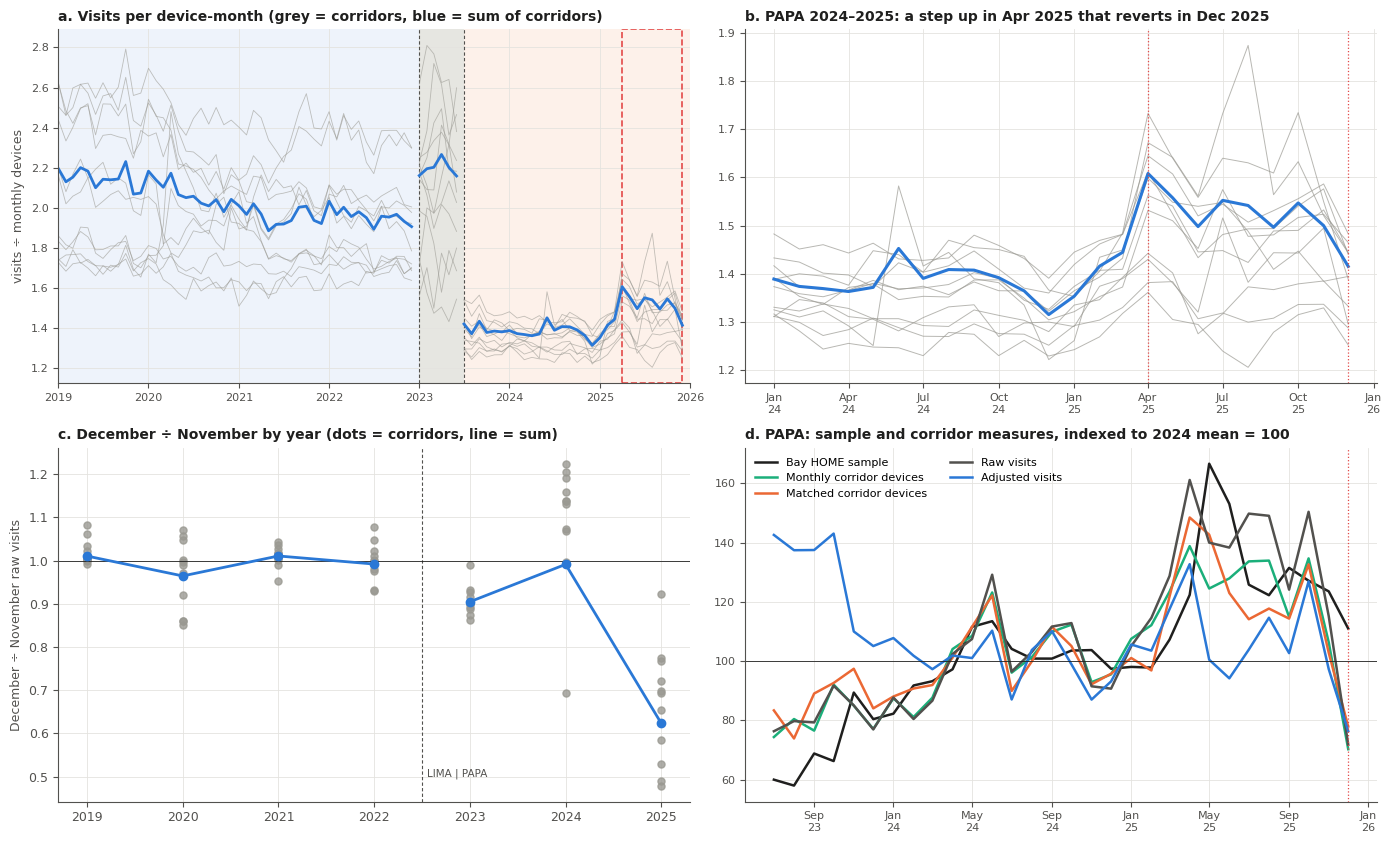

period,2024,Apr–Nov 2025,Dec 2025,Apr–Nov 2025 vs 2024 (%),Dec 2025 vs 2024 (%)
corridor_name,,,,,
Fruitvale,1.38,1.51,1.39,9.09,0.76
Lake Merritt,1.42,1.64,1.39,15.51,-2.19
Downtown,1.40,1.52,1.44,8.32,2.56
Temescal/Telegraph,1.36,1.66,1.44,21.50,5.81
Chinatown,1.45,1.56,1.48,7.89,2.57
Jack London,1.37,1.49,1.45,8.67,5.20
Koreatown/Northgate,1.36,1.51,1.47,11.04,7.76
Rockridge,1.28,1.34,1.29,4.05,0.28
Laurel,1.31,1.37,1.33,4.63,1.58


Corridors with visits-per-device up by more than 5% in Apr–Nov 2025 vs 2024: 8 of 11; Dec 2025 within ±3% of 2024: 8 of 11


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
ax = axes[0, 0]; shade_segments(ax, labels=False)
for c in CORRIDORS: segment_lines(ax, act[act.corridor_name == c], 'visits_per_unique_device', color=C_GRAY, lw=0.6, alpha=0.6)
segment_lines(ax, city, 'visits_per_device', color=C_BLUE, lw=2)
ax.axvspan(pd.Timestamp('2025-04-01'), pd.Timestamp('2025-12-01'), color='none', ec=C_RED, lw=1.2, ls='--')
ax.set_title('a. Visits per device-month (grey = corridors, blue = sum of corridors)', loc='left'); ax.set_ylabel('visits ÷ monthly devices'); year_axis(ax)
ax = axes[0, 1]
pm = act[act.provider_id == 'PAPA'].copy(); pm = pm[pm.year >= 2024]
for c in CORRIDORS: ax.plot(pm[pm.corridor_name == c].date, pm[pm.corridor_name == c].visits_per_unique_device, color=C_GRAY, lw=0.7, alpha=0.7)
ax.plot(city[(city.provider_id == 'PAPA') & (city.year >= 2024)].date, city[(city.provider_id == 'PAPA') & (city.year >= 2024)].visits_per_device, color=C_BLUE, lw=2.2)
ax.axvline(pd.Timestamp('2025-04-01'), color=C_RED, lw=0.9, ls=':'); ax.axvline(pd.Timestamp('2025-12-01'), color=C_RED, lw=0.9, ls=':')
ax.set_title('b. PAPA 2024–2025: a step up in Apr 2025 that reverts in Dec 2025', loc='left'); year_axis(ax); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
ax = axes[1, 0]
dn = act.pivot_table(index=['corridor_name', 'year'], columns='month', values='visit_count')
ratio_dn = (dn[12] / dn[11]).unstack().reindex(CORRIDORS)
for yr in ratio_dn.columns: ax.scatter([yr] * len(ratio_dn), ratio_dn[yr], s=26, color=C_GRAY, alpha=0.8, zorder=2)
cityr = city.pivot_table(index='year', columns=city.year_month % 100, values='visits'); dn_city = cityr[12] / cityr[11]
for yrs in ([2019, 2020, 2021, 2022], [2023, 2024, 2025]):      # one line per provider; none across the break
    ax.plot(yrs, dn_city.loc[yrs], color=C_BLUE, lw=2, marker='o', zorder=3)
ax.axvline(2022.5, color=INK_2, lw=0.8, ls=(0, (3, 2))); ax.text(2022.55, 0.5, 'LIMA | PAPA', fontsize=7.5, color=INK_2)
ax.axhline(1, color=INK, lw=0.6); ax.set_xticks(range(2019, 2026)); ax.set_ylabel('December ÷ November raw visits')
ax.set_title('c. December ÷ November by year (dots = corridors, line = sum)', loc='left')
ax = axes[1, 1]
base = city[city.year == 2024]
for col, lab, color in [('bay_home_sample', 'Bay HOME sample', INK), ('devices', 'Monthly corridor devices', C_AQUA), ('matched_devices', 'Matched corridor devices', C_ORANGE), ('visits', 'Raw visits', INK_2), ('adjusted', 'Adjusted visits', C_BLUE)]:
    g = city[city.provider_id == 'PAPA']; ax.plot(g.date, 100 * g[col] / base[col].mean(), color=color, lw=1.8, label=lab)
ax.axhline(100, color=INK, lw=0.6); ax.axvline(pd.Timestamp('2025-12-01'), color=C_RED, lw=0.9, ls=':'); ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.set_title('d. PAPA: sample and corridor measures, indexed to 2024 mean = 100', loc='left'); year_axis(ax); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
plt.tight_layout(); plt.show()

vstep = act[act.provider_id == 'PAPA'].assign(period=lambda d: np.where(d.year == 2024, '2024', np.where((d.year == 2025) & d.month.between(4, 11), 'Apr–Nov 2025', np.where((d.year == 2025) & (d.month == 12), 'Dec 2025', 'other'))))
vs = vstep[vstep.period != 'other'].groupby(['corridor_name', 'period']).apply(lambda d: d.visit_count.sum() / d.unique_devices.sum()).unstack().reindex(CORRIDORS)
vs['Apr–Nov 2025 vs 2024 (%)'] = pct_change(vs['2024'], vs['Apr–Nov 2025']); vs['Dec 2025 vs 2024 (%)'] = pct_change(vs['2024'], vs['Dec 2025'])
display(vs.round(3))
print('Corridors with visits-per-device up by more than 5%% in Apr–Nov 2025 vs 2024: %d of 11; Dec 2025 within ±3%% of 2024: %d of 11' % (
    int((vs['Apr–Nov 2025 vs 2024 (%)'] > 5).sum()), int((vs['Dec 2025 vs 2024 (%)'].abs() <= 3).sum())))

In [41]:
# December 2025: raw visits, devices and Bay sample against Dec 2024 and against November
dec = act[act.month.isin([11, 12]) & act.year.isin([2023, 2024, 2025])].pivot_table(index='corridor_name', columns=['year', 'month'], values='visit_count')
dev = act[act.month.isin([12]) & act.year.isin([2024, 2025])].pivot_table(index='corridor_name', columns='year', values='unique_devices')
dtab2 = pd.DataFrame({'Dec 2025 ÷ Dec 2024, raw visits': dec[(2025, 12)] / dec[(2024, 12)], 'Dec 2025 ÷ Dec 2024, devices': dev[2025] / dev[2024],
                      'Dec ÷ Nov 2025': dec[(2025, 12)] / dec[(2025, 11)], 'Dec ÷ Nov 2024': dec[(2024, 12)] / dec[(2024, 11)], 'Dec ÷ Nov 2023': dec[(2023, 12)] / dec[(2023, 11)]}).reindex(CORRIDORS)
dtab2.loc['Sum of 11 corridors'] = [city.set_index('year_month').visits[202512] / city.set_index('year_month').visits[202412], city.set_index('year_month').devices[202512] / city.set_index('year_month').devices[202412],
                                    city.set_index('year_month').visits[202512] / city.set_index('year_month').visits[202511], city.set_index('year_month').visits[202412] / city.set_index('year_month').visits[202411],
                                    city.set_index('year_month').visits[202312] / city.set_index('year_month').visits[202311]]
display(dtab2.round(2))
bs = denoms.set_index('year_month').bay_home_sample
print('Bay HOME sample, Dec 2025 ÷ Dec 2024: %.2f; Dec ÷ Nov 2025: %.2f. Corridors with Dec 2025 raw visits below Dec 2024: %d of 11.' % (bs[202512] / bs[202412], bs[202512] / bs[202511], int((dtab2['Dec 2025 ÷ Dec 2024, raw visits'].iloc[:-1] < 1).sum())))

# Fruitvale spikes: do they come from matched or unmatched devices?
f = act[(act.corridor_name == 'Fruitvale') & (act.provider_id == 'PAPA')].set_index('year_month')
def nb_ratio(s, m):
    ix = list(s.index); i = ix.index(m); nb = [s.iloc[j] for j in (i - 2, i - 1, i + 1, i + 2) if 0 <= j < len(s)]
    return s.iloc[i] / np.median(nb)
frows = [{'month': m, 'raw visits ÷ neighbours': nb_ratio(f.visit_count, m), 'matched visits ÷ neighbours': nb_ratio(f.home_matched_visits, m),
          'unmatched visits ÷ neighbours': nb_ratio(f.unmatched_visits, m), 'adjusted ÷ neighbours': nb_ratio(f.adjusted_known_home_visits, m), 'HOME-match rate': f.home_match_rate[m]} for m in [202406, 202410, 202502, 202504, 202507]]
display(pd.DataFrame(frows).set_index('month').round(2))

,"Dec 2025 ÷ Dec 2024, raw visits","Dec 2025 ÷ Dec 2024, devices",Dec ÷ Nov 2025,Dec ÷ Nov 2024,Dec ÷ Nov 2023
corridor_name,,,,,
Fruitvale,0.65,0.57,0.48,0.69,0.92
Lake Merritt,0.95,0.94,0.65,1.00,0.90
Downtown,0.63,0.60,0.49,1.13,0.89
Temescal/Telegraph,0.85,0.78,0.69,1.14,0.93
Chinatown,0.70,0.66,0.58,1.14,0.90
Jack London,0.98,0.90,0.92,1.07,0.87
Koreatown/Northgate,1.03,0.92,0.77,1.07,0.93
Rockridge,0.75,0.73,0.70,1.16,0.89
Laurel,0.77,0.74,0.77,1.19,0.90


Bay HOME sample, Dec 2025 ÷ Dec 2024: 1.14; Dec ÷ Nov 2025: 0.90. Corridors with Dec 2025 raw visits below Dec 2024: 10 of 11.


,raw visits ÷ neighbours,matched visits ÷ neighbours,unmatched visits ÷ neighbours,adjusted ÷ neighbours,HOME-match rate
month,,,,,
202406,2.12,2.24,2.02,1.90,0.38
202410,1.53,1.49,1.56,1.41,0.35
202502,1.60,1.19,1.91,1.27,0.28
202504,1.36,1.78,1.04,1.27,0.46
202507,1.46,1.40,1.51,1.24,0.35


**What the patterns suggest.**
- **Provider transitions** (table in 7.2): visits per device, match rate and sample size jump at each boundary. These are measurement discontinuities and are treated as such.
- **April–November 2025 step in visits per device.** Citywide visits per device-month rise from 1.39 (2024) to 1.54 (Apr–Nov 2025), up by more than 5% in 8 of 11 corridors simultaneously, and revert to 1.42 in December (within ±3% of 2024 in 8 corridors). The Bay HOME sample also steps up (to 4.5 M in May). A shift that is simultaneous across unrelated corridors, persistent for eight months and then reversing looks like **a change in how the panel is observed (device mix or stop processing) rather than corridor behaviour**. The diagnostics here cannot prove it. It inflates raw 2025 volume growth and any visit-based repeat measure.
- **December 2025.** December ÷ November raw visits is 0.62, against 0.99 in 2024 and 0.90 in 2023; monthly devices are 0.74× December 2024 while the Bay HOME sample is 1.14× its 2024 level, and ten of eleven corridors are below December 2024 (Jack London 0.98, Lake Merritt 0.95 and Koreatown/Northgate 1.03 are about level). A collapse in device counts without a matching fall in the HOME sample is the signature one would expect if source data for part of the month were thin, but it could also be genuinely weak activity. **Unresolved without `provider_activity_daily`.** It is neither interpolated nor removed; every full-year comparison is shown with and without December.
- **Isolated spikes.** Fruitvale's raw visits are 2.1× their neighbouring months in June 2024, with unmatched visits 2.0× and matched 2.2×; in Feb 2025 unmatched visits are 1.9× against 1.2× matched and the match rate drops to 0.28, and further spikes occur in Oct 2024 and Jul 2025. Spikes carried mainly by unmatched devices with higher visits per device point to transient crowds or a few very active devices. Other corridors have only isolated one-off months (Lakeshore Oct 2025 ×1.74, Laurel Jun 2025 ×0.70). Fruitvale's persistent step-up from mid-2024 (H2 2023 mean 18.9 k a month vs 52.0 k in 2025) is not explained by any diagnostic available here.
- **SIERRA.** Already addressed: its months are retained but not interpreted.

### 7.5 Robustness of the headline findings across lenses and windows
Each headline finding is re-tested against the alternatives available in the exports: raw all-visitor vs raw matched vs adjusted; the full year vs the same January–November window in both years; raw vs adjusted origin composition; and capped or dropped extreme weights. Spearman ρ compares the *ordering of the 11 corridors* (n = 11, so it is descriptive); sign agreement counts corridors where the direction of change agrees.

In [42]:
rob = []
def rho(a, b): return spearmanr(a.reindex(CORRIDORS), b.reindex(CORRIDORS))[0]
def reading(r): return 'consistent' if r >= 0.9 else 'mostly consistent' if r >= 0.7 else 'sensitive'
def add(finding, comparison, stat, read): rob.append({'finding': finding, 'comparison': comparison, 'statistic': stat, 'reading': read})

jn25 = act[(act.year == 2025) & (act.month <= 11)].groupby('corridor_name').visit_count.sum()
for comp, a, b in [('raw vs adjusted', ov25.raw_visits, ov25.adjusted_visits), ('full year vs Jan–Nov (raw)', ov25.raw_visits, jn25)]:
    r = rho(a, b); add('2025 volume ranking', comp, f'ρ = {r:.2f}', reading(r))
r = rho(ann_raw[2022], ann_adj[2022]); add('LIMA 2022 ÷ 2019 order', 'raw vs adjusted', f'ρ = {r:.2f}; adjusted ratio is lower by {(ann_raw[2022] - ann_adj[2022]).mean():.2f} on average', reading(r))
r = rho(ann_raw[2022], lima_rows['raw']['Q4 2022 vs Q4 2019'].astype(float)); add('LIMA 2022 ÷ 2019 order', 'annual vs Q4-only', f'ρ = {r:.2f}', reading(r))
ry = papa_yoy[('Full year (Jan–Dec)', 'raw')]; my = papa_yoy[('Full year (Jan–Dec)', 'matched')]; ay = papa_yoy[('Full year (Jan–Dec)', 'adjusted')]
ajn = papa_yoy[('Jan–Nov (December excluded)', 'adjusted')]
for comp, a, b in [('raw vs adjusted', ry, ay), ('matched (unweighted) vs adjusted', my, ay), ('full year vs Jan–Nov (adjusted)', ay, ajn),
                   ('headline vs extreme weights capped', ay, sens.iloc[:, 1]), ('headline vs extreme cells dropped', ay, sens.iloc[:, 2])]:
    r = rho(a, b); add('PAPA 2025 vs 2024 growth order', comp, f'ρ = {r:.2f}', reading(r))
add('PAPA 2025 vs 2024 direction', 'full year vs Jan–Nov (adjusted)', f'{int(((ay > 0) == (ajn > 0)).sum())} of 11 corridors keep their sign', 'consistent' if ((ay > 0) == (ajn > 0)).all() else 'mostly consistent')
add('PAPA 2025 vs 2024 direction', 'raw vs adjusted', f'{int(((ry > 0) == (ay > 0)).sum())} of 11 positive in both; raw range {ry.min():+.0f}% to {ry.max():+.0f}%, adjusted {ay.min():+.0f}% to {ay.max():+.0f}%', 'direction mostly agrees; magnitude depends on weights')
doak = chg['Δ Oakland share, adj (pp)']; doak_r = chg['Δ Oakland share, raw (pp)']; doak_j = chg['Δ Oakland share, adj, Jan–Nov (pp)']
r = rho(sh_adj25.Oakland, sh_raw25.Oakland); add('Oakland share of matched origins, 2025', 'raw vs adjusted', f'ρ = {r:.2f}; largest gap {(sh_adj25.Oakland - sh_raw25.Oakland).abs().max():.1f} pp', reading(r))
add('Oakland share change 2024→2025', 'raw vs adjusted', f'{int(((doak > 0) & (doak_r > 0)).sum())} of 11 up in both; size differs by up to {(doak_r - doak).abs().max():.1f} pp', 'direction robust, magnitude weight-dependent')
add('Oakland share change 2024→2025', 'full year vs Jan–Nov', f'max difference {(doak - doak_j).abs().max():.1f} pp', 'consistent' if (doak - doak_j).abs().max() < 1 else 'mostly consistent')
dd5, dd5r, dd5j = chg_d['Δ within 5 km, adj (pp)'], chg_d['Δ within 5 km, raw (pp)'], chg_d['Δ within 5 km, adj, Jan–Nov (pp)']
add('Catchment more local (within 5 km), 2024→2025', 'adjusted vs raw vs Jan–Nov', f'{int(((dd5 > 0) & (dd5r > 0) & (dd5j > 0)).sum())} of 11 corridors rise under all three; adjusted +{dd5.min():.1f} to +{dd5.max():.1f} pp', 'consistent')
r1, r2 = spearmanr(ov25.raw_visits, rep['2025H1'].repeat_device_prop)[0], spearmanr(ov25.adjusted_visits, rep['2025H1'].repeat_device_prop)[0]
add('Volume vs repeat share (H1 2025)', 'raw volume vs adjusted volume', f'ρ = {r1:.2f} vs {r2:.2f}', reading(min(r1, r2)))
city_papa = pd.DataFrame({'lens': ['raw all visitors', 'matched, unweighted', 'adjusted matched']})
add('PAPA citywide growth 2025 vs 2024', 'three lenses (sum of corridors)', f'{deltas.loc["PAPA 2024 → 2025", "raw visits"]:+.1f}% raw, {deltas.loc["PAPA 2024 → 2025", "matched visits (unweighted)"]:+.1f}% matched, {deltas.loc["PAPA 2024 → 2025", "adjusted matched visits"]:+.1f}% adjusted; Bay HOME sample {deltas.loc["PAPA 2024 → 2025", "Bay HOME sample"]:+.1f}%',
    'restriction to matched origins changes little; weighting changes the answer')
display(pd.DataFrame(rob))

,finding,comparison,statistic,reading
0,2025 volume ranking,raw vs adjusted,ρ = 0.98,consistent
1,2025 volume ranking,full year vs Jan–Nov (raw),ρ = 1.00,consistent
2,LIMA 2022 ÷ 2019 order,raw vs adjusted,ρ = 1.00; adjusted ratio is lower by 0.13 on average,consistent
3,LIMA 2022 ÷ 2019 order,annual vs Q4-only,ρ = 0.94,consistent
4,PAPA 2025 vs 2024 growth order,raw vs adjusted,ρ = 0.78,mostly consistent
5,PAPA 2025 vs 2024 growth order,matched (unweighted) vs adjusted,ρ = 0.82,mostly consistent
6,PAPA 2025 vs 2024 growth order,full year vs Jan–Nov (adjusted),ρ = 0.99,consistent
7,PAPA 2025 vs 2024 growth order,headline vs extreme weights capped,ρ = 0.99,consistent
8,PAPA 2025 vs 2024 growth order,headline vs extreme cells dropped,ρ = 0.94,consistent
9,PAPA 2025 vs 2024 direction,full year vs Jan–Nov (adjusted),10 of 11 corridors keep their sign,mostly consistent


**Which headline findings survive the alternative lenses.**
- **Robust:** the 2025 volume ranking (ρ = 0.98 raw vs adjusted; 1.00 full year vs Jan–Nov); the LIMA recovery *order* (ρ = 1.00 raw vs adjusted, 0.94 annual vs Q4); the PAPA growth order across windows and weight handling (ρ ≥ 0.94); the Oakland-oriented vs wider East Bay classification (ρ = 0.96) and the *direction* of the 2024→2025 move toward Oakland and toward nearer origins (11 of 11 corridors in every lens); the volume–repeat relationship (ρ = 0.95).
- **Sensitive to weighting:** the *size* of 2025 growth (raw +13% to +45% vs adjusted −3% to +15%; citywide +29% vs +6%), the corridor order within PAPA growth (ρ = 0.78 raw vs adjusted), the size of the Oakland share rise (up to 7.6 points apart), and whether non-Oakland visits fell.
- **Sensitive to window or coverage:** full-year 2025 totals (December), the one sign that flips (Downtown, −1.1% → +1.5% without December), and anything involving raw 2025 volume (April–November panel step).
- Provider segments were never combined; indexing each separately does not validate a continuous trend through 2023.

### 7.6 What the supplied summaries cannot answer
- **Business outcomes.** There are no business counts, revenue, sales, openings/closures or land-use denominators, so activity cannot be read as commercial performance, and visits per business or per area cannot be computed.
- **Cross-provider continuity.** No overlap calibration exists between LIMA, SIERRA and PAPA, so 2019 levels cannot be compared with 2024–2025 levels, and the 2023 transition cannot be interpreted as recovery or decline.
- **People.** Counts are device-days and device-months. There is no person-level linkage, no new-versus-returning classification across half-years, and no annual unique visitors.
- **Day-level completeness.** Without `provider_activity_daily` / `extraction_coverage`, a partial month (December 2025) cannot be distinguished from a genuinely weak one.
- **Origins outside the matched Bay population.** Unmatched devices (about half of PAPA visits) have unknown origin; no residence outside the Bay is inferred.
- **Within-corridor and mode detail.** There is no information on dwell time, trip purpose, mode or location inside a corridor (only visits, stops and the five time windows), and no municipality-level origins.
- **Weighting validity.** Whether weights recover true corridor-visitor growth (they assume the visiting population scales with the Bay HOME sample of the same CBG) cannot be tested from these tables; a held-out benchmark would be required.
- **Device concentration.** The share of visits from a few very active devices (relevant to the Fruitvale spikes) needs the device-level checkpoint tables, which are not exported.

### 7.7 Issues, evidence and proportionate actions

In [43]:
cm = city.assign(month=city.year_month % 100)
vpd_2024 = cm[cm.year == 2024].visits.sum() / cm[cm.year == 2024].devices.sum()
vpd_aprnov25 = cm[(cm.year == 2025) & cm.month.between(4, 11)].visits.sum() / cm[(cm.year == 2025) & cm.month.between(4, 11)].devices.sum()
vpd_dec25 = cm[cm.year_month == 202512].visits.sum() / cm[cm.year_month == 202512].devices.sum()
actions = pd.DataFrame([
 ['Provider breaks (LIMA → SIERRA → PAPA): panels differ in size, visits per device and HOME coverage',
  f'Bay HOME sample LIMA: median {sample_context.loc["LIMA","median_bay_home_sample"]/1e3:.0f}k vs PAPA {sample_context.loc["PAPA","median_bay_home_sample"]/1e6:.1f}M; visits per device-month {pc.loc["LIMA","visits per device-month"]:.2f} vs {pc.loc["PAPA","visits per device-month"]:.2f}; match rate {pc.loc["LIMA","HOME-match rate (devices)"]:.2f} vs {pc.loc["PAPA","HOME-match rate (devices)"]:.2f}',
  'Any 2019 vs 2024–25 comparison; the 2023 transition', 'Restrict: compare only within segments; keep the provider shading in every long-term chart. No rerun can create cross-provider calibration without new overlap scans.'],
 ['Early-2023 SIERRA panel is tiny; coverage of the other providers in Jan–Jun 2023 is unverified',
  f'median {sample_context.loc["SIERRA","median_monthly_devices_all_corridors"]:.0f} devices/month across all corridors (~{100*sample_context.loc["SIERRA","median_monthly_devices_all_corridors"]/sample_context.loc["LIMA","median_monthly_devices_all_corridors"]:.0f}% of LIMA, ~{100*sample_context.loc["SIERRA","median_monthly_devices_all_corridors"]/sample_context.loc["PAPA","median_monthly_devices_all_corridors"]:.1f}% of PAPA); {int(((act.provider_id=="SIERRA")&(act.home_matched_devices<MIN_TREND_DEVICES)).sum())} corridor-months with <{MIN_TREND_DEVICES} matched devices; `provider_coverage_screen` not exported',
  'Jan–Jun 2023 levels; transition story', 'Restrict: exclude from trend claims (kept visible). Retrieve the existing `provider_coverage_screen` table to see whether LIMA or PAPA had partial H1-2023 data; consider a narrow rerun of H1-2023 only if that table shows a larger usable provider.'],
 ['December 2025 is abnormally weak while the Bay HOME sample is not',
  f'Dec÷Nov raw visits {dtab2.loc["Sum of 11 corridors","Dec ÷ Nov 2025"]:.2f} (2024: {dtab2.loc["Sum of 11 corridors","Dec ÷ Nov 2024"]:.2f}); devices {dtab2.loc["Sum of 11 corridors","Dec 2025 ÷ Dec 2024, devices"]:.2f}× Dec 2024 vs Bay sample {bs[202512]/bs[202412]:.2f}×; below Dec 2024 in 10 of 11 corridors; day-level coverage not exported',
  'Full-year 2025 vs 2024 totals; H2 2025 repeat shares; late-period trend', 'Proceed with a caveat now (report Jan–Nov alongside every full-year change). Retrieve existing `provider_activity_daily` / `extraction_coverage` for Dec 2025 to see whether specific days are thin. If so, a rerun of December 2025 stop extraction only (one month, provider PAPA; the Bay HOME sample and weights do not depend on stops, so only the Dec-2025 device-month, HOME-assignment, enrichment and the 2025H2 half-year aggregates would need rebuilding) would be warranted.'],
 ['Apr–Nov 2025 step in visits per device across corridors, reverting in December',
  f'Visits per device up >5% in {int((vs["Apr–Nov 2025 vs 2024 (%)"]>5).sum())} of 11 corridors; sum of corridors {vpd_2024:.2f} in 2024 vs {vpd_aprnov25:.2f} in Apr–Nov 2025 (Dec 2025: {vpd_dec25:.2f}); Bay sample also steps up (to 4.5M in May)',
  'Raw 2025 growth (+13% to +45%), visit-based repeat shares', 'Proceed with a caveat: lead with adjusted and device-based measures and say that raw 2025 visit growth may include a panel/processing shift. Retrieve existing device-month checkpoint tables (aggregate only) to compare stops per active device before/after April 2025; no stop re-extraction is indicated unless the shift is confirmed to be a source artefact.'],
 ['Weights are only as good as the assumption that corridor visitors scale with the Bay HOME sample; PAPA reference window spans a doubling of the sample',
  f'PAPA adjusted +{deltas.loc["PAPA 2024 → 2025","adjusted matched visits"]:.1f}% vs unweighted matched +{deltas.loc["PAPA 2024 → 2025","matched visits (unweighted)"]:.1f}% (Bay sample +{deltas.loc["PAPA 2024 → 2025","Bay HOME sample"]:.1f}%); average weight Jul–Oct 2023 1.35 vs 0.83 in 2024; average weight fell 10–26% by corridor',
  'All adjusted levels and growth rates; PAPA Jul–Oct 2023 adjusted values', 'Restrict: use adjusted as the lower bound and unweighted matched as the upper bound; do not interpret adjusted Jul–Oct 2023 levels. Recalculate from existing exports if a different reference (e.g. calendar 2024) is preferred: the Bay-wide ratio is in `bay_month_denoms`, CBG weights in `corridor_homes_monthly`, so this needs no new extraction.'],
 ['Extreme weights and Bay-wide fallback weights',
  f'PAPA extreme-weight cells carry {wd.loc["PAPA","% of matched visits in extreme-weight cells"]:.1f}% of matched visits but {wd.loc["PAPA","% of adjusted visits in extreme-weight cells"]:.1f}% of adjusted visits; dropping them moves PAPA Δ% by at most {(sens.iloc[:,2]-sens.iloc[:,0]).abs().max():.1f} pp (Fruitvale {sens.iloc[0,0]:+.1f}% → {sens.iloc[0,2]:+.1f}%, Temescal/Telegraph {sens.iloc[3,0]:+.1f}% → {sens.iloc[3,2]:+.1f}%); LIMA uses the Bay-wide fallback for {wd.loc["LIMA","% of matched visits using the Bay-wide fallback"]:.0f}% of matched visits',
  'Fruitvale and Temescal/Telegraph adjusted growth; LIMA adjusted recovery', 'Proceed with a caveat for most corridors; flag Fruitvale and Temescal/Telegraph. LIMA adjusted values are essentially Bay-wide scaling for nearly half of visits, so prefer raw within LIMA.'],
 ['Single HOME snapshot (10th of the month) leaves ~half of PAPA visits unmatched; matched devices are the more active ones',
  f'PAPA match rate {pc.loc["PAPA","HOME-match rate (devices)"]:.2f} of device-months; pilot 4: 3,002 of 4,286 corridor devices seen on 10 Jan 2024 (70%) had a confident HOME code of any location, against 43% of January 2024 device-months; visits per matched vs unmatched device-month {pc.loc["PAPA","visits per matched device-month"]:.2f} vs {pc.loc["PAPA","visits per unmatched device-month"]:.2f}',
  'Origin composition, distance and every adjusted result (matched population only)', 'Proceed with a caveat (describe catchments as those of matched devices). Consider a narrowly defined rerun of the HOME-assignment step only (second snapshot day or nearest snapshot to first visit, i.e. `SNAPSHOT_DAYS=[10,24]`, PAPA months Jul 2023–Dec 2025) if origin shares will be published: saved device-month stop tables can be reused; HOME/sample/enrich/aggregation outputs would need rebuilding; raw visits, devices, repeats and timing are unaffected.'],
 ['Fruitvale spikes and step-up from mid-2024 are not explained by the summaries',
  f'raw visits {nb_ratio(f.visit_count, 202406):.1f}× neighbouring months in Jun 2024; match rate 0.28–0.38 in spike months; spikes mostly in unmatched visits; Fruitvale raw visits {act[(act.corridor_name=="Fruitvale")&(act.year_month.between(202307,202312))].visit_count.mean():,.0f}/month (H2 2023) vs {act[(act.corridor_name=="Fruitvale")&(act.year==2025)].visit_count.mean():,.0f} (2025)',
  'Fruitvale rank and growth; Fruitvale origin and distance shifts', 'Retrieve an existing diagnostic: concentration of Fruitvale visits among the most active devices and stop-assignment counts per day in spike months (from saved device-month and daily tables). Treat Fruitvale conclusions as provisional until then.'],
 ['Six extraction diagnostics absent from the export folder', 'listed in 7.1', 'Provider selection, day-level completeness, weight flags', 'Retrieve existing tables: provider_coverage_screen, extraction_coverage, provider_activity_daily, home_sample_index, provider_home_sample (no rerun needed).'],
 ['CBG vintage and Oakland definition', 'TIGER2019 chosen after pilot 4 (2019 vintage matched all Bay devices vs ~88% for 2020 boundaries on the test dates); category rules all verified in section 4; Oakland is a CBG representative-point rule', 'Oakland vs Rest East Bay split', 'Proceed with a caveat: boundary-straddling CBGs are assigned by point; no municipality-level claims.']],
 columns=['Issue or gap', 'Evidence', 'Findings affected', 'Recommended action'])
display(actions)

,Issue or gap,Evidence,Findings affected,Recommended action
0,"Provider breaks (LIMA → SIERRA → PAPA): panels differ in size, visits per device and HOME coverage",Bay HOME sample LIMA: median 231k vs PAPA 2.8M; visits per device-month 2.04 vs 1.44; match rate 0.80 vs 0.43,Any 2019 vs 2024–25 comparison; the 2023 transition,Restrict: compare only within segments; keep the provider shading in every long-term chart. No rerun can create cross-provider calibration without new overlap scans.
1,Early-2023 SIERRA panel is tiny; coverage of the other providers in Jan–Jun 2023 is unverified,"median 1782 devices/month across all corridors (~5% of LIMA, ~1.3% of PAPA); 25 corridor-months with <100 matched devices; `provider_coverage_screen` not exported",Jan–Jun 2023 levels; transition story,Restrict: exclude from trend claims (kept visible). Retrieve the existing `provider_coverage_screen` table to see whether LIMA or PAPA had partial H1-2023 data; consider a narrow rerun of H1-2023 only if that table shows a larger usable provider.
2,December 2025 is abnormally weak while the Bay HOME sample is not,Dec÷Nov raw visits 0.62 (2024: 0.99); devices 0.74× Dec 2024 vs Bay sample 1.14×; below Dec 2024 in 10 of 11 corridors; day-level coverage not exported,Full-year 2025 vs 2024 totals; H2 2025 repeat shares; late-period trend,"Proceed with a caveat now (report Jan–Nov alongside every full-year change). Retrieve existing `provider_activity_daily` / `extraction_coverage` for Dec 2025 to see whether specific days are thin. If so, a rerun of December 2025 stop extraction only (one month, provider PAPA; the Bay HOME sample and weights do not depend on stops, so only the Dec-2025 device-month, HOME-assignment, enrichment and the 2025H2 half-year aggregates would need rebuilding) would be warranted."
3,"Apr–Nov 2025 step in visits per device across corridors, reverting in December",Visits per device up >5% in 8 of 11 corridors; sum of corridors 1.39 in 2024 vs 1.54 in Apr–Nov 2025 (Dec 2025: 1.42); Bay sample also steps up (to 4.5M in May),"Raw 2025 growth (+13% to +45%), visit-based repeat shares",Proceed with a caveat: lead with adjusted and device-based measures and say that raw 2025 visit growth may include a panel/processing shift. Retrieve existing device-month checkpoint tables (aggregate only) to compare stops per active device before/after April 2025; no stop re-extraction is indicated unless the shift is confirmed to be a source artefact.
4,Weights are only as good as the assumption that corridor visitors scale with the Bay HOME sample; PAPA reference window spans a doubling of the sample,PAPA adjusted +6.3% vs unweighted matched +29.6% (Bay sample +23.9%); average weight Jul–Oct 2023 1.35 vs 0.83 in 2024; average weight fell 10–26% by corridor,All adjusted levels and growth rates; PAPA Jul–Oct 2023 adjusted values,"Restrict: use adjusted as the lower bound and unweighted matched as the upper bound; do not interpret adjusted Jul–Oct 2023 levels. Recalculate from existing exports if a different reference (e.g. calendar 2024) is preferred: the Bay-wide ratio is in `bay_month_denoms`, CBG weights in `corridor_homes_monthly`, so this needs no new extraction."
5,Extreme weights and Bay-wide fallback weights,"PAPA extreme-weight cells carry 2.8% of matched visits but 0.5% of adjusted visits; dropping them moves PAPA Δ% by at most 3.3 pp (Fruitvale +4.1% → +1.0%, Temescal/Telegraph +6.8% → +3.5%); LIMA uses the Bay-wide fallback for 46% of matched visits",Fruitvale and Temescal/Telegraph adjusted growth; LIMA adjusted recovery,"Proceed with a caveat for most corridors; flag Fruitvale and Temescal/Telegraph. LIMA adjusted values are essentially Bay-wide scaling for nearly half of visits, so prefer raw within LIMA."
6,Single HOME snapshot (10th of the month) leaves ~half of PAPA visits unmatched; matched devices are the more active ones,"PAPA match rate 0.43 of device-months; pilot 4: 3,002 of 4,286 corridor devices seen on 10 Jan 2024 (70%) had a co

**Conclusion: is the current data sufficient?**
- **Sufficient for** (with the stated caveats): the *relative* picture of corridors within a provider: volume tiers, the order and timing of LIMA recovery, which corridors grew in 2025 on a sample-adjusted basis, catchment classes (Oakland-oriented vs East Bay vs wider Bay), the all-corridor shift toward nearer, more Oakland-origin visitors, and the volume–repeat relationship.
- **Claims that need qualification now:** state raw 2025 growth only alongside the adjusted range and the panel-expansion caveat; quote 2025 changes both full-year and January–November; describe origins as those of *matched* devices (about 43% of PAPA device-months); label Fruitvale (spikes, extreme weights) and Temescal/Telegraph as provisional; never compare LIMA/SIERRA/PAPA levels or call the 2023 transition recovery.
- **Not supportable from these exports:** any cross-provider trend (2019 → 2025), business or revenue conclusions, and any statement about December 2025 as real behaviour.
- **Targeted follow-up before publication** (retrieval first, a rerun only if the diagnostic justifies it): (1) retrieve `provider_activity_daily` / `extraction_coverage` for December 2025 and `provider_coverage_screen` for H1 2023; (2) retrieve device-concentration and stop-per-device aggregates from the saved checkpoint tables for Fruitvale and for the April 2025 step; (3) *if* origin shares are to be published, consider the narrow HOME-assignment rerun described above. None of these requires re-extracting all months.

## 8. Synthesis: what the data says about corridor life
Activity here is evidence about the **use and persistence of corridor places** as seen through a changing mobile-device panel. It is not revenue, shopping, establishment survival or economic resilience, and none of those can be inferred without business-side data.

### Do catchment, timing or repeat patterns line up with the trajectories?
A direct, deliberately simple check (11 corridors, Spearman ρ, descriptive only): each corridor's characteristics **measured in the baseline year of the same era** (2019 for LIMA, 2024 for PAPA, so that the characteristic does not post-date the change) against its trajectory within that era. Origin and distance use the raw matched lens in LIMA because LIMA's adjusted weights are mostly a Bay-wide fallback.

In [44]:
def era_characteristics(year, half, lens, provider_months=range(1, 13)):
    o = origin_wide(year, provider_months, lens); d = dist_summary(year, provider_months, lens); tm = timing_table(year)
    rpt = rr[rr.half_year == f'{year}{half}'].set_index('corridor_name').reindex(CORRIDORS)
    vol = act[act.year == year].groupby('corridor_name').visit_count.sum().reindex(CORRIDORS)
    return pd.DataFrame({'Oakland share': 100 * o.Oakland / o.sum(axis=1), 'within 5 km share': d['within 5 km'], 'weekend ÷ weekday per day': tm['weekend ÷ weekday per-day ratio'],
                         'evening share': tm['evening share of all visits (%)'], 'repeat share (H1)': rpt.repeat_device_prop, 'visit volume': vol})
lima_char = era_characteristics(2019, 'H1', 'raw'); papa_char = era_characteristics(2024, 'H1', 'adjusted')
drv = pd.DataFrame({'LIMA: recovery (raw 2022 ÷ 2019) vs 2019 characteristic': [spearmanr(lima_char[c], ann_raw[2022].reindex(CORRIDORS))[0] for c in lima_char],
                    'PAPA: adjusted 2025 vs 2024 change vs 2024 characteristic': [spearmanr(papa_char[c], summary_p['adjusted Δ%, full year'].reindex(CORRIDORS))[0] for c in papa_char]}, index=lima_char.columns)
display(drv.round(2))
print('2019 characteristics, raw lens:'); display(lima_char.round(2).assign(**{'recovery 2022÷2019': ann_raw[2022].reindex(CORRIDORS).round(2)}))

,LIMA: recovery (raw 2022 ÷ 2019) vs 2019 characteristic,PAPA: adjusted 2025 vs 2024 change vs 2024 characteristic
Oakland share,0.75,-0.14
within 5 km share,0.61,-0.09
weekend ÷ weekday per day,0.52,-0.42
evening share,0.52,-0.37
repeat share (H1),0.31,0.30
visit volume,-0.44,0.23


2019 characteristics, raw lens:


,Oakland share,within 5 km share,weekend ÷ weekday per day,evening share,repeat share (H1),visit volume,recovery 2022÷2019
corridor_name,,,,,,,
Fruitvale,69.27,60.22,0.99,27.52,0.46,83691,1.19
Lake Merritt,31.58,26.20,0.52,24.10,0.37,186144,0.68
Downtown,30.64,23.74,0.49,19.21,0.41,178824,0.73
Temescal/Telegraph,38.97,35.57,0.90,30.55,0.38,120307,1.02
Chinatown,35.86,34.14,0.86,22.27,0.43,189559,0.76
Jack London,32.92,23.96,1.11,32.49,0.30,114155,0.92
Koreatown/Northgate,40.54,32.44,0.90,30.98,0.35,67781,0.88
Rockridge,42.64,48.33,1.02,35.15,0.38,69033,0.88
Laurel,76.73,67.38,0.90,29.51,0.44,37382,1.02


**Reading the table.** For the LIMA recovery, **catchment and timing do line up with the outcome**: corridors with a higher 2019 Oakland share (ρ = 0.75) and a flatter weekday/weekend profile (ρ = 0.52) recovered more fully, and larger-volume corridors recovered less (ρ = −0.44). Sections 5.1 and 6.3 show the mechanism within a single provider: the slow recoverers lost non-Oakland and weekday visits. For the PAPA period **none of the 2024 characteristics predicts 2025 adjusted growth** (all |ρ| ≤ 0.42, signs unstable at n = 11), consistent with the earlier finding that every corridor moved toward nearer, more Oakland-origin visits regardless of growth. With 11 corridors these are descriptive associations, not tests.

### Synthesis in six points
1. **Most recorded activity, most sustained repeat use.** Fruitvale, Lake Merritt and Downtown carry the most raw visits in 2025 (52 k, 45 k and 30 k a month), followed by Temescal/Telegraph and Chinatown. The same corridors, with Fruitvale first, have the highest repeat-device shares (26–31%) and multi-month shares (10–14%); repeat use tracks volume closely (ρ = 0.95) rather than catchment. Fruitvale's lead is provisional (spiky series, lowest match coverage).
2. **Recovery in LIMA (2019–2022).** The neighbourhood corridors came back first: Fruitvale (Oct 2021), Laurel (Dec 2021), Temescal/Telegraph and Lakeshore (Jan 2022) regained 90% of their 2019 level; Chinatown, Downtown and Lake Merritt, the three busiest in 2019, were still at 68–76% in 2022. The order is robust to weighting; the level is lower under the adjusted lens. Sections 5.1 and 6.3 look at why: the slow recoverers lost non-Oakland and weekday visits.
3. **PAPA, 2025 vs 2024 (adjusted).** *Grew:* Koreatown/Northgate (+15%), Chinatown (+13%), Lake Merritt (+12%); *modest growth:* Temescal/Telegraph, Montclair (+7%); *stable:* Downtown, Jack London, Rockridge, Laurel; *slightly weaker:* Lakeshore (−3%); *unclear:* Fruitvale. Raw counts rose 13–45% everywhere, much of it panel growth and a visits-per-device step.
4. **Oakland-oriented vs wider East Bay.** Laurel, Lakeshore, Fruitvale, Montclair and Koreatown/Northgate draw 59–71% of matched visits from Oakland and half or more from within 5 km; Rockridge, Chinatown, Downtown and Jack London are only 43–46% Oakland with 39–47% from the rest of the East Bay (Rockridge's neighbours are close by, the other three reach farther); Jack London, Lake Merritt and Downtown add the widest Bay reach (15–17%).
5. **Do catchment, timing or repeat patterns explain trajectories?** For the LIMA recovery, yes, to a meaningful degree: the slow recoverers (Lake Merritt, Downtown, Chinatown) were the weekday-oriented, broader-catchment corridors (31–36% Oakland-origin in 2019, and weekend days at 0.5–0.9× a weekday) and they lost non-Oakland and weekday visits, while the mostly Oakland-oriented neighbourhood corridors came back first (ρ = 0.75 with 2019 Oakland share). For 2025 growth, no: every corridor shifted toward nearer, more Oakland-origin visits regardless of growth, and neither 2024 catchment, timing nor repeat shares predict which corridors grew (all |ρ| ≤ 0.42).
6. **Robust vs sensitive.** Robust: rankings, recovery order, catchment classes, the direction of the shift toward Oakland and nearby origins, volume–repeat link. Sensitive to coverage, weighting or provider changes: the size of 2025 growth, whether non-Oakland visits fell, anything involving December 2025 or Apr–Nov 2025 raw volume, Fruitvale's conclusions, and every cross-provider comparison (not made).

#### Strongest supported corridor findings

In [45]:
QUAL = {
 'Fruitvale': 'Spiky raw series (Jun 2024 2.1× its neighbours); lowest HOME-match rate; growth falls to about +1% if extreme-weight cells are dropped; treat as provisional.',
 'Lake Merritt': 'Raw +45% is mostly panel growth (adjusted +12%); strongest Apr–Oct 2025; slow LIMA recovery.',
 'Downtown': 'Slowest LIMA recovery group; flat under adjusted lens; Dec 2025 drop (raw 0.63× Dec 2024).',
 'Temescal/Telegraph': 'Raw +40% vs adjusted +7% (average weight −26%); about +3.5% if extreme-weight cells are dropped.',
 'Chinatown': 'Consistent growth under adjusted windows, but part of the Apr–Nov 2025 visits-per-device step; Dec 2025 weak.',
 'Jack London': 'Broadest catchment; adjusted growth within ±3 pp of zero; Dec 2025 almost unaffected.',
 'Koreatown/Northgate': 'Growth under every lens and window (raw +36%, adjusted +15%).',
 'Rockridge': 'Small volume; its Rest East Bay visitors are close by (15% of matched visits within 5 km, non-Oakland).',
 'Laurel': 'Small corridor (min 1.3k matched devices/month in PAPA); most Oakland-oriented.',
 'Lakeshore': 'Small corridor; only slight weakening under adjusted lens (−3%), but raw +17%.',
 'Montclair': 'Smallest corridor (~1.8k devices/month); 6 SIERRA months <100 matched devices.'}
final_tbl = pd.DataFrame({
    '2025 raw visits / month (rank)': [f'{ov25.raw_visits[c]:,.0f} (#{int(ov.loc[c, "raw rank"])})' for c in CORRIDORS],
    'repeat devices H1 2025 (Δ pp vs H1 2024)': [f'{100 * rep["2025H1"].repeat_device_prop[c]:.1f}% ({rep_tbl.loc[c, "Δ pp (H1)"]:+.1f})' for c in CORRIDORS],
    'LIMA 2022 ÷ 2019: raw (adjusted); raw recovery month': [f'{ann_raw.loc[c, 2022]:.2f} ({ann_adj.loc[c, 2022]:.2f}); {lima_rows["raw"].loc[c, "first month 3-mo ≥ 90%"]}' for c in CORRIDORS],
    'PAPA 2025 v 2024: adjusted (raw); type': [f'{summary_p.loc[c, "adjusted Δ%, full year"]:+.1f}% ({summary_p.loc[c, "raw Δ%, full year"]:+.0f}%); {traj.loc[c, "PAPA type (adjusted lens)"]}' for c in CORRIDORS],
    'Oakland share of matched 2025 (Δ pp)': [f'{sh_adj25.Oakland[c]:.1f}% ({chg.loc[c, "Δ Oakland share, adj (pp)"]:+.1f})' for c in CORRIDORS],
    'within 5 km 2025 (Δ pp)': [f'{ds[(2025, "adjusted")].loc[c, "within 5 km"]:.1f}% ({chg_d.loc[c, "Δ within 5 km, adj (pp)"]:+.1f})' for c in CORRIDORS],
    'essential qualification': [QUAL[c] for c in CORRIDORS]}, index=CORRIDORS)
display(final_tbl)

,2025 raw visits / month (rank),repeat devices H1 2025 (Δ pp vs H1 2024),LIMA 2022 ÷ 2019: raw (adjusted); raw recovery month,PAPA 2025 v 2024: adjusted (raw); type,Oakland share of matched 2025 (Δ pp),within 5 km 2025 (Δ pp),essential qualification
Fruitvale,"51,986 (#1)",30.7% (+6.0),1.19 (1.01); Oct 2021,+4.1% (+28%); Unclear: result depends on one or two months,63.5% (+8.0),54.9% (+8.1),Spiky raw series (Jun 2024 2.1× its neighbours); lowest HOME-match rate; growth falls to about +1% if extreme-weight cells are dropped; treat as provisional.
Lake Merritt,"45,328 (#2)",27.5% (+2.6),0.68 (0.57); not by Dec 2022,+11.6% (+45%); Sustained growth,52.9% (+5.8),46.9% (+6.7),Raw +45% is mostly panel growth (adjusted +12%); strongest Apr–Oct 2025; slow LIMA recovery.
Downtown,"29,712 (#3)",26.7% (+1.9),0.73 (0.62); not by Dec 2022,-1.1% (+14%); Roughly stable,46.0% (+2.1),38.1% (+2.2),Slowest LIMA recovery group; flat under adjusted lens; Dec 2025 drop (raw 0.63× Dec 2024).
Temescal/Telegraph,"24,444 (#4)",26.1% (+3.9),1.02 (0.86); Jan 2022,+6.8% (+40%); Modest growth,50.0% (+5.0),45.0% (+5.0),Raw +40% vs adjusted +7% (average weight −26%); about +3.5% if extreme-weight cells are dropped.
Chinatown,"23,668 (#5)",25.8% (+1.4),0.76 (0.66); not by Dec 2022,+12.9% (+35%); Sustained growth,45.3% (+2.6),41.9% (+2.2),"Consistent growth under adjusted windows, but part of the Apr–Nov 2025 visits-per-device step; Dec 2025 weak."
Jack London,"18,967 (#6)",23.8% (+1.4),0.92 (0.78); Mar 2022,+2.8% (+14%); Roughly stable,44.7% (+3.2),38.9% (+3.4),Broadest catchment; adjusted growth within ±3 pp of zero; Dec 2025 almost unaffected.
Koreatown/Northgate,"14,156 (#7)",23.6% (+1.3),0.88 (0.74); Apr 2022,+15.4% (+36%); Sustained growth,59.0% (+4.3),51.8% (+4.4),"Growth under every lens and window (raw +36%, adjusted +15%)."
Rockridge,"6,188 (#8)",20.2% (+1.5),0.88 (0.76); Mar 2022,+2.9% (+16%); Roughly stable,43.4% (+1.4),44.3% (+1.0),"Small volume; its Rest East Bay visitors are close by (15% of matched visits within 5 km, non-Oakland)."
Laurel,"4,890 (#9)",22.6% (+1.7),1.02 (0.88); Dec 2021,+2.6% (+13%); Roughly stable,71.3% (+1.9),60.5% (+2.3),Small corridor (min 1.3k matched devices/month in PAPA); most Oakland-oriented.
Lakeshore,"4,813 (#10)",19.3% (+1.8),0.98 (0.84); Jan 2022,-3.2% (+17%); Slight weakening,64.2% (+2.8),53.2% (+2.4),"Small corridor; only slight weakening under adjusted lens (−3%), but raw +17%."


Each row combines the lens-robust findings above; "Δ pp" is 2025 minus 2024. All PAPA changes are within-provider; all LIMA ratios are within-provider and never compared with PAPA levels. Adjusted figures cover matched-HOME devices only.

### Story angles worth pursuing
1. **"The neighbourhood corridors came back first; the big three lagged."** *Claim:* by 2022 Fruitvale, Laurel, Temescal/Telegraph and Lakeshore were at 98–119% of their 2019 raw level and had passed 90% by January 2022, while Chinatown, Downtown and Lake Merritt, which held ~50% of 2019 corridor visits, were at 68–76% and had not reached 90% by December 2022. *Evidence:* same-month ratios and annual ratios (LIMA only); order identical under the adjusted lens, which is lower by 0.13 on average. *Mechanism (sections 5.1 and 6.3):* the slow three had only 31–36% Oakland-origin visits in 2019 and the most weekday-oriented profiles (weekend days at 0.49–0.86× a weekday); by 2022 their non-Oakland matched visits were at 57–70% of 2019 and weekday visits at 62–74%, while weekend visits were at 84–108%. *Visual:* the section 3.2 heatmap of monthly ratios to 2019 (with the dot plot of annual levels) and the section 5.1 pair of panels. *Caveat:* purpose of visits is not in the data, so 'commuter or office-linked' is an interpretation, not a measurement.
2. **"2025 growth is real in a few places and much smaller than raw counts suggest."** *Claim:* raw visits rose 13–45% in 2025, but after adjusting for panel growth only Koreatown/Northgate (+15%), Chinatown (+13%) and Lake Merritt (+12%) show clear growth (positive in every window and leave-one-month-out test), Temescal/Telegraph and Montclair about +7%, and Downtown and Lakeshore are flat or slightly down. *Evidence:* sum of corridors +29% raw, +30% matched, +6% adjusted against a +24% larger Bay sample; same-month heatmap. *Visual:* the section 3.3 three-lens dot plot (full year vs Jan–Nov), with the PAPA index small multiples. *Caveat:* true growth lies between the adjusted and unweighted figures; Apr–Nov 2025 visits per device also stepped up.
3. **"Corridors are increasingly used by nearby Oakland neighbourhoods."** *Claim:* Oakland's share of matched visits rose in all 11 corridors (+1.4 to +8.0 points adjusted), the within-5 km share rose in all 11 (+1.0 to +8.1 points) and the beyond-25 km share fell in all 11; in eight corridors Oakland-origin visits grew while visits from elsewhere were flat or down. *Evidence:* origin composition, distance bands and the driver table. *Visual:* the section 4.1 two-panel chart (change in Oakland share, and Oakland vs non-Oakland growth). *Caveat:* magnitude depends on weighting (raw shows non-Oakland growth too); matched devices are ~43% of PAPA device-months.
4. **"Three kinds of catchment."** *Claim:* Oakland-neighbourhood corridors (Laurel, Lakeshore, Fruitvale, Montclair: 62–71% Oakland, 53–61% within 5 km); East-Bay-wide corridors with nearby neighbours (Rockridge: 47% Rest East Bay, 15% of visits from non-Oakland CBGs within 5 km); and wide-reach central corridors (Jack London, Downtown, Lake Merritt: 15–17% from San Francisco and the wider Bay, 21–22% beyond 25 km). *Evidence:* adjusted and raw agree (ρ = 0.96). *Visual:* the section 4 stacked composition chart with the unmatched panel. *Caveat:* categories use Oakland city limits at CBG level, not municipalities.
5. **"Return visits follow volume, not locality."** *Claim:* repeat-device shares track corridor volume (ρ = 0.95) rather than Oakland share (ρ = −0.12); Fruitvale, Lake Merritt, Downtown, Temescal/Telegraph and Chinatown host the most recorded return visits, while the most local corridors do not. *Evidence:* H1 2024 vs H1 2025 repeat shares, multi-month shares. *Visual:* section 2 panel b (volume vs repeat). *Caveat:* recorded return device-days, not loyalty, and repeat shares rose citywide with the 2025 visits-per-device step.

**Unresolved data issues to settle before publishing these angles:** the December 2025 shortfall, the April–November 2025 visits-per-device step, Fruitvale's spikes and mid-2024 step-up, the unverified provider coverage in H1 2023, and the single-snapshot HOME match rate (see the action table in section 7.7).